# 06 - Mask Robustness Dataset Generation

**Origin:** Existing Notebook 06  
**Refactor status:** Finished       
**Validation status:** Finished        
**Completion gate passed:** Yes    
**Output root:** `outputs/06_mask_robustness_dataset_generation/`  
**Depends on:** Notebook 02 - Image Preprocessing; Notebook 03 - Canonical Mask Generation; Notebook 05 - Damage-Size Sensitivity Dataset Generation

## Purpose

Create a deterministic matched mask-robustness dataset for testing whether restoration conclusions depend excessively on one favorable or unfavorable mask realization.

The experiment uses:

- the five-painting matched cohort approved in Notebook 05;
- three canonical missing-region families: `scratch_thin`, `loss_small`, and `loss_large`;
- canonical target percentages of 2.0%, 4.5%, and 12.5%;
- five independently seeded variants per painting and mask family;
- fixed painting, family, target percentage, fill policy, content geometry, and broad family morphology within each robustness group;
- controlled variation in seed, location, exact geometry, and component arrangement;
- exact rounded target pixel counts;
- deterministic white missing-region damage;
- normalized case and generation-audit tables;
- one representative within-group comparison figure.

The complete design contains 15 robustness groups and 75 cases:

- 5 paintings;
- 3 mask families per painting;
- 5 variants per robustness group;
- 75 masks and 75 corresponding damaged images.

## Interpretation boundary

This notebook constructs and validates the robustness dataset.

It does not execute restoration models or calculate metric variance, confidence intervals, restoration quality, model rankings, or ranking stability. Those responsibilities belong to the restoration and Notebook 23 analysis stages.

## Batch 1 - Contract, Initialization, and Output Preflight

This batch:

- initializes the notebook execution identity;
- loads the approved versioned robustness and canonical-mask configurations;
- resolves every explicit Notebook 02, 03, and 05 input;
- loads the refreshed global inventory and project-path registry;
- declares complete input and output contracts;
- verifies the 5 × 3 × 5 experimental design;
- verifies helper and schema compatibility;
- verifies upstream manifests and registered artifacts;
- verifies removal of all targeted legacy artifacts;
- performs exactly 12 consolidated blocking preflight checks;
- creates only the approved Notebook 06 output directories.

No mask, damaged image, case table, audit table, figure, validation CSV, artifact manifest, or run manifest is written in this batch.

In [1]:
from pathlib import Path
import json
import platform
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import yaml


# ---------------------------------------------------------------------------
# Minimal repository bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in (
        CURRENT_DIRECTORY,
        *CURRENT_DIRECTORY.parents,
    )
    if (
        (candidate / ".git").exists()
        and (
            candidate
            / "src"
            / "restoration_eval"
        ).is_dir()
        and (
            candidate
            / "notebooks"
        ).is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration "
        f"repository root from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SOURCE_DIRECTORY = PROJECT_ROOT / "src"

if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(
        0,
        str(SOURCE_DIRECTORY),
    )


# ---------------------------------------------------------------------------
# Versioned project helpers
# ---------------------------------------------------------------------------

from restoration_eval import (
    __version__ as PACKAGE_VERSION,
)

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_file,
    utc_now_iso,
)

from restoration_eval.mask_robustness import (
    GENERATOR_VERSION,
    MASK_ROBUSTNESS_CONFIG_SCHEMA_VERSION,
    MASK_ROBUSTNESS_MODULE_VERSION,
    cohort_painting_ids,
    configured_families,
    load_canonical_mask_config,
    load_mask_robustness_config,
    resolve_mask_robustness_inputs,
    validate_mask_robustness_config,
)

from restoration_eval.paths import (
    INVENTORY_RUN_PATH,
    PATHS_MODULE_VERSION,
    PROJECT_FILE_INVENTORY_PATH,
    PROJECT_PATHS_JSON_PATH,
    PROJECT_PATHS_MARKDOWN_PATH,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    require_notebook_output_path,
    to_repo_relative,
    validate_project_paths_registry,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    CANONICAL_MASKS_SCHEMA,
    DAMAGE_SIZE_CASES_SCHEMA,
    MASK_ROBUSTNESS_CASES_SCHEMA,
    MASK_ROBUSTNESS_GENERATION_AUDIT_SCHEMA,
    PREPROCESSED_IMAGES_SCHEMA,
    SCHEMAS_MODULE_VERSION,
    VALIDATION_CHECKS_SCHEMA,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook execution identity
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "06"

NOTEBOOK_STEM = (
    "06_mask_robustness_"
    "dataset_generation"
)

NOTEBOOK_NAME = (
    "Mask Robustness Dataset Generation"
)

ORIGIN = "Existing Notebook 06"

PREPROCESSING_NOTEBOOK_STEM = (
    "02_image_preprocessing"
)

MASK_NOTEBOOK_STEM = (
    "03_canonical_mask_generation"
)

MATCHED_POLICY_NOTEBOOK_STEM = (
    "05_damage_size_sensitivity_"
    "dataset_generation"
)

RUN_STARTED_AT_UTC = utc_now_iso()

SUPPORTED_PYTHON_MINORS = {
    (3, 11),
    (3, 12),
}

HELPER_VERSIONS = {
    "restoration_eval": PACKAGE_VERSION,
    "paths": PATHS_MODULE_VERSION,
    "schemas": SCHEMAS_MODULE_VERSION,
    "manifests": MANIFESTS_MODULE_VERSION,
    "validation": VALIDATION_MODULE_VERSION,
    "mask_robustness": (
        MASK_ROBUSTNESS_MODULE_VERSION
    ),
}

print(
    "Notebook:",
    f"{NOTEBOOK_ID} - {NOTEBOOK_NAME}",
)

print(
    "Repository root:",
    PROJECT_ROOT,
)

print(
    "Run started:",
    RUN_STARTED_AT_UTC,
)

print(
    "Python:",
    platform.python_version(),
)

print(
    "pandas:",
    pd.__version__,
)

print(
    "NumPy:",
    np.__version__,
)

print(
    "Pillow:",
    PIL.__version__,
)

print(
    "Matplotlib:",
    matplotlib.__version__,
)

print(
    "PyYAML:",
    yaml.__version__,
)

print(
    "Mask-robustness generator:",
    GENERATOR_VERSION,
)

Notebook: 06 - Mask Robustness Dataset Generation
Repository root: D:\Masters\FH\Thesis\painting-restoration-eval
Run started: 2026-08-19T20:46:47.970444Z
Python: 3.12.6
pandas: 2.3.3
NumPy: 1.26.4
Pillow: 9.5.0
Matplotlib: 3.11.0
PyYAML: 6.0.3
Mask-robustness generator: 3.0.0


In [2]:
# ---------------------------------------------------------------------------
# Approved configurations
# ---------------------------------------------------------------------------

ROBUSTNESS_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "experiments"
    / "mask_robustness.yaml"
)

robustness_config = (
    load_mask_robustness_config(
        ROBUSTNESS_CONFIG_PATH
    )
)

robustness_input_paths = (
    resolve_mask_robustness_inputs(
        robustness_config,
        PROJECT_ROOT,
        must_exist=True,
    )
)

CANONICAL_MASK_CONFIG_PATH = (
    robustness_input_paths[
        "canonical_mask_config_path"
    ]
)

canonical_mask_config = (
    load_canonical_mask_config(
        CANONICAL_MASK_CONFIG_PATH
    )
)


# ---------------------------------------------------------------------------
# Explicit upstream handoffs
# ---------------------------------------------------------------------------

UPSTREAM_GEOMETRY_PATH = (
    robustness_input_paths[
        "geometry_path"
    ]
)

UPSTREAM_CLEAN_IMAGE_DIRECTORY = (
    robustness_input_paths[
        "clean_images_path"
    ]
)

PREPROCESSING_ARTIFACT_MANIFEST_PATH = (
    robustness_input_paths[
        "preprocessing_artifacts_path"
    ]
)

PREPROCESSING_RUN_MANIFEST_PATH = (
    robustness_input_paths[
        "preprocessing_run_manifest_path"
    ]
)

UPSTREAM_MASKS_PATH = (
    robustness_input_paths[
        "masks_path"
    ]
)

MASK_ARTIFACT_MANIFEST_PATH = (
    robustness_input_paths[
        "masks_artifacts_path"
    ]
)

MASK_RUN_MANIFEST_PATH = (
    robustness_input_paths[
        "masks_run_manifest_path"
    ]
)

MATCHED_POLICY_CASES_PATH = (
    robustness_input_paths[
        "matched_policy_cases_path"
    ]
)

MATCHED_POLICY_ARTIFACT_MANIFEST_PATH = (
    robustness_input_paths[
        "matched_policy_artifacts_path"
    ]
)

MATCHED_POLICY_RUN_MANIFEST_PATH = (
    robustness_input_paths[
        "matched_policy_run_manifest_path"
    ]
)

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / (
        "06_mask_robustness_"
        "dataset_generation.ipynb"
    )
)


# ---------------------------------------------------------------------------
# Current inventory and global registry
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(
    PROJECT_FILE_INVENTORY_PATH,
    low_memory=False,
)

with INVENTORY_RUN_PATH.open(
    "r",
    encoding="utf-8-sig",
) as inventory_file:
    inventory_run = json.load(
        inventory_file
    )

project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)


# ---------------------------------------------------------------------------
# Upstream artifact and run manifests
# ---------------------------------------------------------------------------

preprocessing_artifacts_df = pd.read_csv(
    PREPROCESSING_ARTIFACT_MANIFEST_PATH
)

mask_artifacts_df = pd.read_csv(
    MASK_ARTIFACT_MANIFEST_PATH
)

matched_policy_artifacts_df = pd.read_csv(
    MATCHED_POLICY_ARTIFACT_MANIFEST_PATH
)

with PREPROCESSING_RUN_MANIFEST_PATH.open(
    "r",
    encoding="utf-8-sig",
) as manifest_file:
    preprocessing_run_manifest = json.load(
        manifest_file
    )

with MASK_RUN_MANIFEST_PATH.open(
    "r",
    encoding="utf-8-sig",
) as manifest_file:
    mask_run_manifest = json.load(
        manifest_file
    )

with MATCHED_POLICY_RUN_MANIFEST_PATH.open(
    "r",
    encoding="utf-8-sig",
) as manifest_file:
    matched_policy_run_manifest = json.load(
        manifest_file
    )


# ---------------------------------------------------------------------------
# Notebook-owned output paths
# ---------------------------------------------------------------------------

OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

MASK_OUTPUT_DIRECTORY = (
    OUTPUT_ROOT
    / robustness_config[
        "output"
    ][
        "mask_directory"
    ]
)

DAMAGED_OUTPUT_DIRECTORY = (
    OUTPUT_ROOT
    / robustness_config[
        "output"
    ][
        "damaged_directory"
    ]
)

OUTPUT_PATHS = {
    "mask_robustness_cases": (
        OUTPUT_ROOT
        / robustness_config[
            "output"
        ][
            "cases_path"
        ]
    ),
    "mask_robustness_masks": (
        MASK_OUTPUT_DIRECTORY
    ),
    "mask_robustness_damaged_images": (
        DAMAGED_OUTPUT_DIRECTORY
    ),
    "mask_robustness_generation_audit": (
        OUTPUT_ROOT
        / robustness_config[
            "output"
        ][
            "audit_path"
        ]
    ),
    "mask_robustness_examples": (
        OUTPUT_ROOT
        / robustness_config[
            "output"
        ][
            "examples_figure_path"
        ]
    ),
    "validation_checks": (
        OUTPUT_ROOT
        / "validation"
        / "checks.csv"
    ),
    "artifact_manifest": (
        OUTPUT_ROOT
        / "manifests"
        / "artifacts.csv"
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / "manifests"
        / "run_manifest.json"
    ),
}

POST_GATE_PATHS = {
    "project_paths_json": (
        PROJECT_PATHS_JSON_PATH
    ),
    "project_paths_markdown": (
        PROJECT_PATHS_MARKDOWN_PATH
    ),
}


# ---------------------------------------------------------------------------
# Expected experiment cardinalities
# ---------------------------------------------------------------------------

EXPECTED_UPSTREAM_PAINTING_COUNT = 50
EXPECTED_UPSTREAM_MASK_COUNT = 250
EXPECTED_MATCHED_POLICY_CASE_COUNT = 35

EXPECTED_PAINTING_COUNT = int(
    robustness_config[
        "expected"
    ][
        "painting_count"
    ]
)

EXPECTED_CATEGORY_COUNT = int(
    robustness_config[
        "expected"
    ][
        "category_count"
    ]
)

EXPECTED_FAMILY_COUNT = int(
    robustness_config[
        "expected"
    ][
        "family_count"
    ]
)

EXPECTED_GROUP_COUNT = int(
    robustness_config[
        "expected"
    ][
        "robustness_group_count"
    ]
)

EXPECTED_VARIANTS_PER_GROUP = int(
    robustness_config[
        "expected"
    ][
        "variants_per_group"
    ]
)

EXPECTED_CASE_COUNT = int(
    robustness_config[
        "expected"
    ][
        "case_count"
    ]
)

EXPECTED_AUDIT_ROW_COUNT = int(
    robustness_config[
        "expected"
    ][
        "audit_row_count"
    ]
)

EXPECTED_MASK_FILE_COUNT = int(
    robustness_config[
        "expected"
    ][
        "mask_file_count"
    ]
)

EXPECTED_DAMAGED_FILE_COUNT = int(
    robustness_config[
        "expected"
    ][
        "damaged_file_count"
    ]
)

EXPECTED_ARTIFACT_RECORD_COUNT = int(
    robustness_config[
        "expected"
    ][
        "artifact_record_count"
    ]
)

EXPECTED_TOTAL_OUTPUT_FILE_COUNT = int(
    robustness_config[
        "expected"
    ][
        "total_output_file_count"
    ]
)

COHORT_PAINTING_IDS = (
    cohort_painting_ids(
        robustness_config
    )
)

CONFIGURED_FAMILIES = (
    configured_families(
        robustness_config
    )
)

MASK_TYPES = tuple(
    family[
        "mask_type"
    ]
    for family in CONFIGURED_FAMILIES
)

TARGET_PERCENTAGES = tuple(
    float(
        family[
            "target_percentage_content"
        ]
    )
    for family in CONFIGURED_FAMILIES
)

TARGET_TOKENS = tuple(
    family[
        "target_token"
    ]
    for family in CONFIGURED_FAMILIES
)


# ---------------------------------------------------------------------------
# Consolidated normalized contracts
# ---------------------------------------------------------------------------

INPUT_CONTRACT = pd.DataFrame(
    [
        {
            "input_key": "robustness_config",
            "producer": "project configuration",
            "relative_path": to_repo_relative(
                ROBUSTNESS_CONFIG_PATH,
                PROJECT_ROOT,
            ),
            "format": "yaml",
            "schema_version": (
                MASK_ROBUSTNESS_CONFIG_SCHEMA_VERSION
            ),
            "expected_cardinality": 1,
        },
        {
            "input_key": "project_inventory",
            "producer": "build_project_inventory.py",
            "relative_path": to_repo_relative(
                PROJECT_FILE_INVENTORY_PATH,
                PROJECT_ROOT,
            ),
            "format": "csv",
            "schema_version": (
                "project_file_inventory.v1"
            ),
            "expected_cardinality": int(
                inventory_run[
                    "summary"
                ][
                    "file_count"
                ]
            ),
        },
        {
            "input_key": "preprocessed_images",
            "producer": PREPROCESSING_NOTEBOOK_STEM,
            "relative_path": to_repo_relative(
                UPSTREAM_GEOMETRY_PATH,
                PROJECT_ROOT,
            ),
            "format": "csv",
            "schema_version": (
                PREPROCESSED_IMAGES_SCHEMA.version
            ),
            "expected_cardinality": (
                EXPECTED_UPSTREAM_PAINTING_COUNT
            ),
        },
        {
            "input_key": "canonical_masks",
            "producer": MASK_NOTEBOOK_STEM,
            "relative_path": to_repo_relative(
                UPSTREAM_MASKS_PATH,
                PROJECT_ROOT,
            ),
            "format": "csv",
            "schema_version": (
                CANONICAL_MASKS_SCHEMA.version
            ),
            "expected_cardinality": (
                EXPECTED_UPSTREAM_MASK_COUNT
            ),
        },
        {
            "input_key": "canonical_mask_config",
            "producer": "project configuration",
            "relative_path": to_repo_relative(
                CANONICAL_MASK_CONFIG_PATH,
                PROJECT_ROOT,
            ),
            "format": "yaml",
            "schema_version": (
                canonical_mask_config[
                    "config_schema_version"
                ]
            ),
            "expected_cardinality": 1,
        },
        {
            "input_key": "matched_policy_cases",
            "producer": MATCHED_POLICY_NOTEBOOK_STEM,
            "relative_path": to_repo_relative(
                MATCHED_POLICY_CASES_PATH,
                PROJECT_ROOT,
            ),
            "format": "csv",
            "schema_version": (
                DAMAGE_SIZE_CASES_SCHEMA.version
            ),
            "expected_cardinality": (
                EXPECTED_MATCHED_POLICY_CASE_COUNT
            ),
        },
    ]
)

OUTPUT_CONTRACT = pd.DataFrame(
    [
        {
            "artifact_key": key,
            "relative_path": to_repo_relative(
                path,
                PROJECT_ROOT,
            ),
        }
        for key, path in OUTPUT_PATHS.items()
    ]
)

print(
    "Configuration:",
    to_repo_relative(
        ROBUSTNESS_CONFIG_PATH,
        PROJECT_ROOT,
    ),
)

print(
    "Output root:",
    to_repo_relative(
        OUTPUT_ROOT,
        PROJECT_ROOT,
    ),
)

print(
    "Pinned paintings:",
    COHORT_PAINTING_IDS,
)

print(
    "Mask families:",
    MASK_TYPES,
)

print(
    "Target percentages:",
    TARGET_PERCENTAGES,
)

print(
    "Expected groups:",
    EXPECTED_GROUP_COUNT,
)

print(
    "Expected cases:",
    EXPECTED_CASE_COUNT,
)

Configuration: config/experiments/mask_robustness.yaml
Output root: outputs/06_mask_robustness_dataset_generation
Pinned paintings: ('p001', 'p018', 'p026', 'p039', 'p043')
Mask families: ('scratch_thin', 'loss_small', 'loss_large')
Target percentages: (2.0, 4.5, 12.5)
Expected groups: 15
Expected cases: 75


In [3]:
# ---------------------------------------------------------------------------
# Batch 1 validation collector
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()

BATCH_1_STAGE = "batch_1_preflight"


def add_batch_1_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=BATCH_1_STAGE,
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Supported Python runtime
# ---------------------------------------------------------------------------

observed_python_minor = (
    sys.version_info.major,
    sys.version_info.minor,
)

add_batch_1_check(
    check_id="python_runtime",
    description=(
        "Python runtime is one of the "
        "approved 3.11 or 3.12 environments."
    ),
    expected=sorted(
        SUPPORTED_PYTHON_MINORS
    ),
    observed=observed_python_minor,
    passed=(
        observed_python_minor
        in SUPPORTED_PYTHON_MINORS
    ),
)


# ---------------------------------------------------------------------------
# 2. Configuration, helper, and schema compatibility
# ---------------------------------------------------------------------------

config_errors = (
    validate_mask_robustness_config(
        robustness_config
    )
)

schema_helper_observed = {
    "config_schema": robustness_config[
        "config_schema_version"
    ],
    "helper_version": (
        MASK_ROBUSTNESS_MODULE_VERSION
    ),
    "generator_version": GENERATOR_VERSION,
    "case_schema": (
        MASK_ROBUSTNESS_CASES_SCHEMA.version
    ),
    "audit_schema": (
        MASK_ROBUSTNESS_GENERATION_AUDIT_SCHEMA
        .version
    ),
    "config_errors": len(
        config_errors
    ),
}

schema_helper_expected = {
    "config_schema": (
        MASK_ROBUSTNESS_CONFIG_SCHEMA_VERSION
    ),
    "helper_version": "3.0.0",
    "generator_version": "3.0.0",
    "case_schema": (
        "mask_robustness_cases.v1"
    ),
    "audit_schema": (
        "mask_robustness_generation_audit.v1"
    ),
    "config_errors": 0,
}

add_batch_1_check(
    check_id="versioned_contract",
    description=(
        "Configuration, helper, generator, "
        "and dataframe schemas agree."
    ),
    expected=schema_helper_expected,
    observed=schema_helper_observed,
    passed=(
        schema_helper_observed
        == schema_helper_expected
    ),
    details=config_errors,
)


# ---------------------------------------------------------------------------
# 3. Complete experimental design
# ---------------------------------------------------------------------------

design_expected = {
    "paintings": 5,
    "categories": 5,
    "families": 3,
    "groups": 15,
    "variants_per_group": 5,
    "cases": 75,
    "audit_rows": 75,
    "mask_files": 75,
    "damaged_files": 75,
    "artifact_records": 6,
    "total_output_files": 156,
}

design_observed = {
    "paintings": EXPECTED_PAINTING_COUNT,
    "categories": EXPECTED_CATEGORY_COUNT,
    "families": EXPECTED_FAMILY_COUNT,
    "groups": EXPECTED_GROUP_COUNT,
    "variants_per_group": (
        EXPECTED_VARIANTS_PER_GROUP
    ),
    "cases": EXPECTED_CASE_COUNT,
    "audit_rows": EXPECTED_AUDIT_ROW_COUNT,
    "mask_files": EXPECTED_MASK_FILE_COUNT,
    "damaged_files": (
        EXPECTED_DAMAGED_FILE_COUNT
    ),
    "artifact_records": (
        EXPECTED_ARTIFACT_RECORD_COUNT
    ),
    "total_output_files": (
        EXPECTED_TOTAL_OUTPUT_FILE_COUNT
    ),
}

design_relationships_passed = (
    EXPECTED_GROUP_COUNT
    == (
        EXPECTED_PAINTING_COUNT
        * EXPECTED_FAMILY_COUNT
    )
    and EXPECTED_CASE_COUNT
    == (
        EXPECTED_GROUP_COUNT
        * EXPECTED_VARIANTS_PER_GROUP
    )
)

add_batch_1_check(
    check_id="experimental_design",
    description=(
        "Configured cardinalities represent "
        "the approved 5 x 3 x 5 design."
    ),
    expected=design_expected,
    observed=design_observed,
    passed=(
        design_observed
        == design_expected
        and design_relationships_passed
    ),
)


# ---------------------------------------------------------------------------
# 4. Every explicit input path exists
# ---------------------------------------------------------------------------

input_existence = {
    key: path.exists()
    for key, path
    in robustness_input_paths.items()
}

input_existence.update(
    {
        "robustness_config": (
            ROBUSTNESS_CONFIG_PATH.is_file()
        ),
        "project_inventory": (
            PROJECT_FILE_INVENTORY_PATH.is_file()
        ),
        "inventory_run": (
            INVENTORY_RUN_PATH.is_file()
        ),
        "project_paths_registry": (
            PROJECT_PATHS_JSON_PATH.is_file()
        ),
        "notebook": NOTEBOOK_PATH.is_file(),
    }
)

add_batch_1_check(
    check_id="explicit_input_paths",
    description=(
        "Every declared configuration, "
        "inventory, registry, upstream "
        "handoff, and notebook path exists."
    ),
    expected={
        "missing_paths": 0,
    },
    observed={
        "missing_paths": int(
            sum(
                not exists
                for exists
                in input_existence.values()
            )
        ),
    },
    passed=all(
        input_existence.values()
    ),
    details={
        key: exists
        for key, exists
        in input_existence.items()
        if not exists
    },
)


# ---------------------------------------------------------------------------
# 5. Current inventory integrity
# ---------------------------------------------------------------------------

inventory_integrity_observed = {
    "status": inventory_run[
        "status"
    ],
    "read_errors": int(
        inventory_run[
            "summary"
        ][
            "read_error_count"
        ]
    ),
    "row_count": len(
        inventory_df
    ),
    "manifest_file_count": int(
        inventory_run[
            "summary"
        ][
            "file_count"
        ]
    ),
    "checksum_matches": (
        sha256_file(
            PROJECT_FILE_INVENTORY_PATH
        )
        == inventory_run[
            "inventory_sha256"
        ]
    ),
}

inventory_integrity_expected = {
    "status": "completed",
    "read_errors": 0,
    "row_count": int(
        inventory_run[
            "summary"
        ][
            "file_count"
        ]
    ),
    "manifest_file_count": int(
        inventory_run[
            "summary"
        ][
            "file_count"
        ]
    ),
    "checksum_matches": True,
}

add_batch_1_check(
    check_id="inventory_integrity",
    description=(
        "Global inventory is completed, "
        "checksum-matched, and free of "
        "read errors."
    ),
    expected=inventory_integrity_expected,
    observed=inventory_integrity_observed,
    passed=(
        inventory_integrity_observed
        == inventory_integrity_expected
    ),
)


# ---------------------------------------------------------------------------
# 6. Inventory coverage of required files
# ---------------------------------------------------------------------------

inventory_relative_paths = set(
    inventory_df[
        "relative_path"
    ].astype(str)
)

required_inventory_files = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        ROBUSTNESS_CONFIG_PATH,
        CANONICAL_MASK_CONFIG_PATH,
        UPSTREAM_GEOMETRY_PATH,
        PREPROCESSING_ARTIFACT_MANIFEST_PATH,
        PREPROCESSING_RUN_MANIFEST_PATH,
        UPSTREAM_MASKS_PATH,
        MASK_ARTIFACT_MANIFEST_PATH,
        MASK_RUN_MANIFEST_PATH,
        MATCHED_POLICY_CASES_PATH,
        MATCHED_POLICY_ARTIFACT_MANIFEST_PATH,
        MATCHED_POLICY_RUN_MANIFEST_PATH,
        NOTEBOOK_PATH,
    )
}

missing_inventory_files = sorted(
    required_inventory_files
    - inventory_relative_paths
)

add_batch_1_check(
    check_id="inventory_input_coverage",
    description=(
        "Current inventory contains every "
        "required file-based input."
    ),
    expected={
        "required_files": len(
            required_inventory_files
        ),
        "missing_files": 0,
    },
    observed={
        "required_files": len(
            required_inventory_files
        ),
        "missing_files": len(
            missing_inventory_files
        ),
    },
    passed=not missing_inventory_files,
    details=missing_inventory_files,
)


# ---------------------------------------------------------------------------
# 7. Global project-path registry
# ---------------------------------------------------------------------------

registry_errors = (
    validate_project_paths_registry(
        project_paths_registry
    )
)

registered_artifact_keys = {
    str(
        artifact[
            "artifact_key"
        ]
    )
    for artifact
    in project_paths_registry[
        "artifacts"
    ]
}

required_registry_keys = set(
    robustness_config[
        "inputs"
    ][
        "required_registry_keys"
    ]
)

missing_registry_keys = sorted(
    required_registry_keys
    - registered_artifact_keys
)

add_batch_1_check(
    check_id="project_paths_registry",
    description=(
        "Global artifact registry is valid "
        "and contains all required Notebook "
        "02, 03, and 05 artifact keys."
    ),
    expected={
        "registry_errors": 0,
        "missing_keys": 0,
    },
    observed={
        "registry_errors": len(
            registry_errors
        ),
        "missing_keys": len(
            missing_registry_keys
        ),
    },
    passed=(
        not registry_errors
        and not missing_registry_keys
    ),
    details={
        "registry_errors": registry_errors,
        "missing_keys": missing_registry_keys,
    },
)


# ---------------------------------------------------------------------------
# 8. Upstream run completion
# ---------------------------------------------------------------------------

upstream_run_statuses = {
    PREPROCESSING_NOTEBOOK_STEM: (
        preprocessing_run_manifest[
            "run_status"
        ]
    ),
    MASK_NOTEBOOK_STEM: (
        mask_run_manifest[
            "run_status"
        ]
    ),
    MATCHED_POLICY_NOTEBOOK_STEM: (
        matched_policy_run_manifest[
            "run_status"
        ]
    ),
}

required_upstream_status = (
    robustness_config[
        "inputs"
    ][
        "required_upstream_run_status"
    ]
)

add_batch_1_check(
    check_id="upstream_run_statuses",
    description=(
        "All three required upstream runs "
        "are completed."
    ),
    expected={
        key: required_upstream_status
        for key
        in upstream_run_statuses
    },
    observed=upstream_run_statuses,
    passed=all(
        status
        == required_upstream_status
        for status
        in upstream_run_statuses.values()
    ),
)


# ---------------------------------------------------------------------------
# 9. Upstream artifact-manifest keys
# ---------------------------------------------------------------------------

required_artifact_keys = {
    PREPROCESSING_NOTEBOOK_STEM: set(
        robustness_config[
            "inputs"
        ][
            "required_preprocessing_artifact_keys"
        ]
    ),
    MASK_NOTEBOOK_STEM: set(
        robustness_config[
            "inputs"
        ][
            "required_mask_artifact_keys"
        ]
    ),
    MATCHED_POLICY_NOTEBOOK_STEM: set(
        robustness_config[
            "inputs"
        ][
            "required_matched_policy_artifact_keys"
        ]
    ),
}

observed_artifact_keys = {
    PREPROCESSING_NOTEBOOK_STEM: set(
        preprocessing_artifacts_df[
            "artifact_key"
        ].astype(str)
    ),
    MASK_NOTEBOOK_STEM: set(
        mask_artifacts_df[
            "artifact_key"
        ].astype(str)
    ),
    MATCHED_POLICY_NOTEBOOK_STEM: set(
        matched_policy_artifacts_df[
            "artifact_key"
        ].astype(str)
    ),
}

missing_artifact_keys = {
    producer: sorted(
        required_artifact_keys[
            producer
        ]
        - observed_artifact_keys[
            producer
        ]
    )
    for producer
    in required_artifact_keys
}

add_batch_1_check(
    check_id="upstream_artifact_keys",
    description=(
        "Upstream artifact manifests expose "
        "every required normalized artifact."
    ),
    expected={
        "missing_keys": 0,
    },
    observed={
        "missing_keys": sum(
            len(values)
            for values
            in missing_artifact_keys.values()
        ),
    },
    passed=all(
        not values
        for values
        in missing_artifact_keys.values()
    ),
    details=missing_artifact_keys,
)


# ---------------------------------------------------------------------------
# 10. Output ownership
# ---------------------------------------------------------------------------

output_ownership_errors = []

for artifact_key, path in OUTPUT_PATHS.items():
    try:
        require_notebook_output_path(
            path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )
    except ValueError as exc:
        output_ownership_errors.append(
            {
                "artifact_key": artifact_key,
                "path": str(path),
                "error": str(exc),
            }
        )

add_batch_1_check(
    check_id="output_ownership",
    description=(
        "Every scientific output remains "
        "inside the Notebook 06 output root."
    ),
    expected={
        "ownership_errors": 0,
        "output_artifacts": 8,
    },
    observed={
        "ownership_errors": len(
            output_ownership_errors
        ),
        "output_artifacts": len(
            OUTPUT_PATHS
        ),
    },
    passed=(
        not output_ownership_errors
        and len(
            OUTPUT_PATHS
        )
        == 8
    ),
    details=output_ownership_errors,
)


# ---------------------------------------------------------------------------
# 11. Targeted legacy artifacts remain absent
# ---------------------------------------------------------------------------

LEGACY_RELATIVE_PATHS = (
    "data/processed/masks/mask_robustness",
    "data/processed/damaged/mask_robustness",
    (
        "data/processed/metadata/"
        "metadata_mask_robustness.csv"
    ),
    "outputs/06_mask_robustness",
    "outputs/figures/mask_robustness",
    (
        "outputs/reports/"
        "mask_robustness_manifest.json"
    ),
    (
        "outputs/reports/"
        "mask_robustness_report.md"
    ),
)

existing_legacy_paths = [
    relative_path
    for relative_path
    in LEGACY_RELATIVE_PATHS
    if (
        PROJECT_ROOT
        / relative_path
    ).exists()
]

legacy_inventory_matches = sorted(
    relative_path
    for relative_path
    in inventory_relative_paths
    if any(
        relative_path == legacy_path
        or relative_path.startswith(
            legacy_path.rstrip("/")
            + "/"
        )
        for legacy_path
        in LEGACY_RELATIVE_PATHS
    )
)

add_batch_1_check(
    check_id="legacy_cleanup",
    description=(
        "Targeted legacy robustness outputs "
        "are absent from both disk and the "
        "current inventory."
    ),
    expected={
        "existing_paths": 0,
        "inventory_matches": 0,
    },
    observed={
        "existing_paths": len(
            existing_legacy_paths
        ),
        "inventory_matches": len(
            legacy_inventory_matches
        ),
    },
    passed=(
        not existing_legacy_paths
        and not legacy_inventory_matches
    ),
    details={
        "existing_paths": existing_legacy_paths,
        "inventory_matches": (
            legacy_inventory_matches
        ),
    },
)


# ---------------------------------------------------------------------------
# 12. Output-root top-level structure
# ---------------------------------------------------------------------------

APPROVED_OUTPUT_SUBDIRECTORIES = {
    "data",
    "images",
    "metrics",
    "figures",
    "manifests",
    "validation",
}

existing_output_entries = (
    sorted(
        path.name
        for path
        in OUTPUT_ROOT.iterdir()
    )
    if OUTPUT_ROOT.exists()
    else []
)

unexpected_output_entries = sorted(
    set(
        existing_output_entries
    )
    - APPROVED_OUTPUT_SUBDIRECTORIES
)

add_batch_1_check(
    check_id="output_root_structure",
    description=(
        "Existing Notebook 06 output-root "
        "entries, if any, use only approved "
        "top-level directories."
    ),
    expected={
        "unexpected_entries": 0,
        "approved_directories": sorted(
            APPROVED_OUTPUT_SUBDIRECTORIES
        ),
    },
    observed={
        "unexpected_entries": len(
            unexpected_output_entries
        ),
        "existing_entries": (
            existing_output_entries
        ),
    },
    passed=not unexpected_output_entries,
    details=unexpected_output_entries,
)


# ---------------------------------------------------------------------------
# Batch 1 completion gate and directory creation
# ---------------------------------------------------------------------------

BATCH_1_CHECK_COUNT = len(
    VALIDATION.checks
)

if BATCH_1_CHECK_COUNT != 12:
    raise RuntimeError(
        "Batch 1 must contain exactly "
        f"12 checks; observed "
        f"{BATCH_1_CHECK_COUNT}."
    )

VALIDATION.raise_for_blocking()

CREATED_OUTPUT_DIRECTORIES = (
    ensure_output_subdirs(
        NOTEBOOK_STEM,
        sorted(
            APPROVED_OUTPUT_SUBDIRECTORIES
        ),
        PROJECT_ROOT,
    )
)

for directory_name, directory_path in (
    CREATED_OUTPUT_DIRECTORIES.items()
):
    require_notebook_output_path(
        directory_path,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )

print(
    "Batch 1 preflight passed."
)

print(
    "Blocking failures:",
    len(
        VALIDATION.blocking_failures
    ),
)

print(
    "Created/verified output directories:",
    sorted(
        CREATED_OUTPUT_DIRECTORIES
    ),
)

print(
    "No scientific output artifact "
    "has been written."
)

Batch 1 preflight passed.
Blocking failures: 0
Created/verified output directories: ['data', 'figures', 'images', 'manifests', 'metrics', 'validation']
No scientific output artifact has been written.


In [4]:
batch_1_checks_df = (
    VALIDATION.to_dataframe()
)

print(
    "Batch 1 validation checks:"
)

display(
    batch_1_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nNormalized input contract:"
)

display(
    INPUT_CONTRACT
)

print(
    "\nNormalized output contract:"
)

display(
    OUTPUT_CONTRACT
)

family_contract_df = pd.DataFrame(
    CONFIGURED_FAMILIES
)

print(
    "\nApproved robustness families:"
)

display(
    family_contract_df[
        [
            "family_index",
            "mask_type",
            "target_percentage_content",
            "target_token",
        ]
    ]
)

experiment_summary_df = pd.DataFrame(
    [
        {
            "paintings": (
                EXPECTED_PAINTING_COUNT
            ),
            "categories": (
                EXPECTED_CATEGORY_COUNT
            ),
            "mask_families": (
                EXPECTED_FAMILY_COUNT
            ),
            "robustness_groups": (
                EXPECTED_GROUP_COUNT
            ),
            "variants_per_group": (
                EXPECTED_VARIANTS_PER_GROUP
            ),
            "total_cases": (
                EXPECTED_CASE_COUNT
            ),
            "mask_images": (
                EXPECTED_MASK_FILE_COUNT
            ),
            "damaged_images": (
                EXPECTED_DAMAGED_FILE_COUNT
            ),
            "total_output_files": (
                EXPECTED_TOTAL_OUTPUT_FILE_COUNT
            ),
        }
    ]
)

print(
    "\nApproved experiment summary:"
)

display(
    experiment_summary_df
)

print(
    "\nBatch 1 completed successfully."
)

print(
    "Checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Passed:",
    int(
        batch_1_checks_df[
            "passed"
        ].sum()
    ),
)

print(
    "Inventory run:",
    inventory_run[
        "inventory_run_id"
    ],
)

print(
    "Next approved stage: Batch 2 - "
    "upstream handoff, matched-cohort, "
    "and canonical-family validation."
)

Batch 1 validation checks:


,check_id,severity,expected,observed,passed
0,python_runtime,blocking,"[[3, 11], [3, 12]]","[3, 12]",True
1,versioned_contract,blocking,"{""audit_schema"": ""mask_robustness_generation_a...","{""audit_schema"": ""mask_robustness_generation_a...",True
2,experimental_design,blocking,"{""artifact_records"": 6, ""audit_rows"": 75, ""cas...","{""artifact_records"": 6, ""audit_rows"": 75, ""cas...",True
3,explicit_input_paths,blocking,"{""missing_paths"": 0}","{""missing_paths"": 0}",True
4,inventory_integrity,blocking,"{""checksum_matches"": true, ""manifest_file_coun...","{""checksum_matches"": true, ""manifest_file_coun...",True
5,inventory_input_coverage,blocking,"{""missing_files"": 0, ""required_files"": 12}","{""missing_files"": 0, ""required_files"": 12}",True
6,project_paths_registry,blocking,"{""missing_keys"": 0, ""registry_errors"": 0}","{""missing_keys"": 0, ""registry_errors"": 0}",True
7,upstream_run_statuses,blocking,"{""02_image_preprocessing"": ""completed"", ""03_ca...","{""02_image_preprocessing"": ""completed"", ""03_ca...",True
8,upstream_artifact_keys,blocking,"{""missing_keys"": 0}","{""missing_keys"": 0}",True
9,output_ownership,blocking,"{""output_artifacts"": 8, ""ownership_errors"": 0}","{""output_artifacts"": 8, ""ownership_errors"": 0}",True



Normalized input contract:


,input_key,producer,relative_path,format,schema_version,expected_cardinality
0,robustness_config,project configuration,config/experiments/mask_robustness.yaml,yaml,mask_robustness_config.v1,1
1,project_inventory,build_project_inventory.py,outputs/inventory/project_file_inventory.csv,csv,project_file_inventory.v1,10856
2,preprocessed_images,02_image_preprocessing,outputs/02_image_preprocessing/data/preprocess...,csv,preprocessed_images.v1,50
3,canonical_masks,03_canonical_mask_generation,outputs/03_canonical_mask_generation/data/mask...,csv,canonical_masks.v1,250
4,canonical_mask_config,project configuration,config/masks/canonical_binary.yaml,yaml,canonical_mask_config.v1,1
5,matched_policy_cases,05_damage_size_sensitivity_dataset_generation,outputs/05_damage_size_sensitivity_dataset_gen...,csv,damage_size_cases.v1,35



Normalized output contract:


...


Approved robustness families:


,family_index,mask_type,target_percentage_content,target_token
0,1,scratch_thin,2.0,target_02pct
1,2,loss_small,4.5,target_04p5pct
2,3,loss_large,12.5,target_12p5pct



Approved experiment summary:


,paintings,categories,mask_families,robustness_groups,variants_per_group,total_cases,mask_images,damaged_images,total_output_files
0,5,5,3,15,5,75,75,75,156



Batch 1 completed successfully.
Checks: 12
Passed: 12
Inventory run: inventory_20260819T204532Z_c8c2bba8
Next approved stage: Batch 2 - upstream handoff, matched-cohort, and canonical-family validation.


## Batch 2 - Upstream Handoff, Matched-Cohort, and Canonical-Family Validation

This batch validates the complete normalized handoff from Notebooks 02, 03, and 05 before any robustness mask is generated.

It will:

- load the 50-row Notebook 02 preprocessing table;
- load the 250-row Notebook 03 canonical mask table;
- load the 35-row Notebook 05 matched-policy case table;
- validate all three versioned dataframe schemas;
- confirm dataset identities, experiment identities, and accepted statuses;
- confirm that Notebook 05 contains exactly the five pinned paintings with seven size levels per painting;
- reconstruct the five-painting robustness cohort from Notebook 02 geometry;
- verify Notebook 02, 03, and 05 foreign-key relationships;
- select exactly 15 canonical family-reference rows: five paintings by three robustness families;
- verify target percentages and family indexes against the canonical mask configuration;
- verify that canonical generator parameters are available for every robustness family;
- independently reload and checksum the five clean images;
- independently reload, checksum, and inspect the 15 canonical family-reference masks;
- verify binary values, content containment, dimensions, modes, formats, and metadata pixel counts;
- verify that the selected canonical reference rows satisfy the family-level morphology rules;
- add exactly 18 consolidated blocking validation checks.

No robustness mask, damaged image, scientific table, figure, manifest, or validation CSV is written in this batch.

In [5]:
from PIL import Image

from restoration_eval.mask_robustness import (
    select_robustness_cohort,
    validate_mask_robustness_handoff,
)

from restoration_eval.paths import (
    resolve_repo_path,
)

from restoration_eval.schemas import (
    validate_dataframe,
)


# ---------------------------------------------------------------------------
# Load normalized Notebook 02, 03, and 05 tables
# ---------------------------------------------------------------------------

preprocessed_images_df = pd.read_csv(
    UPSTREAM_GEOMETRY_PATH,
    low_memory=False,
)

canonical_masks_df = pd.read_csv(
    UPSTREAM_MASKS_PATH,
    low_memory=False,
)

matched_policy_cases_df = pd.read_csv(
    MATCHED_POLICY_CASES_PATH,
    low_memory=False,
)


# ---------------------------------------------------------------------------
# Versioned dataframe-schema evidence
# ---------------------------------------------------------------------------

preprocessed_schema_result = (
    validate_dataframe(
        preprocessed_images_df,
        PREPROCESSED_IMAGES_SCHEMA,
        allow_extra_columns=False,
    )
)

canonical_masks_schema_result = (
    validate_dataframe(
        canonical_masks_df,
        CANONICAL_MASKS_SCHEMA,
        allow_extra_columns=False,
    )
)

matched_policy_schema_result = (
    validate_dataframe(
        matched_policy_cases_df,
        DAMAGE_SIZE_CASES_SCHEMA,
        allow_extra_columns=False,
    )
)

SCHEMA_RESULTS = {
    "preprocessed_images": (
        preprocessed_schema_result
    ),
    "canonical_masks": (
        canonical_masks_schema_result
    ),
    "matched_policy_cases": (
        matched_policy_schema_result
    ),
}


# ---------------------------------------------------------------------------
# Complete helper-level handoff validation
# ---------------------------------------------------------------------------

robustness_handoff_errors = (
    validate_mask_robustness_handoff(
        preprocessed_images_df,
        canonical_masks_df,
        matched_policy_cases_df,
        robustness_config,
        canonical_mask_config,
        PROJECT_ROOT,
        verify_files=True,
    )
)


# ---------------------------------------------------------------------------
# Reconstruct the approved five-painting cohort
# ---------------------------------------------------------------------------

robustness_cohort_df = (
    select_robustness_cohort(
        preprocessed_images_df,
        matched_policy_cases_df,
        robustness_config,
    )
)

configured_cohort_df = pd.DataFrame(
    robustness_config[
        "cohort"
    ][
        "paintings"
    ]
).rename(
    columns={
        "category": (
            "configured_category"
        ),
    }
)

cohort_policy_df = (
    robustness_cohort_df.merge(
        configured_cohort_df,
        on="painting_id",
        how="left",
        validate="one_to_one",
    )
)


# ---------------------------------------------------------------------------
# Select the 15 canonical family-reference rows
# ---------------------------------------------------------------------------

painting_order = {
    painting_id: index
    for index, painting_id
    in enumerate(
        COHORT_PAINTING_IDS
    )
}

family_order = {
    mask_type: index
    for index, mask_type
    in enumerate(
        MASK_TYPES
    )
}

canonical_reference_masks_df = (
    canonical_masks_df.loc[
        canonical_masks_df[
            "painting_id"
        ]
        .astype(str)
        .isin(
            COHORT_PAINTING_IDS
        )
        & canonical_masks_df[
            "mask_type"
        ]
        .astype(str)
        .isin(
            MASK_TYPES
        )
    ]
    .copy()
)

canonical_reference_masks_df[
    "_painting_order"
] = (
    canonical_reference_masks_df[
        "painting_id"
    ]
    .astype(str)
    .map(
        painting_order
    )
)

canonical_reference_masks_df[
    "_family_order"
] = (
    canonical_reference_masks_df[
        "mask_type"
    ]
    .astype(str)
    .map(
        family_order
    )
)

canonical_reference_masks_df = (
    canonical_reference_masks_df
    .sort_values(
        [
            "_painting_order",
            "_family_order",
        ],
        kind="stable",
    )
    .drop(
        columns=[
            "_painting_order",
            "_family_order",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------------------------
# Configured family truth table
# ---------------------------------------------------------------------------

family_contract_df = pd.DataFrame(
    CONFIGURED_FAMILIES
)

canonical_family_records = (
    canonical_mask_config[
        "families"
    ]
)

family_truth_rows = []

for family in CONFIGURED_FAMILIES:
    mask_type = str(
        family[
            "mask_type"
        ]
    )

    canonical_family = (
        canonical_family_records[
            mask_type
        ]
    )

    family_truth_rows.append(
        {
            "mask_type": mask_type,
            "configured_family_index": int(
                family[
                    "family_index"
                ]
            ),
            "configured_target_fraction": (
                float(
                    family[
                        "target_percentage_content"
                    ]
                )
                / 100.0
            ),
            "configured_target_token": str(
                family[
                    "target_token"
                ]
            ),
            "canonical_family_index": int(
                canonical_family[
                    "index"
                ]
            ),
            "canonical_target_fraction": float(
                canonical_family[
                    "target_damaged_content_fraction"
                ]
            ),
            "canonical_lower_fraction": float(
                canonical_family[
                    "lower_damaged_content_fraction"
                ]
            ),
            "canonical_upper_fraction": float(
                canonical_family[
                    "upper_damaged_content_fraction"
                ]
            ),
            "canonical_preset_version": str(
                canonical_family[
                    "preset_version"
                ]
            ),
            "generator_primitive": str(
                canonical_family[
                    "generator"
                ][
                    "primitive"
                ]
            ),
            "generator_parameter_count": len(
                canonical_family[
                    "generator"
                ]
            ),
        }
    )

family_truth_df = pd.DataFrame(
    family_truth_rows
)

print(
    "Preprocessed rows:",
    len(
        preprocessed_images_df
    ),
)

print(
    "Canonical mask rows:",
    len(
        canonical_masks_df
    ),
)

print(
    "Notebook 05 matched-policy rows:",
    len(
        matched_policy_cases_df
    ),
)

print(
    "Selected cohort rows:",
    len(
        robustness_cohort_df
    ),
)

print(
    "Canonical family-reference rows:",
    len(
        canonical_reference_masks_df
    ),
)

print(
    "Helper-level handoff errors:",
    len(
        robustness_handoff_errors
    ),
)

print(
    "No robustness artifact "
    "has been written."
)

Preprocessed rows: 50
Canonical mask rows: 250
Notebook 05 matched-policy rows: 35
Selected cohort rows: 5
Canonical family-reference rows: 15
Helper-level handoff errors: 0
No robustness artifact has been written.


In [6]:
# ---------------------------------------------------------------------------
# Independent clean-image audit
# ---------------------------------------------------------------------------

clean_source_audit_rows = []

for row in robustness_cohort_df.itertuples(
    index=False
):
    clean_path = resolve_repo_path(
        row.processed_path,
        PROJECT_ROOT,
        must_exist=False,
    )

    clean_file_exists = (
        clean_path.is_file()
    )

    clean_width = -1
    clean_height = -1
    clean_mode = ""
    clean_format = ""
    clean_sha256 = ""
    clean_reload_passed = False
    clean_issue = ""

    if clean_file_exists:
        try:
            with Image.open(
                clean_path
            ) as opened_image:
                clean_mode = str(
                    opened_image.mode
                )

                clean_format = str(
                    opened_image.format
                )

                clean_width = int(
                    opened_image.width
                )

                clean_height = int(
                    opened_image.height
                )

                opened_image.load()

            clean_sha256 = sha256_file(
                clean_path
            )

            clean_reload_passed = True

        except Exception as exc:
            clean_issue = str(
                exc
            )

    clean_source_audit_rows.append(
        {
            "painting_id": str(
                row.painting_id
            ),
            "processed_image_id": str(
                row.processed_image_id
            ),
            "clean_path": to_repo_relative(
                clean_path,
                PROJECT_ROOT,
            ),
            "clean_file_exists": (
                clean_file_exists
            ),
            "clean_reload_passed": (
                clean_reload_passed
            ),
            "clean_width": clean_width,
            "clean_height": clean_height,
            "clean_mode": clean_mode,
            "clean_format": clean_format,
            "metadata_width": int(
                row.width
            ),
            "metadata_height": int(
                row.height
            ),
            "clean_sha256": clean_sha256,
            "metadata_sha256": str(
                row.clean_image_sha256
            ),
            "clean_sha256_matches": (
                clean_sha256
                == str(
                    row.clean_image_sha256
                )
            ),
            "dimensions_match_metadata": (
                clean_width
                == int(
                    row.width
                )
                and clean_height
                == int(
                    row.height
                )
            ),
            "clean_issue": clean_issue,
        }
    )

clean_source_audit_df = pd.DataFrame(
    clean_source_audit_rows
)


# ---------------------------------------------------------------------------
# Independent canonical family-reference mask audit
# ---------------------------------------------------------------------------

mask_source_audit_rows = []

for row in (
    canonical_reference_masks_df
    .itertuples(
        index=False
    )
):
    mask_path = resolve_repo_path(
        row.mask_path,
        PROJECT_ROOT,
        must_exist=False,
    )

    mask_file_exists = (
        mask_path.is_file()
    )

    mask_width = -1
    mask_height = -1
    mask_mode = ""
    mask_format = ""
    mask_sha256 = ""
    mask_unique_values = ""
    damaged_pixels = -1
    padding_overlap_pixels = -1
    mask_reload_passed = False
    mask_issue = ""

    if mask_file_exists:
        try:
            with Image.open(
                mask_path
            ) as opened_mask:
                mask_mode = str(
                    opened_mask.mode
                )

                mask_format = str(
                    opened_mask.format
                )

                mask_width = int(
                    opened_mask.width
                )

                mask_height = int(
                    opened_mask.height
                )

                mask_array = np.asarray(
                    opened_mask.convert("L"),
                    dtype=np.uint8,
                )

            unique_values = sorted(
                np.unique(
                    mask_array
                )
                .astype(int)
                .tolist()
            )

            mask_unique_values = "|".join(
                str(value)
                for value
                in unique_values
            )

            binary_mask = (
                mask_array
                == 255
            )

            content_mask = np.zeros_like(
                binary_mask,
                dtype=bool,
            )

            content_mask[
                int(
                    row.content_y_min
                ):
                int(
                    row.content_y_max
                ),
                int(
                    row.content_x_min
                ):
                int(
                    row.content_x_max
                ),
            ] = True

            damaged_pixels = int(
                binary_mask.sum()
            )

            padding_overlap_pixels = int(
                (
                    binary_mask
                    & ~content_mask
                ).sum()
            )

            mask_sha256 = sha256_file(
                mask_path
            )

            mask_reload_passed = True

        except Exception as exc:
            mask_issue = str(
                exc
            )

            unique_values = []

    else:
        unique_values = []

    mask_source_audit_rows.append(
        {
            "painting_id": str(
                row.painting_id
            ),
            "processed_image_id": str(
                row.processed_image_id
            ),
            "mask_id": str(
                row.mask_id
            ),
            "mask_type": str(
                row.mask_type
            ),
            "mask_path": to_repo_relative(
                mask_path,
                PROJECT_ROOT,
            ),
            "mask_file_exists": (
                mask_file_exists
            ),
            "mask_reload_passed": (
                mask_reload_passed
            ),
            "mask_width": mask_width,
            "mask_height": mask_height,
            "mask_mode": mask_mode,
            "mask_format": mask_format,
            "mask_unique_values": (
                mask_unique_values
            ),
            "binary_values_valid": (
                set(
                    unique_values
                ).issubset(
                    {
                        0,
                        255,
                    }
                )
                and bool(
                    unique_values
                )
            ),
            "damaged_pixels": (
                damaged_pixels
            ),
            "metadata_damaged_pixels": int(
                row.damaged_pixel_count
            ),
            "pixels_match_metadata": (
                damaged_pixels
                == int(
                    row.damaged_pixel_count
                )
            ),
            "padding_overlap_pixels": (
                padding_overlap_pixels
            ),
            "content_only_valid": (
                padding_overlap_pixels
                == 0
            ),
            "mask_sha256": mask_sha256,
            "metadata_mask_sha256": str(
                row.mask_sha256
            ),
            "mask_sha256_matches": (
                mask_sha256
                == str(
                    row.mask_sha256
                )
            ),
            "mask_issue": mask_issue,
        }
    )

mask_source_audit_df = pd.DataFrame(
    mask_source_audit_rows
)


# ---------------------------------------------------------------------------
# Notebook 02/03 and Notebook 02/05 foreign-key audits
# ---------------------------------------------------------------------------

geometry_foreign_key_df = (
    robustness_cohort_df[
        [
            "painting_id",
            "processed_image_id",
            "processed_path",
            "clean_image_sha256",
        ]
    ]
    .copy()
)

mask_foreign_key_df = (
    canonical_reference_masks_df[
        [
            "painting_id",
            "processed_image_id",
            "processed_image_path",
            "processed_image_sha256",
            "mask_id",
            "mask_type",
        ]
    ]
    .merge(
        geometry_foreign_key_df,
        on="painting_id",
        how="left",
        validate="many_to_one",
    )
)

mask_foreign_key_df[
    "foreign_key_matches"
] = (
    mask_foreign_key_df[
        "processed_image_id_x"
    ].astype(str)
    .eq(
        mask_foreign_key_df[
            "processed_image_id_y"
        ].astype(str)
    )
    & mask_foreign_key_df[
        "processed_image_path"
    ].astype(str)
    .eq(
        mask_foreign_key_df[
            "processed_path"
        ].astype(str)
    )
    & mask_foreign_key_df[
        "processed_image_sha256"
    ].astype(str)
    .eq(
        mask_foreign_key_df[
            "clean_image_sha256"
        ].astype(str)
    )
)

policy_foreign_key_df = (
    matched_policy_cases_df[
        [
            "case_id",
            "painting_id",
            "processed_image_id",
            "clean_image_path",
            "clean_image_sha256",
        ]
    ]
    .merge(
        geometry_foreign_key_df,
        on="painting_id",
        how="left",
        validate="many_to_one",
    )
)

policy_foreign_key_df[
    "foreign_key_matches"
] = (
    policy_foreign_key_df[
        "processed_image_id_x"
    ].astype(str)
    .eq(
        policy_foreign_key_df[
            "processed_image_id_y"
        ].astype(str)
    )
    & policy_foreign_key_df[
        "clean_image_path"
    ].astype(str)
    .eq(
        policy_foreign_key_df[
            "processed_path"
        ].astype(str)
    )
    & policy_foreign_key_df[
        "clean_image_sha256_x"
    ].astype(str)
    .eq(
        policy_foreign_key_df[
            "clean_image_sha256_y"
        ].astype(str)
    )
)


# ---------------------------------------------------------------------------
# Canonical family targets and generator-parameter evidence
# ---------------------------------------------------------------------------

family_truth_lookup = (
    family_truth_df.set_index(
        "mask_type"
    )
)

reference_target_rows = []

for row in (
    canonical_reference_masks_df
    .itertuples(
        index=False
    )
):
    family_truth = (
        family_truth_lookup.loc[
            str(
                row.mask_type
            )
        ]
    )

    reference_target_rows.append(
        {
            "painting_id": str(
                row.painting_id
            ),
            "mask_type": str(
                row.mask_type
            ),
            "mask_id": str(
                row.mask_id
            ),
            "observed_family_index": int(
                row.mask_type_index
            ),
            "configured_family_index": int(
                family_truth[
                    "configured_family_index"
                ]
            ),
            "observed_target_fraction": float(
                row.target_damaged_content_fraction
            ),
            "configured_target_fraction": float(
                family_truth[
                    "configured_target_fraction"
                ]
            ),
            "canonical_target_fraction": float(
                family_truth[
                    "canonical_target_fraction"
                ]
            ),
            "family_index_matches": (
                int(
                    row.mask_type_index
                )
                == int(
                    family_truth[
                        "configured_family_index"
                    ]
                )
            ),
            "target_matches": (
                np.isclose(
                    float(
                        row.target_damaged_content_fraction
                    ),
                    float(
                        family_truth[
                            "configured_target_fraction"
                        ]
                    ),
                    rtol=0.0,
                    atol=1e-12,
                )
                and np.isclose(
                    float(
                        row.target_damaged_content_fraction
                    ),
                    float(
                        family_truth[
                            "canonical_target_fraction"
                        ]
                    ),
                    rtol=0.0,
                    atol=1e-12,
                )
            ),
            "generator_parameters_present": (
                bool(
                    str(
                        row.generator_parameters
                    ).strip()
                )
                and int(
                    family_truth[
                        "generator_parameter_count"
                    ]
                )
                > 1
            ),
            "morphology_settings_present": bool(
                str(
                    row.morphology_settings
                ).strip()
            ),
        }
    )

reference_target_df = pd.DataFrame(
    reference_target_rows
)


# ---------------------------------------------------------------------------
# Canonical family-level morphology evidence
# ---------------------------------------------------------------------------

family_morphology_summary_df = (
    canonical_reference_masks_df
    .groupby(
        "mask_type",
        sort=False,
    )
    .agg(
        row_count=(
            "mask_id",
            "size",
        ),
        median_damage_fraction=(
            "damaged_content_fraction",
            "median",
        ),
        median_bbox_fill_ratio=(
            "bbox_fill_ratio",
            "median",
        ),
        median_component_count=(
            "connected_component_count",
            "median",
        ),
        median_largest_component_fraction=(
            "largest_component_fraction",
            "median",
        ),
        median_maximum_component_aspect_ratio=(
            "maximum_component_aspect_ratio",
            "median",
        ),
    )
    .reset_index()
)

small_median_fraction = float(
    family_morphology_summary_df.loc[
        family_morphology_summary_df[
            "mask_type"
        ].eq(
            "loss_small"
        ),
        "median_damage_fraction",
    ].iloc[0]
)

family_rule_rows = []

for row in (
    family_morphology_summary_df
    .itertuples(
        index=False
    )
):
    mask_type = str(
        row.mask_type
    )

    rules = (
        canonical_mask_config[
            "family_validation"
        ][
            mask_type
        ]
    )

    if mask_type == "scratch_thin":
        rule_id = (
            "scratch_thin_elongated"
        )

        rule_passed = (
            float(
                row.median_bbox_fill_ratio
            )
            <= float(
                rules[
                    "maximum_median_bbox_fill_ratio"
                ]
            )
            and float(
                row.median_maximum_component_aspect_ratio
            )
            >= float(
                rules[
                    "minimum_median_maximum_component_aspect_ratio"
                ]
            )
        )

    elif mask_type == "loss_small":
        rule_id = (
            "loss_small_multicomponent"
        )

        rule_passed = (
            float(
                row.median_component_count
            )
            >= float(
                rules[
                    "minimum_median_connected_component_count"
                ]
            )
        )

    else:
        rule_id = (
            "loss_large_substantially_larger"
        )

        fraction_ratio = (
            float(
                row.median_damage_fraction
            )
            / small_median_fraction
        )

        rule_passed = (
            fraction_ratio
            >= float(
                rules[
                    "minimum_median_fraction_ratio_to_loss_small"
                ]
            )
            and float(
                row.median_largest_component_fraction
            )
            >= float(
                rules[
                    "minimum_median_largest_component_fraction"
                ]
            )
        )

    family_rule_rows.append(
        {
            "mask_type": mask_type,
            "rule_id": rule_id,
            "row_count": int(
                row.row_count
            ),
            "median_damage_fraction": float(
                row.median_damage_fraction
            ),
            "median_bbox_fill_ratio": float(
                row.median_bbox_fill_ratio
            ),
            "median_component_count": float(
                row.median_component_count
            ),
            "median_largest_component_fraction": float(
                row.median_largest_component_fraction
            ),
            "median_maximum_component_aspect_ratio": float(
                row.median_maximum_component_aspect_ratio
            ),
            "rule_passed": bool(
                rule_passed
            ),
        }
    )

family_rule_audit_df = pd.DataFrame(
    family_rule_rows
)

print(
    "Clean images independently audited:",
    len(
        clean_source_audit_df
    ),
)

print(
    "Canonical masks independently audited:",
    len(
        mask_source_audit_df
    ),
)

print(
    "Canonical family rules evaluated:",
    len(
        family_rule_audit_df
    ),
)

print(
    "No robustness artifact "
    "has been written."
)

Clean images independently audited: 5
Canonical masks independently audited: 15
Canonical family rules evaluated: 3
No robustness artifact has been written.


In [7]:
# ---------------------------------------------------------------------------
# Batch 2 validation collector
# ---------------------------------------------------------------------------

BATCH_2_STAGE = (
    "batch_2_upstream_handoff"
)

BATCH_2_START_CHECK_COUNT = len(
    VALIDATION.checks
)


def add_batch_2_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=BATCH_2_STAGE,
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Exact versioned schemas
# ---------------------------------------------------------------------------

schema_evidence = {
    name: result.to_dict()
    for name, result
    in SCHEMA_RESULTS.items()
}

add_batch_2_check(
    check_id="upstream_schemas",
    description=(
        "Notebook 02, 03, and 05 tables "
        "satisfy their exact versioned schemas."
    ),
    expected={
        "schema_failures": 0,
    },
    observed={
        "schema_failures": sum(
            not result.passed
            or bool(
                result.unexpected_columns
            )
            for result
            in SCHEMA_RESULTS.values()
        ),
    },
    passed=all(
        result.passed
        and not result.unexpected_columns
        for result
        in SCHEMA_RESULTS.values()
    ),
    details=schema_evidence,
)


# ---------------------------------------------------------------------------
# 2. Complete upstream cardinalities
# ---------------------------------------------------------------------------

upstream_counts_expected = {
    "preprocessed_rows": 50,
    "preprocessed_paintings": 50,
    "canonical_mask_rows": 250,
    "canonical_mask_ids": 250,
    "canonical_mask_types": 5,
    "matched_policy_rows": 35,
    "matched_policy_paintings": 5,
}

upstream_counts_observed = {
    "preprocessed_rows": len(
        preprocessed_images_df
    ),
    "preprocessed_paintings": int(
        preprocessed_images_df[
            "painting_id"
        ].nunique()
    ),
    "canonical_mask_rows": len(
        canonical_masks_df
    ),
    "canonical_mask_ids": int(
        canonical_masks_df[
            "mask_id"
        ].nunique()
    ),
    "canonical_mask_types": int(
        canonical_masks_df[
            "mask_type"
        ].nunique()
    ),
    "matched_policy_rows": len(
        matched_policy_cases_df
    ),
    "matched_policy_paintings": int(
        matched_policy_cases_df[
            "painting_id"
        ].nunique()
    ),
}

add_batch_2_check(
    check_id="upstream_cardinalities",
    description=(
        "Complete upstream tables have the "
        "expected controlled-dataset sizes."
    ),
    expected=upstream_counts_expected,
    observed=upstream_counts_observed,
    passed=(
        upstream_counts_observed
        == upstream_counts_expected
    ),
)


# ---------------------------------------------------------------------------
# 3. Dataset identities and accepted statuses
# ---------------------------------------------------------------------------

configured_identity = {
    key: str(
        robustness_config[
            "dataset"
        ][
            key
        ]
    )
    for key in (
        "dataset_id",
        "dataset_version",
        "dataset_scope",
    )
}

identity_status_errors = []

for table_name, dataframe in (
    (
        "preprocessed_images",
        preprocessed_images_df,
    ),
    (
        "canonical_masks",
        canonical_masks_df,
    ),
    (
        "matched_policy_cases",
        matched_policy_cases_df,
    ),
):
    for key, expected_value in (
        configured_identity.items()
    ):
        observed_values = set(
            dataframe[
                key
            ].astype(str)
        )

        if observed_values != {
            expected_value
        }:
            identity_status_errors.append(
                {
                    "table": table_name,
                    "field": key,
                    "observed": sorted(
                        observed_values
                    ),
                }
            )

if not (
    preprocessed_images_df[
        "status"
    ]
    .astype(str)
    .eq("passed")
    .all()
):
    identity_status_errors.append(
        {
            "table": "preprocessed_images",
            "issue": "nonpassed_status",
        }
    )

for table_name, dataframe in (
    (
        "canonical_masks",
        canonical_masks_df,
    ),
    (
        "matched_policy_cases",
        matched_policy_cases_df,
    ),
):
    if not (
        dataframe[
            "generation_status"
        ]
        .astype(str)
        .eq("passed")
        .all()
        and dataframe[
            "status"
        ]
        .astype(str)
        .eq("passed")
        .all()
    ):
        identity_status_errors.append(
            {
                "table": table_name,
                "issue": "nonpassed_status",
            }
        )

if set(
    canonical_masks_df[
        "experiment_id"
    ].astype(str)
) != {
    "canonical_missing_region"
}:
    identity_status_errors.append(
        {
            "table": "canonical_masks",
            "issue": (
                "unexpected_experiment_id"
            ),
        }
    )

if set(
    matched_policy_cases_df[
        "experiment_id"
    ].astype(str)
) != {
    "damage_size_sensitivity"
}:
    identity_status_errors.append(
        {
            "table": "matched_policy_cases",
            "issue": (
                "unexpected_experiment_id"
            ),
        }
    )

add_batch_2_check(
    check_id="dataset_identity_and_status",
    description=(
        "Upstream tables use the configured "
        "dataset identity and contain only "
        "accepted completed rows."
    ),
    expected={
        **configured_identity,
        "errors": 0,
    },
    observed={
        "errors": len(
            identity_status_errors
        ),
    },
    passed=not identity_status_errors,
    details=identity_status_errors,
)


# ---------------------------------------------------------------------------
# 4. Complete helper-level handoff validation
# ---------------------------------------------------------------------------

add_batch_2_check(
    check_id="helper_handoff_contract",
    description=(
        "Versioned robustness helper validates "
        "schemas, identities, cohort coverage, "
        "canonical targets, and source files."
    ),
    expected={
        "handoff_errors": 0,
    },
    observed={
        "handoff_errors": len(
            robustness_handoff_errors
        ),
    },
    passed=not robustness_handoff_errors,
    details=robustness_handoff_errors,
)


# ---------------------------------------------------------------------------
# 5. Exact inherited Notebook 05 painting cohort
# ---------------------------------------------------------------------------

observed_policy_painting_ids = tuple(
    matched_policy_cases_df[
        "painting_id"
    ]
    .astype(str)
    .drop_duplicates()
)

policy_case_counts = (
    matched_policy_cases_df
    .groupby(
        "painting_id"
    )
    .size()
    .to_dict()
)

matched_policy_cohort_passed = (
    observed_policy_painting_ids
    == COHORT_PAINTING_IDS
    and policy_case_counts
    == {
        painting_id: 7
        for painting_id
        in COHORT_PAINTING_IDS
    }
)

add_batch_2_check(
    check_id="inherited_matched_cohort",
    description=(
        "Notebook 05 contains exactly the "
        "approved paintings in stable order "
        "with seven size cases per painting."
    ),
    expected={
        "painting_ids": COHORT_PAINTING_IDS,
        "cases_per_painting": 7,
    },
    observed={
        "painting_ids": (
            observed_policy_painting_ids
        ),
        "case_counts": policy_case_counts,
    },
    passed=matched_policy_cohort_passed,
)


# ---------------------------------------------------------------------------
# 6. Notebook 05 completed matched-policy design
# ---------------------------------------------------------------------------

policy_manifest_expected = {
    "run_status": "completed",
    "painting_rows": 5,
    "visual_categories": 5,
    "target_levels": 7,
    "damage_size_rows": 35,
    "failed_cases": 0,
    "missing_outputs": 0,
    "orphan_outputs": 0,
}

policy_manifest_observed = {
    "run_status": (
        matched_policy_run_manifest[
            "run_status"
        ]
    ),
    "painting_rows": int(
        matched_policy_run_manifest[
            "observed_counts"
        ][
            "painting_rows"
        ]
    ),
    "visual_categories": int(
        matched_policy_run_manifest[
            "observed_counts"
        ][
            "visual_categories"
        ]
    ),
    "target_levels": int(
        matched_policy_run_manifest[
            "observed_counts"
        ][
            "target_levels"
        ]
    ),
    "damage_size_rows": int(
        matched_policy_run_manifest[
            "observed_counts"
        ][
            "damage_size_rows"
        ]
    ),
    "failed_cases": int(
        matched_policy_run_manifest[
            "observed_counts"
        ][
            "failed_cases"
        ]
    ),
    "missing_outputs": int(
        matched_policy_run_manifest[
            "observed_counts"
        ][
            "missing_outputs"
        ]
    ),
    "orphan_outputs": int(
        matched_policy_run_manifest[
            "observed_counts"
        ][
            "orphan_outputs"
        ]
    ),
}

add_batch_2_check(
    check_id="matched_policy_completion",
    description=(
        "Notebook 05 manifest confirms a "
        "completed balanced matched design "
        "without failed or missing cases."
    ),
    expected=policy_manifest_expected,
    observed=policy_manifest_observed,
    passed=(
        policy_manifest_observed
        == policy_manifest_expected
    ),
)


# ---------------------------------------------------------------------------
# 7. Reconstructed cohort and category policy
# ---------------------------------------------------------------------------

cohort_selection_passed = (
    len(
        cohort_policy_df
    )
    == 5
    and tuple(
        cohort_policy_df[
            "painting_id"
        ].astype(str)
    )
    == COHORT_PAINTING_IDS
    and cohort_policy_df[
        "configured_category"
    ].nunique()
    == 5
    and not cohort_policy_df[
        "configured_category"
    ].isna().any()
)

add_batch_2_check(
    check_id="cohort_selection",
    description=(
        "Notebook 02 reconstruction contains "
        "the five paintings in approved order "
        "and one unique category per painting."
    ),
    expected={
        "rows": 5,
        "painting_ids": COHORT_PAINTING_IDS,
        "unique_categories": 5,
    },
    observed={
        "rows": len(
            cohort_policy_df
        ),
        "painting_ids": tuple(
            cohort_policy_df[
                "painting_id"
            ].astype(str)
        ),
        "unique_categories": int(
            cohort_policy_df[
                "configured_category"
            ].nunique()
        ),
    },
    passed=cohort_selection_passed,
)


# ---------------------------------------------------------------------------
# 8. Notebook 05 to Notebook 02 foreign keys
# ---------------------------------------------------------------------------

add_batch_2_check(
    check_id="matched_policy_foreign_keys",
    description=(
        "Every Notebook 05 case references "
        "the matching Notebook 02 processed "
        "image, clean path, and checksum."
    ),
    expected={
        "rows": 35,
        "foreign_key_failures": 0,
    },
    observed={
        "rows": len(
            policy_foreign_key_df
        ),
        "foreign_key_failures": int(
            (
                ~policy_foreign_key_df[
                    "foreign_key_matches"
                ]
            ).sum()
        ),
    },
    passed=(
        len(
            policy_foreign_key_df
        )
        == 35
        and policy_foreign_key_df[
            "foreign_key_matches"
        ].all()
    ),
)


# ---------------------------------------------------------------------------
# 9. Exact canonical family-reference coverage
# ---------------------------------------------------------------------------

reference_group_counts = (
    canonical_reference_masks_df
    .groupby(
        "mask_type"
    )
    .size()
    .to_dict()
)

reference_coverage_passed = (
    len(
        canonical_reference_masks_df
    )
    == 15
    and canonical_reference_masks_df[
        "mask_id"
    ].nunique()
    == 15
    and not canonical_reference_masks_df[
        [
            "painting_id",
            "mask_type",
        ]
    ].duplicated().any()
    and reference_group_counts
    == {
        mask_type: 5
        for mask_type
        in MASK_TYPES
    }
)

add_batch_2_check(
    check_id="canonical_reference_coverage",
    description=(
        "Notebook 03 provides one distinct "
        "reference row for every pinned "
        "painting and robustness family."
    ),
    expected={
        "rows": 15,
        "unique_mask_ids": 15,
        "rows_per_family": 5,
        "duplicate_pairs": 0,
    },
    observed={
        "rows": len(
            canonical_reference_masks_df
        ),
        "unique_mask_ids": int(
            canonical_reference_masks_df[
                "mask_id"
            ].nunique()
        ),
        "rows_per_family": (
            reference_group_counts
        ),
        "duplicate_pairs": int(
            canonical_reference_masks_df[
                [
                    "painting_id",
                    "mask_type",
                ]
            ].duplicated().sum()
        ),
    },
    passed=reference_coverage_passed,
)


# ---------------------------------------------------------------------------
# 10. Notebook 03 to Notebook 02 foreign keys
# ---------------------------------------------------------------------------

add_batch_2_check(
    check_id="canonical_reference_foreign_keys",
    description=(
        "Every selected Notebook 03 reference "
        "matches the Notebook 02 processed "
        "image identity, path, and checksum."
    ),
    expected={
        "rows": 15,
        "foreign_key_failures": 0,
    },
    observed={
        "rows": len(
            mask_foreign_key_df
        ),
        "foreign_key_failures": int(
            (
                ~mask_foreign_key_df[
                    "foreign_key_matches"
                ]
            ).sum()
        ),
    },
    passed=(
        len(
            mask_foreign_key_df
        )
        == 15
        and mask_foreign_key_df[
            "foreign_key_matches"
        ].all()
    ),
)


# ---------------------------------------------------------------------------
# 11. Canonical target and family-index alignment
# ---------------------------------------------------------------------------

add_batch_2_check(
    check_id="family_target_alignment",
    description=(
        "Every selected reference agrees with "
        "the robustness and canonical-mask "
        "family indexes and target fractions."
    ),
    expected={
        "rows": 15,
        "family_index_failures": 0,
        "target_failures": 0,
    },
    observed={
        "rows": len(
            reference_target_df
        ),
        "family_index_failures": int(
            (
                ~reference_target_df[
                    "family_index_matches"
                ]
            ).sum()
        ),
        "target_failures": int(
            (
                ~reference_target_df[
                    "target_matches"
                ]
            ).sum()
        ),
    },
    passed=(
        len(
            reference_target_df
        )
        == 15
        and reference_target_df[
            "family_index_matches"
        ].all()
        and reference_target_df[
            "target_matches"
        ].all()
    ),
)


# ---------------------------------------------------------------------------
# 12. Canonical generator and morphology parameters
# ---------------------------------------------------------------------------

add_batch_2_check(
    check_id="canonical_generator_parameters",
    description=(
        "Every robustness family and selected "
        "reference exposes canonical generator "
        "and morphology parameters."
    ),
    expected={
        "family_records": 3,
        "reference_rows": 15,
        "parameter_failures": 0,
    },
    observed={
        "family_records": len(
            family_truth_df
        ),
        "reference_rows": len(
            reference_target_df
        ),
        "parameter_failures": int(
            (
                ~reference_target_df[
                    "generator_parameters_present"
                ]
                | ~reference_target_df[
                    "morphology_settings_present"
                ]
            ).sum()
        ),
    },
    passed=(
        len(
            family_truth_df
        )
        == 3
        and reference_target_df[
            "generator_parameters_present"
        ].all()
        and reference_target_df[
            "morphology_settings_present"
        ].all()
    ),
)


# ---------------------------------------------------------------------------
# 13. Clean-image file existence and reload
# ---------------------------------------------------------------------------

add_batch_2_check(
    check_id="clean_source_files",
    description=(
        "All five pinned clean images exist "
        "and reload successfully."
    ),
    expected={
        "rows": 5,
        "missing_files": 0,
        "reload_failures": 0,
    },
    observed={
        "rows": len(
            clean_source_audit_df
        ),
        "missing_files": int(
            (
                ~clean_source_audit_df[
                    "clean_file_exists"
                ]
            ).sum()
        ),
        "reload_failures": int(
            (
                ~clean_source_audit_df[
                    "clean_reload_passed"
                ]
            ).sum()
        ),
    },
    passed=(
        len(
            clean_source_audit_df
        )
        == 5
        and clean_source_audit_df[
            "clean_file_exists"
        ].all()
        and clean_source_audit_df[
            "clean_reload_passed"
        ].all()
    ),
)


# ---------------------------------------------------------------------------
# 14. Clean-image dimensions, format, mode, and checksums
# ---------------------------------------------------------------------------

clean_semantics_passed = (
    clean_source_audit_df[
        "clean_width"
    ].eq(768).all()
    and clean_source_audit_df[
        "clean_height"
    ].eq(768).all()
    and clean_source_audit_df[
        "clean_mode"
    ].eq("RGB").all()
    and clean_source_audit_df[
        "clean_format"
    ].eq("PNG").all()
    and clean_source_audit_df[
        "dimensions_match_metadata"
    ].all()
    and clean_source_audit_df[
        "clean_sha256_matches"
    ].all()
)

add_batch_2_check(
    check_id="clean_source_semantics",
    description=(
        "Pinned clean images satisfy their "
        "normalized dimensions, mode, format, "
        "and checksum contract."
    ),
    expected={
        "dimensions": "768x768",
        "mode": "RGB",
        "format": "PNG",
        "checksum_failures": 0,
    },
    observed={
        "dimensions": sorted(
            set(
                zip(
                    clean_source_audit_df[
                        "clean_width"
                    ],
                    clean_source_audit_df[
                        "clean_height"
                    ],
                )
            )
        ),
        "modes": sorted(
            clean_source_audit_df[
                "clean_mode"
            ].unique().tolist()
        ),
        "formats": sorted(
            clean_source_audit_df[
                "clean_format"
            ].unique().tolist()
        ),
        "checksum_failures": int(
            (
                ~clean_source_audit_df[
                    "clean_sha256_matches"
                ]
            ).sum()
        ),
    },
    passed=clean_semantics_passed,
)


# ---------------------------------------------------------------------------
# 15. Canonical mask file existence and reload
# ---------------------------------------------------------------------------

add_batch_2_check(
    check_id="canonical_mask_source_files",
    description=(
        "All 15 selected canonical reference "
        "masks exist and reload successfully."
    ),
    expected={
        "rows": 15,
        "missing_files": 0,
        "reload_failures": 0,
    },
    observed={
        "rows": len(
            mask_source_audit_df
        ),
        "missing_files": int(
            (
                ~mask_source_audit_df[
                    "mask_file_exists"
                ]
            ).sum()
        ),
        "reload_failures": int(
            (
                ~mask_source_audit_df[
                    "mask_reload_passed"
                ]
            ).sum()
        ),
    },
    passed=(
        len(
            mask_source_audit_df
        )
        == 15
        and mask_source_audit_df[
            "mask_file_exists"
        ].all()
        and mask_source_audit_df[
            "mask_reload_passed"
        ].all()
    ),
)


# ---------------------------------------------------------------------------
# 16. Canonical mask pixel and checksum semantics
# ---------------------------------------------------------------------------

mask_semantics_passed = (
    mask_source_audit_df[
        "mask_width"
    ].eq(768).all()
    and mask_source_audit_df[
        "mask_height"
    ].eq(768).all()
    and mask_source_audit_df[
        "mask_mode"
    ].eq("L").all()
    and mask_source_audit_df[
        "mask_format"
    ].eq("PNG").all()
    and mask_source_audit_df[
        "binary_values_valid"
    ].all()
    and mask_source_audit_df[
        "pixels_match_metadata"
    ].all()
    and mask_source_audit_df[
        "content_only_valid"
    ].all()
    and mask_source_audit_df[
        "mask_sha256_matches"
    ].all()
)

add_batch_2_check(
    check_id="canonical_mask_source_semantics",
    description=(
        "Selected reference masks satisfy "
        "dimensions, mode, format, binary, "
        "content, area, and checksum rules."
    ),
    expected={
        "dimensions": "768x768",
        "mode": "L",
        "format": "PNG",
        "binary_failures": 0,
        "area_failures": 0,
        "padding_overlap_pixels": 0,
        "checksum_failures": 0,
    },
    observed={
        "dimensions": sorted(
            set(
                zip(
                    mask_source_audit_df[
                        "mask_width"
                    ],
                    mask_source_audit_df[
                        "mask_height"
                    ],
                )
            )
        ),
        "modes": sorted(
            mask_source_audit_df[
                "mask_mode"
            ].unique().tolist()
        ),
        "formats": sorted(
            mask_source_audit_df[
                "mask_format"
            ].unique().tolist()
        ),
        "binary_failures": int(
            (
                ~mask_source_audit_df[
                    "binary_values_valid"
                ]
            ).sum()
        ),
        "area_failures": int(
            (
                ~mask_source_audit_df[
                    "pixels_match_metadata"
                ]
            ).sum()
        ),
        "padding_overlap_pixels": int(
            mask_source_audit_df[
                "padding_overlap_pixels"
            ].sum()
        ),
        "checksum_failures": int(
            (
                ~mask_source_audit_df[
                    "mask_sha256_matches"
                ]
            ).sum()
        ),
    },
    passed=mask_semantics_passed,
)


# ---------------------------------------------------------------------------
# 17. Canonical family-level morphology evidence
# ---------------------------------------------------------------------------

add_batch_2_check(
    check_id="canonical_family_morphology",
    description=(
        "The selected canonical reference "
        "cohort satisfies the approved broad "
        "morphology rules for all three "
        "robustness families."
    ),
    expected={
        "families": 3,
        "rows_per_family": 5,
        "failed_rules": 0,
    },
    observed={
        "families": len(
            family_rule_audit_df
        ),
        "rows_per_family": (
            family_rule_audit_df[
                "row_count"
            ].astype(int).tolist()
        ),
        "failed_rules": int(
            (
                ~family_rule_audit_df[
                    "rule_passed"
                ]
            ).sum()
        ),
    },
    passed=(
        len(
            family_rule_audit_df
        )
        == 3
        and family_rule_audit_df[
            "row_count"
        ].eq(5).all()
        and family_rule_audit_df[
            "rule_passed"
        ].all()
    ),
)


# ---------------------------------------------------------------------------
# 18. Notebook 06 still contains no scientific output
# ---------------------------------------------------------------------------

current_output_files = (
    sorted(
        path
        for path
        in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    )
    if OUTPUT_ROOT.exists()
    else []
)

add_batch_2_check(
    check_id="no_robustness_outputs_written",
    description=(
        "Batches 1 and 2 have not written any "
        "Notebook 06 scientific artifact."
    ),
    expected={
        "output_files": 0,
    },
    observed={
        "output_files": len(
            current_output_files
        ),
    },
    passed=not current_output_files,
    details=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path
        in current_output_files
    ],
)


# ---------------------------------------------------------------------------
# Batch 2 completion gate
# ---------------------------------------------------------------------------

BATCH_2_CHECK_COUNT = (
    len(
        VALIDATION.checks
    )
    - BATCH_2_START_CHECK_COUNT
)

if BATCH_2_CHECK_COUNT != 18:
    raise RuntimeError(
        "Batch 2 must add exactly "
        f"18 checks; observed "
        f"{BATCH_2_CHECK_COUNT}."
    )

VALIDATION.raise_for_blocking()

batch_2_checks_df = (
    VALIDATION.to_dataframe()
    .iloc[
        BATCH_2_START_CHECK_COUNT:
    ]
    .reset_index(
        drop=True
    )
)

print(
    "Batch 2 validation checks:"
)

display(
    batch_2_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nApproved matched cohort:"
)

display(
    cohort_policy_df[
        [
            "painting_id",
            "configured_category",
            "processed_image_id",
            "content_width",
            "content_height",
            "content_area_pixels",
            "processed_path",
        ]
    ]
)

print(
    "\nCanonical family truth table:"
)

display(
    family_truth_df
)

print(
    "\nCanonical family morphology evidence:"
)

display(
    family_rule_audit_df
)

print(
    "\nIndependent clean-image audit:"
)

display(
    clean_source_audit_df[
        [
            "painting_id",
            "clean_width",
            "clean_height",
            "clean_mode",
            "clean_format",
            "clean_sha256_matches",
            "dimensions_match_metadata",
        ]
    ]
)

print(
    "\nIndependent canonical mask audit:"
)

display(
    mask_source_audit_df[
        [
            "painting_id",
            "mask_type",
            "mask_unique_values",
            "damaged_pixels",
            "metadata_damaged_pixels",
            "padding_overlap_pixels",
            "mask_sha256_matches",
        ]
    ]
)

print(
    "\nBatch 2 completed successfully."
)

print(
    "Batch 2 checks:",
    BATCH_2_CHECK_COUNT,
)

print(
    "Total accumulated checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Blocking failures:",
    len(
        VALIDATION.blocking_failures
    ),
)

print(
    "Selected paintings:",
    len(
        robustness_cohort_df
    ),
)

print(
    "Selected canonical references:",
    len(
        canonical_reference_masks_df
    ),
)

print(
    "No robustness output artifact "
    "has been written."
)

print(
    "Next approved stage: Batch 3 - "
    "deterministic non-persisting "
    "five-variant smoke generation."
)

Batch 2 validation checks:


,check_id,severity,expected,observed,passed
0,upstream_schemas,blocking,"{""schema_failures"": 0}","{""schema_failures"": 0}",True
1,upstream_cardinalities,blocking,"{""canonical_mask_ids"": 250, ""canonical_mask_ro...","{""canonical_mask_ids"": 250, ""canonical_mask_ro...",True
2,dataset_identity_and_status,blocking,"{""dataset_id"": ""painting_restoration_eval"", ""d...","{""errors"": 0}",True
3,helper_handoff_contract,blocking,"{""handoff_errors"": 0}","{""handoff_errors"": 0}",True
4,inherited_matched_cohort,blocking,"{""cases_per_painting"": 7, ""painting_ids"": [""p0...","{""case_counts"": {""p001"": 7, ""p018"": 7, ""p026"":...",True
5,matched_policy_completion,blocking,"{""damage_size_rows"": 35, ""failed_cases"": 0, ""m...","{""damage_size_rows"": 35, ""failed_cases"": 0, ""m...",True
6,cohort_selection,blocking,"{""painting_ids"": [""p001"", ""p018"", ""p026"", ""p03...","{""painting_ids"": [""p001"", ""p018"", ""p026"", ""p03...",True
7,matched_policy_foreign_keys,blocking,"{""foreign_key_failures"": 0, ""rows"": 35}","{""foreign_key_failures"": 0, ""rows"": 35}",True
8,canonical_reference_coverage,blocking,"{""duplicate_pairs"": 0, ""rows"": 15, ""rows_per_f...","{""duplicate_pairs"": 0, ""rows"": 15, ""rows_per_f...",True
9,canonical_reference_foreign_keys,blocking,"{""foreign_key_failures"": 0, ""rows"": 15}","{""foreign_key_failures"": 0, ""rows"": 15}",True



Approved matched cohort:


,painting_id,configured_category,processed_image_id,content_width,content_height,content_area_pixels,processed_path
0,p001,portrait_figure,clean_p001,663,768,509184,outputs/02_image_preprocessing/images/clean/p0...
1,p018,landscape_natural,clean_p018,768,507,389376,outputs/02_image_preprocessing/images/clean/p0...
2,p026,architecture_structured,clean_p026,768,529,406272,outputs/02_image_preprocessing/images/clean/p0...
3,p039,abstraction_surrealism,clean_p039,768,564,433152,outputs/02_image_preprocessing/images/clean/p0...
4,p043,high_texture_brushwork,clean_p043,768,611,469248,outputs/02_image_preprocessing/images/clean/p0...



Canonical family truth table:


...


Independent clean-image audit:


,painting_id,clean_width,clean_height,clean_mode,clean_format,clean_sha256_matches,dimensions_match_metadata
0,p001,768,768,RGB,PNG,True,True
1,p018,768,768,RGB,PNG,True,True
2,p026,768,768,RGB,PNG,True,True
3,p039,768,768,RGB,PNG,True,True
4,p043,768,768,RGB,PNG,True,True



Independent canonical mask audit:


,painting_id,mask_type,mask_unique_values,damaged_pixels,metadata_damaged_pixels,padding_overlap_pixels,mask_sha256_matches
0,p001,scratch_thin,0|255,11058,11058,0,True
1,p001,loss_small,0|255,17388,17388,0,True
2,p001,loss_large,0|255,70792,70792,0,True
3,p018,scratch_thin,0|255,9776,9776,0,True
4,p018,loss_small,0|255,18826,18826,0,True
5,p018,loss_large,0|255,46039,46039,0,True
6,p026,scratch_thin,0|255,9535,9535,0,True
7,p026,loss_small,0|255,22548,22548,0,True
8,p026,loss_large,0|255,43455,43455,0,True
9,p039,scratch_thin,0|255,5664,5664,0,True



Batch 2 completed successfully.
Batch 2 checks: 18
Total accumulated checks: 30
Blocking failures: 0
Selected paintings: 5
Selected canonical references: 15
No robustness output artifact has been written.
Next approved stage: Batch 3 - deterministic non-persisting five-variant smoke generation.


## Batch 3 - Deterministic Non-Persisting Robustness Smoke Generation

This batch exercises the complete robustness generator on the configured representative painting, `p039`, without writing any scientific artifact.

It will:

- select the validated `p039` clean-image geometry;
- generate all three five-variant family groups twice in memory;
- select the configured `loss_small` group as the primary smoke group;
- require identical case identities, seeds, metadata, mask pixels, and damaged images across repetitions;
- require exact rounded target pixel counts;
- verify binary masks and content-region containment;
- verify that damage changes only masked pixels and assigns the configured fill colour;
- require five unique masks per group;
- verify pairwise IoU, centroid spread, morphology variation, component-arrangement variation, and broad family morphology;
- render the five configured `loss_small` variants as notebook-only visual evidence;
- verify that no file is created under the Notebook 06 output root;
- add exactly 21 consolidated blocking validation checks.

The generator covers all three families for the representative painting, while the rendered smoke figure focuses on the configured moderate `loss_small` family.

No image, table, figure file, validation CSV, or manifest is persisted.

In [8]:
from time import perf_counter

from restoration_eval.mask_robustness import (
    generate_mask_robustness_dataset,
)


# ---------------------------------------------------------------------------
# Configured smoke identity
# ---------------------------------------------------------------------------

SMOKE_PAINTING_ID = str(
    robustness_config[
        "smoke"
    ][
        "painting_id"
    ]
)

SMOKE_MASK_TYPE = str(
    robustness_config[
        "smoke"
    ][
        "mask_type"
    ]
)

SMOKE_VARIANT_COUNT = int(
    robustness_config[
        "smoke"
    ][
        "variant_count"
    ]
)

SMOKE_REPEAT_COUNT = int(
    robustness_config[
        "smoke"
    ][
        "repeat_count"
    ]
)

SMOKE_PERSIST_OUTPUTS = bool(
    robustness_config[
        "smoke"
    ][
        "persist_outputs"
    ]
)

if SMOKE_PERSIST_OUTPUTS:
    raise RuntimeError(
        "Batch 3 smoke generation must "
        "not persist outputs."
    )

smoke_cohort_df = (
    robustness_cohort_df.loc[
        robustness_cohort_df[
            "painting_id"
        ]
        .astype(str)
        .eq(
            SMOKE_PAINTING_ID
        )
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

if len(
    smoke_cohort_df
) != 1:
    raise RuntimeError(
        "Smoke cohort must contain exactly "
        f"one row; observed "
        f"{len(smoke_cohort_df)}."
    )


# ---------------------------------------------------------------------------
# Capture the pre-smoke output state
# ---------------------------------------------------------------------------

SMOKE_OUTPUT_FILES_BEFORE = {
    path.resolve()
    for path
    in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}


# ---------------------------------------------------------------------------
# First complete in-memory repetition
# ---------------------------------------------------------------------------

first_smoke_started = (
    perf_counter()
)

smoke_result_first = (
    generate_mask_robustness_dataset(
        cohort=smoke_cohort_df,
        config=robustness_config,
        canonical_mask_config=(
            canonical_mask_config
        ),
        output_root=OUTPUT_ROOT,
        project_root=PROJECT_ROOT,
        persist=False,
        retain_images=True,
    )
)

first_smoke_seconds = (
    perf_counter()
    - first_smoke_started
)


# ---------------------------------------------------------------------------
# Second complete in-memory repetition
# ---------------------------------------------------------------------------

second_smoke_started = (
    perf_counter()
)

smoke_result_second = (
    generate_mask_robustness_dataset(
        cohort=smoke_cohort_df,
        config=robustness_config,
        canonical_mask_config=(
            canonical_mask_config
        ),
        output_root=OUTPUT_ROOT,
        project_root=PROJECT_ROOT,
        persist=False,
        retain_images=True,
    )
)

second_smoke_seconds = (
    perf_counter()
    - second_smoke_started
)


# ---------------------------------------------------------------------------
# Select the configured five-variant smoke group
# ---------------------------------------------------------------------------

smoke_cases_first_df = (
    smoke_result_first.cases.loc[
        smoke_result_first.cases[
            "mask_type"
        ]
        .astype(str)
        .eq(
            SMOKE_MASK_TYPE
        )
    ]
    .sort_values(
        "variant_index",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

smoke_cases_second_df = (
    smoke_result_second.cases.loc[
        smoke_result_second.cases[
            "mask_type"
        ]
        .astype(str)
        .eq(
            SMOKE_MASK_TYPE
        )
    ]
    .sort_values(
        "variant_index",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

smoke_group_id = str(
    smoke_cases_first_df[
        "robustness_group_id"
    ].iloc[0]
)

smoke_group_evidence_df = (
    smoke_result_first
    .generation_evidence.loc[
        smoke_result_first
        .generation_evidence[
            "robustness_group_id"
        ]
        .astype(str)
        .eq(
            smoke_group_id
        )
    ]
    .sort_values(
        "variant_id",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

all_smoke_group_evidence_df = (
    smoke_result_first
    .generation_evidence
    .sort_values(
        [
            "robustness_group_id",
            "variant_id",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

print(
    "Smoke painting:",
    SMOKE_PAINTING_ID,
)

print(
    "Rendered smoke family:",
    SMOKE_MASK_TYPE,
)

print(
    "First repetition cases:",
    len(
        smoke_result_first.cases
    ),
)

print(
    "Second repetition cases:",
    len(
        smoke_result_second.cases
    ),
)

print(
    "Configured smoke-group cases:",
    len(
        smoke_cases_first_df
    ),
)

print(
    "First repetition seconds:",
    round(
        first_smoke_seconds,
        3,
    ),
)

print(
    "Second repetition seconds:",
    round(
        second_smoke_seconds,
        3,
    ),
)

print(
    "No robustness artifact "
    "has been written."
)

[mask-robustness] 10/15 cases (66.7%) | elapsed=11.0s | rate=0.91 cases/s | latest=robustness__p039__loss_small__target_04p5pct/variant_05
[mask-robustness] 15/15 cases (100.0%) | elapsed=16.9s | rate=0.89 cases/s | latest=robustness__p039__loss_large__target_12p5pct/variant_05
[mask-robustness] 10/15 cases (66.7%) | elapsed=11.6s | rate=0.86 cases/s | latest=robustness__p039__loss_small__target_04p5pct/variant_05
[mask-robustness] 15/15 cases (100.0%) | elapsed=17.5s | rate=0.86 cases/s | latest=robustness__p039__loss_large__target_12p5pct/variant_05
Smoke painting: p039
Rendered smoke family: loss_small
First repetition cases: 15
Second repetition cases: 15
Configured smoke-group cases: 5
First repetition seconds: 16.913
Second repetition seconds: 17.562
No robustness artifact has been written.


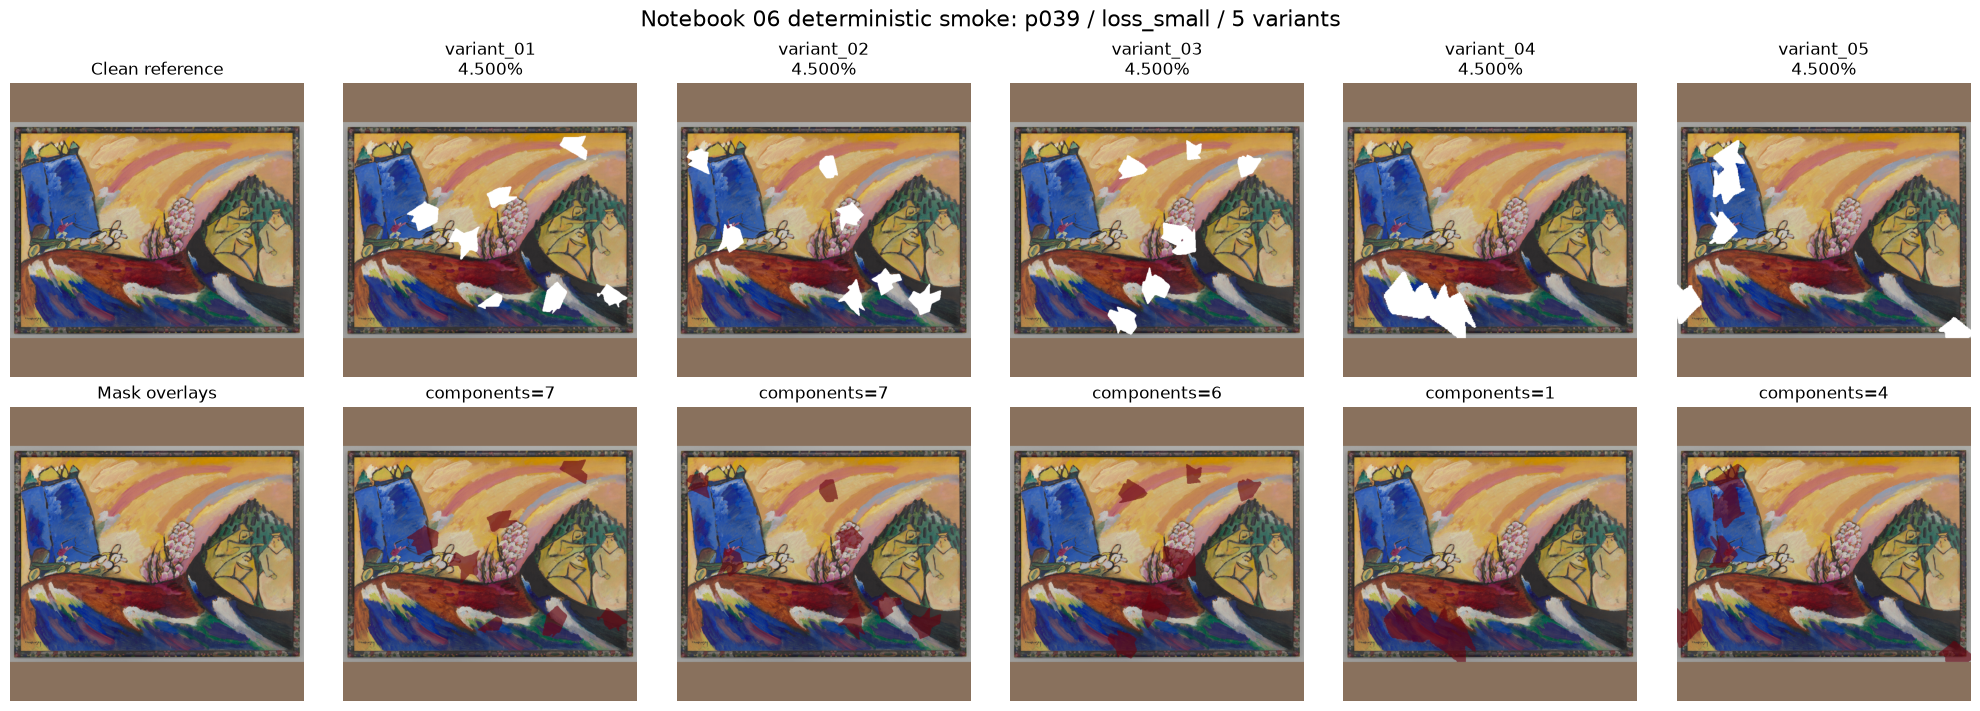

Replay mask-array failures: 0
Replay damaged-array failures: 0
Configured-group maximum off-diagonal IoU: 0.095148
No robustness artifact has been written.


In [9]:
# ---------------------------------------------------------------------------
# Deterministic replay comparison across all 15 generated cases
# ---------------------------------------------------------------------------

DETERMINISTIC_METADATA_COLUMNS = [
    "case_id",
    "robustness_group_id",
    "variant_id",
    "variant_index",
    "painting_id",
    "mask_type",
    "family_index",
    "target_token",
    "target_damage_fraction",
    "target_damage_pixels",
    "realized_damage_fraction",
    "realized_damage_pixels",
    "absolute_percentage_point_error",
    "raw_mask_pixels",
    "scale_factor",
    "pre_correction_pixels",
    "correction_added_pixels",
    "correction_removed_pixels",
    "centroid_x_pixels",
    "centroid_y_pixels",
    "centroid_x_normalized_content",
    "centroid_y_normalized_content",
    "centroid_quadrant",
    "bbox_x_min",
    "bbox_y_min",
    "bbox_x_max",
    "bbox_y_max",
    "bbox_width",
    "bbox_height",
    "bbox_fill_ratio",
    "bbox_aspect_ratio",
    "connected_component_count",
    "largest_component_fraction",
    "component_area_cv",
    "mask_perimeter_pixels",
    "mask_compactness",
    "touches_content_boundary",
    "minimum_distance_to_content_boundary_pixels",
    "painting_seed",
    "group_seed",
    "variant_seed",
    "generation_seed",
    "generation_attempt",
    "mask_pixel_sha256",
]

first_replay_df = (
    smoke_result_first.cases[
        DETERMINISTIC_METADATA_COLUMNS
    ]
    .sort_values(
        [
            "mask_type",
            "variant_index",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

second_replay_df = (
    smoke_result_second.cases[
        DETERMINISTIC_METADATA_COLUMNS
    ]
    .sort_values(
        [
            "mask_type",
            "variant_index",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

replay_case_ids_match = (
    first_replay_df[
        "case_id"
    ]
    .equals(
        second_replay_df[
            "case_id"
        ]
    )
)

replay_seed_columns = [
    "painting_seed",
    "group_seed",
    "variant_seed",
    "generation_seed",
    "generation_attempt",
]

replay_seeds_match = (
    first_replay_df[
        replay_seed_columns
    ]
    .equals(
        second_replay_df[
            replay_seed_columns
        ]
    )
)

replay_metadata_matches = (
    first_replay_df.equals(
        second_replay_df
    )
)

replay_hashes_match = (
    first_replay_df[
        "mask_pixel_sha256"
    ]
    .equals(
        second_replay_df[
            "mask_pixel_sha256"
        ]
    )
)

all_smoke_case_ids = tuple(
    smoke_result_first.cases[
        "case_id"
    ].astype(str)
)

mask_array_replay_failures = []
damaged_array_replay_failures = []

for case_id in all_smoke_case_ids:
    first_mask_array = np.asarray(
        smoke_result_first
        .preview_masks[
            case_id
        ],
        dtype=np.uint8,
    )

    second_mask_array = np.asarray(
        smoke_result_second
        .preview_masks[
            case_id
        ],
        dtype=np.uint8,
    )

    if not np.array_equal(
        first_mask_array,
        second_mask_array,
    ):
        mask_array_replay_failures.append(
            case_id
        )

    first_damaged_array = np.asarray(
        smoke_result_first
        .preview_damaged[
            case_id
        ],
        dtype=np.uint8,
    )

    second_damaged_array = np.asarray(
        smoke_result_second
        .preview_damaged[
            case_id
        ],
        dtype=np.uint8,
    )

    if not np.array_equal(
        first_damaged_array,
        second_damaged_array,
    ):
        damaged_array_replay_failures.append(
            case_id
        )


# ---------------------------------------------------------------------------
# Independent configured-group pixel audit
# ---------------------------------------------------------------------------

smoke_clean_path = resolve_repo_path(
    smoke_cohort_df[
        "processed_path"
    ].iloc[0],
    PROJECT_ROOT,
    must_exist=True,
)

with Image.open(
    smoke_clean_path
) as opened_clean:
    smoke_clean_image = (
        opened_clean.convert("RGB")
    )

    smoke_clean_image.load()

smoke_clean_array = np.asarray(
    smoke_clean_image,
    dtype=np.uint8,
)

fill_color_array = np.asarray(
    robustness_config[
        "generator"
    ][
        "fill_color_rgb"
    ],
    dtype=np.uint8,
)

smoke_pixel_audit_rows = []

for row in (
    smoke_cases_first_df
    .itertuples(
        index=False
    )
):
    mask_image = (
        smoke_result_first
        .preview_masks[
            row.case_id
        ]
    )

    damaged_image = (
        smoke_result_first
        .preview_damaged[
            row.case_id
        ]
    )

    mask_array_uint8 = np.asarray(
        mask_image,
        dtype=np.uint8,
    )

    binary_mask = (
        mask_array_uint8
        == 255
    )

    damaged_array = np.asarray(
        damaged_image,
        dtype=np.uint8,
    )

    unique_values = sorted(
        np.unique(
            mask_array_uint8
        )
        .astype(int)
        .tolist()
    )

    content_mask = np.zeros_like(
        binary_mask,
        dtype=bool,
    )

    content_mask[
        int(
            row.content_y_min
        ):
        int(
            row.content_y_max
        ),
        int(
            row.content_x_min
        ):
        int(
            row.content_x_max
        ),
    ] = True

    changed_pixels = np.any(
        smoke_clean_array
        != damaged_array,
        axis=2,
    )

    outside_mask_changed_pixels = int(
        (
            changed_pixels
            & ~binary_mask
        ).sum()
    )

    inside_mask_not_fill_pixels = int(
        (
            np.any(
                damaged_array
                != fill_color_array,
                axis=2,
            )
            & binary_mask
        ).sum()
    )

    realized_pixels = int(
        binary_mask.sum()
    )

    realized_fraction = (
        realized_pixels
        / int(
            row.content_area_pixels
        )
    )

    smoke_pixel_audit_rows.append(
        {
            "case_id": str(
                row.case_id
            ),
            "variant_id": str(
                row.variant_id
            ),
            "mask_mode": str(
                mask_image.mode
            ),
            "damaged_mode": str(
                damaged_image.mode
            ),
            "mask_width": int(
                mask_image.width
            ),
            "mask_height": int(
                mask_image.height
            ),
            "damaged_width": int(
                damaged_image.width
            ),
            "damaged_height": int(
                damaged_image.height
            ),
            "mask_unique_values": "|".join(
                str(value)
                for value
                in unique_values
            ),
            "binary_values_valid": (
                set(
                    unique_values
                ).issubset(
                    {
                        0,
                        255,
                    }
                )
            ),
            "padding_overlap_pixels": int(
                (
                    binary_mask
                    & ~content_mask
                ).sum()
            ),
            "content_only_valid": (
                not (
                    binary_mask
                    & ~content_mask
                ).any()
            ),
            "target_pixels": int(
                row.target_damage_pixels
            ),
            "realized_pixels": (
                realized_pixels
            ),
            "exact_target_pixels": (
                realized_pixels
                == int(
                    row.target_damage_pixels
                )
            ),
            "metadata_pixels_match": (
                realized_pixels
                == int(
                    row.realized_damage_pixels
                )
            ),
            "realized_fraction": (
                realized_fraction
            ),
            "metadata_realized_fraction": float(
                row.realized_damage_fraction
            ),
            "absolute_percentage_point_error": abs(
                (
                    100.0
                    * realized_fraction
                )
                - (
                    100.0
                    * float(
                        row.target_damage_fraction
                    )
                )
            ),
            "outside_mask_changed_pixels": (
                outside_mask_changed_pixels
            ),
            "inside_mask_not_fill_pixels": (
                inside_mask_not_fill_pixels
            ),
            "mask_pixel_sha256": str(
                row.mask_pixel_sha256
            ),
        }
    )

smoke_pixel_audit_df = pd.DataFrame(
    smoke_pixel_audit_rows
)


# ---------------------------------------------------------------------------
# Pairwise IoU matrix for the configured group
# ---------------------------------------------------------------------------

smoke_case_ids = tuple(
    smoke_cases_first_df[
        "case_id"
    ].astype(str)
)

smoke_variant_ids = tuple(
    smoke_cases_first_df[
        "variant_id"
    ].astype(str)
)

pairwise_iou_matrix = np.eye(
    len(
        smoke_case_ids
    ),
    dtype=float,
)

for left_index in range(
    len(
        smoke_case_ids
    )
):
    left_mask = (
        np.asarray(
            smoke_result_first
            .preview_masks[
                smoke_case_ids[
                    left_index
                ]
            ],
            dtype=np.uint8,
        )
        == 255
    )

    for right_index in range(
        left_index + 1,
        len(
            smoke_case_ids
        ),
    ):
        right_mask = (
            np.asarray(
                smoke_result_first
                .preview_masks[
                    smoke_case_ids[
                        right_index
                    ]
                ],
                dtype=np.uint8,
            )
            == 255
        )

        intersection_pixels = int(
            (
                left_mask
                & right_mask
            ).sum()
        )

        union_pixels = int(
            (
                left_mask
                | right_mask
            ).sum()
        )

        pairwise_iou = (
            intersection_pixels
            / union_pixels
        )

        pairwise_iou_matrix[
            left_index,
            right_index,
        ] = pairwise_iou

        pairwise_iou_matrix[
            right_index,
            left_index,
        ] = pairwise_iou

pairwise_iou_df = pd.DataFrame(
    pairwise_iou_matrix,
    index=smoke_variant_ids,
    columns=smoke_variant_ids,
)


# ---------------------------------------------------------------------------
# Notebook-only visual evidence
# ---------------------------------------------------------------------------

smoke_figure, smoke_axes = plt.subplots(
    nrows=2,
    ncols=6,
    figsize=(
        20,
        7,
    ),
    constrained_layout=True,
)

smoke_axes[
    0,
    0,
].imshow(
    smoke_clean_image
)

smoke_axes[
    0,
    0,
].set_title(
    "Clean reference"
)

smoke_axes[
    1,
    0,
].imshow(
    smoke_clean_image
)

smoke_axes[
    1,
    0,
].set_title(
    "Mask overlays"
)

for column_index, row in enumerate(
    smoke_cases_first_df.itertuples(
        index=False
    ),
    start=1,
):
    mask_image = (
        smoke_result_first
        .preview_masks[
            row.case_id
        ]
    )

    damaged_image = (
        smoke_result_first
        .preview_damaged[
            row.case_id
        ]
    )

    mask_array = (
        np.asarray(
            mask_image,
            dtype=np.uint8,
        )
        == 255
    )

    smoke_axes[
        0,
        column_index,
    ].imshow(
        damaged_image
    )

    smoke_axes[
        0,
        column_index,
    ].set_title(
        (
            f"{row.variant_id}\n"
            f"{100.0 * float(row.realized_damage_fraction):.3f}%"
        )
    )

    smoke_axes[
        1,
        column_index,
    ].imshow(
        smoke_clean_image
    )

    smoke_axes[
        1,
        column_index,
    ].imshow(
        np.ma.masked_where(
            ~mask_array,
            mask_array,
        ),
        cmap="Reds",
        alpha=0.62,
        vmin=0,
        vmax=1,
    )

    smoke_axes[
        1,
        column_index,
    ].set_title(
        (
            f"components="
            f"{int(row.connected_component_count)}"
        )
    )

for axis in smoke_axes.flat:
    axis.axis("off")

smoke_figure.suptitle(
    (
        "Notebook 06 deterministic smoke: "
        f"{SMOKE_PAINTING_ID} / "
        f"{SMOKE_MASK_TYPE} / "
        f"{SMOKE_VARIANT_COUNT} variants"
    ),
    fontsize=16,
)

plt.show()

print(
    "Replay mask-array failures:",
    len(
        mask_array_replay_failures
    ),
)

print(
    "Replay damaged-array failures:",
    len(
        damaged_array_replay_failures
    ),
)

print(
    "Configured-group maximum off-diagonal IoU:",
    round(
        float(
            pairwise_iou_matrix[
                ~np.eye(
                    len(
                        smoke_case_ids
                    ),
                    dtype=bool,
                )
            ].max()
        ),
        6,
    ),
)

print(
    "No robustness artifact "
    "has been written."
)

In [10]:
# ---------------------------------------------------------------------------
# Batch 3 validation collector
# ---------------------------------------------------------------------------

BATCH_3_STAGE = (
    "batch_3_deterministic_smoke"
)

BATCH_3_START_CHECK_COUNT = len(
    VALIDATION.checks
)


def add_batch_3_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=BATCH_3_STAGE,
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Configured representative selection
# ---------------------------------------------------------------------------

median_content_painting_id = str(
    robustness_cohort_df.loc[
        (
            robustness_cohort_df[
                "content_area_pixels"
            ]
            - robustness_cohort_df[
                "content_area_pixels"
            ].median()
        )
        .abs()
        .sort_values(
            kind="stable"
        )
        .index[0],
        "painting_id",
    ]
)

add_batch_3_check(
    check_id="smoke_selection",
    description=(
        "Configured smoke uses the median-"
        "content painting and moderate "
        "loss_small family."
    ),
    expected={
        "painting_id": (
            median_content_painting_id
        ),
        "mask_type": "loss_small",
        "persist_outputs": False,
    },
    observed={
        "painting_id": (
            SMOKE_PAINTING_ID
        ),
        "mask_type": (
            SMOKE_MASK_TYPE
        ),
        "persist_outputs": (
            SMOKE_PERSIST_OUTPUTS
        ),
    },
    passed=(
        SMOKE_PAINTING_ID
        == median_content_painting_id
        and SMOKE_MASK_TYPE
        == "loss_small"
        and not SMOKE_PERSIST_OUTPUTS
    ),
)


# ---------------------------------------------------------------------------
# 2. Complete one-painting generator coverage
# ---------------------------------------------------------------------------

add_batch_3_check(
    check_id="full_smoke_cardinality",
    description=(
        "Each repetition generates all three "
        "families and 15 cases for p039."
    ),
    expected={
        "repetitions": 2,
        "cases_per_repetition": 15,
        "groups_per_repetition": 3,
    },
    observed={
        "repetitions": (
            SMOKE_REPEAT_COUNT
        ),
        "first_cases": len(
            smoke_result_first.cases
        ),
        "second_cases": len(
            smoke_result_second.cases
        ),
        "first_groups": int(
            smoke_result_first.cases[
                "robustness_group_id"
            ].nunique()
        ),
        "second_groups": int(
            smoke_result_second.cases[
                "robustness_group_id"
            ].nunique()
        ),
    },
    passed=(
        SMOKE_REPEAT_COUNT
        == 2
        and len(
            smoke_result_first.cases
        )
        == 15
        and len(
            smoke_result_second.cases
        )
        == 15
        and smoke_result_first.cases[
            "robustness_group_id"
        ].nunique()
        == 3
        and smoke_result_second.cases[
            "robustness_group_id"
        ].nunique()
        == 3
    ),
)


# ---------------------------------------------------------------------------
# 3. Configured five-variant group
# ---------------------------------------------------------------------------

add_batch_3_check(
    check_id="configured_smoke_group",
    description=(
        "Configured loss_small smoke selection "
        "contains one group and five variants."
    ),
    expected={
        "groups": 1,
        "variants": 5,
        "variant_ids": [
            f"variant_{index:02d}"
            for index in range(
                1,
                6,
            )
        ],
    },
    observed={
        "groups": int(
            smoke_cases_first_df[
                "robustness_group_id"
            ].nunique()
        ),
        "variants": len(
            smoke_cases_first_df
        ),
        "variant_ids": (
            smoke_cases_first_df[
                "variant_id"
            ].astype(str).tolist()
        ),
    },
    passed=(
        len(
            smoke_cases_first_df
        )
        == SMOKE_VARIANT_COUNT
        == 5
        and smoke_cases_first_df[
            "robustness_group_id"
        ].nunique()
        == 1
    ),
)


# ---------------------------------------------------------------------------
# 4-9. Deterministic replay
# ---------------------------------------------------------------------------

add_batch_3_check(
    check_id="replay_case_identities",
    description=(
        "Case and group identities are stable "
        "across both repetitions."
    ),
    expected=True,
    observed=replay_case_ids_match,
    passed=replay_case_ids_match,
)

add_batch_3_check(
    check_id="replay_seeds",
    description=(
        "Painting, group, variant, generation "
        "seeds, and selected attempts replay."
    ),
    expected=True,
    observed=replay_seeds_match,
    passed=replay_seeds_match,
)

add_batch_3_check(
    check_id="replay_metadata",
    description=(
        "All deterministic generation metadata "
        "is identical across repetitions."
    ),
    expected=True,
    observed=replay_metadata_matches,
    passed=replay_metadata_matches,
)

add_batch_3_check(
    check_id="replay_pixel_hashes",
    description=(
        "All mask pixel SHA-256 values replay "
        "identically."
    ),
    expected=True,
    observed=replay_hashes_match,
    passed=replay_hashes_match,
)

add_batch_3_check(
    check_id="replay_mask_arrays",
    description=(
        "All 15 in-memory mask arrays are "
        "byte-identical across repetitions."
    ),
    expected={
        "failures": 0,
    },
    observed={
        "failures": len(
            mask_array_replay_failures
        ),
    },
    passed=not mask_array_replay_failures,
    details=mask_array_replay_failures,
)

add_batch_3_check(
    check_id="replay_damaged_arrays",
    description=(
        "All 15 in-memory damaged RGB arrays "
        "are byte-identical across repetitions."
    ),
    expected={
        "failures": 0,
    },
    observed={
        "failures": len(
            damaged_array_replay_failures
        ),
    },
    passed=not damaged_array_replay_failures,
    details=damaged_array_replay_failures,
)


# ---------------------------------------------------------------------------
# 10. Exact rounded target pixel counts
# ---------------------------------------------------------------------------

add_batch_3_check(
    check_id="exact_target_pixels",
    description=(
        "Every configured smoke mask reaches "
        "its exact rounded target pixel count."
    ),
    expected={
        "failures": 0,
    },
    observed={
        "failures": int(
            (
                ~smoke_pixel_audit_df[
                    "exact_target_pixels"
                ]
            ).sum()
        ),
    },
    passed=smoke_pixel_audit_df[
        "exact_target_pixels"
    ].all(),
)


# ---------------------------------------------------------------------------
# 11. Area-error tolerance
# ---------------------------------------------------------------------------

maximum_smoke_area_error = float(
    smoke_pixel_audit_df[
        "absolute_percentage_point_error"
    ].max()
)

maximum_allowed_area_error = float(
    robustness_config[
        "generator"
    ][
        "maximum_absolute_percentage_point_error"
    ]
)

add_batch_3_check(
    check_id="area_tolerance",
    description=(
        "All configured smoke variants satisfy "
        "the approved percentage-point error."
    ),
    expected={
        "maximum_error_pp": (
            maximum_allowed_area_error
        ),
    },
    observed={
        "maximum_error_pp": (
            maximum_smoke_area_error
        ),
    },
    passed=(
        maximum_smoke_area_error
        <= maximum_allowed_area_error
    ),
)


# ---------------------------------------------------------------------------
# 12. Binary mask values
# ---------------------------------------------------------------------------

add_batch_3_check(
    check_id="binary_mask_values",
    description=(
        "Every smoke mask contains only "
        "binary values 0 and 255."
    ),
    expected={
        "failures": 0,
    },
    observed={
        "failures": int(
            (
                ~smoke_pixel_audit_df[
                    "binary_values_valid"
                ]
            ).sum()
        ),
        "observed_values": sorted(
            smoke_pixel_audit_df[
                "mask_unique_values"
            ].unique().tolist()
        ),
    },
    passed=smoke_pixel_audit_df[
        "binary_values_valid"
    ].all(),
)


# ---------------------------------------------------------------------------
# 13. Content-region containment
# ---------------------------------------------------------------------------

add_batch_3_check(
    check_id="content_region_containment",
    description=(
        "Every smoke mask remains entirely "
        "inside the Notebook 02 content region."
    ),
    expected={
        "padding_overlap_pixels": 0,
    },
    observed={
        "padding_overlap_pixels": int(
            smoke_pixel_audit_df[
                "padding_overlap_pixels"
            ].sum()
        ),
    },
    passed=smoke_pixel_audit_df[
        "content_only_valid"
    ].all(),
)


# ---------------------------------------------------------------------------
# 14. Image dimensions, modes, and rendered figure
# ---------------------------------------------------------------------------

image_figure_contract_passed = (
    smoke_pixel_audit_df[
        "mask_width"
    ].eq(768).all()
    and smoke_pixel_audit_df[
        "mask_height"
    ].eq(768).all()
    and smoke_pixel_audit_df[
        "damaged_width"
    ].eq(768).all()
    and smoke_pixel_audit_df[
        "damaged_height"
    ].eq(768).all()
    and smoke_pixel_audit_df[
        "mask_mode"
    ].eq("L").all()
    and smoke_pixel_audit_df[
        "damaged_mode"
    ].eq("RGB").all()
    and smoke_axes.shape
    == (
        2,
        6,
    )
)

add_batch_3_check(
    check_id="image_and_figure_contract",
    description=(
        "Smoke masks, damaged images, and "
        "the notebook-only comparison figure "
        "have the approved structure."
    ),
    expected={
        "dimensions": "768x768",
        "mask_mode": "L",
        "damaged_mode": "RGB",
        "figure_axes": [
            2,
            6,
        ],
    },
    observed={
        "mask_dimensions": sorted(
            set(
                zip(
                    smoke_pixel_audit_df[
                        "mask_width"
                    ],
                    smoke_pixel_audit_df[
                        "mask_height"
                    ],
                )
            )
        ),
        "damaged_dimensions": sorted(
            set(
                zip(
                    smoke_pixel_audit_df[
                        "damaged_width"
                    ],
                    smoke_pixel_audit_df[
                        "damaged_height"
                    ],
                )
            )
        ),
        "mask_modes": sorted(
            smoke_pixel_audit_df[
                "mask_mode"
            ].unique().tolist()
        ),
        "damaged_modes": sorted(
            smoke_pixel_audit_df[
                "damaged_mode"
            ].unique().tolist()
        ),
        "figure_axes": list(
            smoke_axes.shape
        ),
    },
    passed=image_figure_contract_passed,
)


# ---------------------------------------------------------------------------
# 15. Damage pixel integrity
# ---------------------------------------------------------------------------

add_batch_3_check(
    check_id="damage_pixel_integrity",
    description=(
        "Damage changes no outside-mask pixel "
        "and every masked pixel receives the "
        "configured fill colour."
    ),
    expected={
        "outside_mask_changes": 0,
        "inside_mask_fill_failures": 0,
    },
    observed={
        "outside_mask_changes": int(
            smoke_pixel_audit_df[
                "outside_mask_changed_pixels"
            ].sum()
        ),
        "inside_mask_fill_failures": int(
            smoke_pixel_audit_df[
                "inside_mask_not_fill_pixels"
            ].sum()
        ),
    },
    passed=(
        smoke_pixel_audit_df[
            "outside_mask_changed_pixels"
        ].eq(0).all()
        and smoke_pixel_audit_df[
            "inside_mask_not_fill_pixels"
        ].eq(0).all()
    ),
)


# ---------------------------------------------------------------------------
# 16. Five unique masks per group
# ---------------------------------------------------------------------------

all_group_summary_df = (
    all_smoke_group_evidence_df
    .groupby(
        "robustness_group_id",
        sort=False,
    )
    .first()
    .reset_index()
)

add_batch_3_check(
    check_id="group_mask_uniqueness",
    description=(
        "Every generated family group contains "
        "five unique mask pixel checksums."
    ),
    expected={
        "groups": 3,
        "variants_per_group": 5,
        "failed_groups": 0,
    },
    observed={
        "groups": len(
            all_group_summary_df
        ),
        "variant_counts": (
            all_group_summary_df[
                "group_variant_count"
            ].astype(int).tolist()
        ),
        "unique_counts": (
            all_group_summary_df[
                "group_unique_pixel_sha256_count"
            ].astype(int).tolist()
        ),
        "failed_groups": int(
            (
                ~all_group_summary_df[
                    "group_unique_mask_count_passed"
                ]
            ).sum()
        ),
    },
    passed=(
        len(
            all_group_summary_df
        )
        == 3
        and all_group_summary_df[
            "group_variant_count"
        ].eq(5).all()
        and all_group_summary_df[
            "group_unique_mask_count_passed"
        ].all()
    ),
)


# ---------------------------------------------------------------------------
# 17. Pairwise IoU distinctness
# ---------------------------------------------------------------------------

maximum_allowed_iou = float(
    robustness_config[
        "distinctness"
    ][
        "maximum_pairwise_iou_exclusive"
    ]
)

add_batch_3_check(
    check_id="pairwise_iou_distinctness",
    description=(
        "Every group remains below the "
        "configured exclusive maximum "
        "pairwise IoU."
    ),
    expected={
        "maximum_iou_exclusive": (
            maximum_allowed_iou
        ),
        "failed_groups": 0,
    },
    observed={
        "maximum_observed_iou": float(
            all_group_summary_df[
                "maximum_pairwise_iou"
            ].max()
        ),
        "failed_groups": int(
            (
                ~all_group_summary_df[
                    "pairwise_iou_passed"
                ]
            ).sum()
        ),
    },
    passed=all_group_summary_df[
        "pairwise_iou_passed"
    ].all(),
)


# ---------------------------------------------------------------------------
# 18. Location variation
# ---------------------------------------------------------------------------

minimum_centroid_span = float(
    robustness_config[
        "distinctness"
    ][
        "minimum_centroid_span_fraction_of_content_diagonal"
    ]
)

add_batch_3_check(
    check_id="location_variation",
    description=(
        "Every group has the required "
        "normalized centroid spread."
    ),
    expected={
        "minimum_centroid_span": (
            minimum_centroid_span
        ),
        "failed_groups": 0,
    },
    observed={
        "minimum_observed_span": float(
            all_group_summary_df[
                "group_centroid_span_fraction_of_content_diagonal"
            ].min()
        ),
        "failed_groups": int(
            (
                ~all_group_summary_df[
                    "location_variation_passed"
                ]
            ).sum()
        ),
    },
    passed=all_group_summary_df[
        "location_variation_passed"
    ].all(),
)


# ---------------------------------------------------------------------------
# 19. Morphology and component-arrangement variation
# ---------------------------------------------------------------------------

add_batch_3_check(
    check_id="morphology_component_variation",
    description=(
        "Every group contains the required "
        "number of morphology and component-"
        "arrangement signatures."
    ),
    expected={
        "minimum_morphology_signatures": int(
            robustness_config[
                "distinctness"
            ][
                "minimum_morphology_signature_count"
            ]
        ),
        "minimum_component_signatures": int(
            robustness_config[
                "distinctness"
            ][
                "minimum_component_arrangement_signature_count"
            ]
        ),
        "failed_groups": 0,
    },
    observed={
        "minimum_morphology_signatures": int(
            all_group_summary_df[
                "group_morphology_signature_count"
            ].min()
        ),
        "minimum_component_signatures": int(
            all_group_summary_df[
                "group_component_arrangement_signature_count"
            ].min()
        ),
        "failed_groups": int(
            (
                ~all_group_summary_df[
                    "morphology_variation_passed"
                ]
                | ~all_group_summary_df[
                    "component_arrangement_variation_passed"
                ]
            ).sum()
        ),
    },
    passed=(
        all_group_summary_df[
            "morphology_variation_passed"
        ].all()
        and all_group_summary_df[
            "component_arrangement_variation_passed"
        ].all()
    ),
)


# ---------------------------------------------------------------------------
# 20. Broad canonical family morphology
# ---------------------------------------------------------------------------

add_batch_3_check(
    check_id="broad_family_morphology",
    description=(
        "Every generated group retains the "
        "approved broad canonical family "
        "morphology."
    ),
    expected={
        "families": 3,
        "failed_groups": 0,
    },
    observed={
        "families": len(
            all_group_summary_df
        ),
        "failed_groups": int(
            (
                ~all_group_summary_df[
                    "family_morphology_passed"
                ]
            ).sum()
        ),
    },
    passed=all_group_summary_df[
        "family_morphology_passed"
    ].all(),
)


# ---------------------------------------------------------------------------
# 21. Strictly non-persisting execution
# ---------------------------------------------------------------------------

SMOKE_OUTPUT_FILES_AFTER = {
    path.resolve()
    for path
    in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

new_smoke_output_files = sorted(
    SMOKE_OUTPUT_FILES_AFTER
    - SMOKE_OUTPUT_FILES_BEFORE
)

add_batch_3_check(
    check_id="non_persisting_smoke",
    description=(
        "Smoke generation and rendering create "
        "no Notebook 06 output file."
    ),
    expected={
        "new_output_files": 0,
        "total_output_files": 0,
    },
    observed={
        "new_output_files": len(
            new_smoke_output_files
        ),
        "total_output_files": len(
            SMOKE_OUTPUT_FILES_AFTER
        ),
    },
    passed=(
        not new_smoke_output_files
        and not SMOKE_OUTPUT_FILES_AFTER
    ),
    details=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path
        in new_smoke_output_files
    ],
)


# ---------------------------------------------------------------------------
# Batch 3 completion gate and rendered evidence
# ---------------------------------------------------------------------------

BATCH_3_CHECK_COUNT = (
    len(
        VALIDATION.checks
    )
    - BATCH_3_START_CHECK_COUNT
)

if BATCH_3_CHECK_COUNT != 21:
    raise RuntimeError(
        "Batch 3 must add exactly "
        f"21 checks; observed "
        f"{BATCH_3_CHECK_COUNT}."
    )

VALIDATION.raise_for_blocking()

batch_3_checks_df = (
    VALIDATION.to_dataframe()
    .iloc[
        BATCH_3_START_CHECK_COUNT:
    ]
    .reset_index(
        drop=True
    )
)

print(
    "Batch 3 validation checks:"
)

display(
    batch_3_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nConfigured loss-small smoke cases:"
)

display(
    smoke_cases_first_df[
        [
            "variant_id",
            "target_damage_fraction",
            "target_damage_pixels",
            "realized_damage_fraction",
            "realized_damage_pixels",
            "absolute_percentage_point_error",
            "centroid_x_normalized_content",
            "centroid_y_normalized_content",
            "centroid_quadrant",
            "connected_component_count",
            "bbox_aspect_ratio",
            "mask_compactness",
            "generation_attempt",
        ]
    ]
)

print(
    "\nIndependent smoke pixel audit:"
)

display(
    smoke_pixel_audit_df
)

print(
    "\nConfigured-group pairwise IoU matrix:"
)

display(
    pairwise_iou_df.round(6)
)

print(
    "\nAll p039 robustness-group summaries:"
)

display(
    all_group_summary_df[
        [
            "robustness_group_id",
            "group_variant_count",
            "group_unique_pixel_sha256_count",
            "maximum_pairwise_iou",
            "group_centroid_span_fraction_of_content_diagonal",
            "group_morphology_signature_count",
            "group_component_arrangement_signature_count",
            "family_morphology_passed",
            "group_gate_passed",
        ]
    ]
)

print(
    "\nBatch 3 completed successfully."
)

print(
    "Batch 3 checks:",
    BATCH_3_CHECK_COUNT,
)

print(
    "Total accumulated checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Blocking failures:",
    len(
        VALIDATION.blocking_failures
    ),
)

print(
    "Persisted Notebook 06 files:",
    len(
        SMOKE_OUTPUT_FILES_AFTER
    ),
)

print(
    "Next approved stage: Batch 4 - "
    "full 75-case generation and "
    "image persistence."
)

Batch 3 validation checks:


,check_id,severity,expected,observed,passed
0,smoke_selection,blocking,"{""mask_type"": ""loss_small"", ""painting_id"": ""p0...","{""mask_type"": ""loss_small"", ""painting_id"": ""p0...",True
1,full_smoke_cardinality,blocking,"{""cases_per_repetition"": 15, ""groups_per_repet...","{""first_cases"": 15, ""first_groups"": 3, ""repeti...",True
2,configured_smoke_group,blocking,"{""groups"": 1, ""variant_ids"": [""variant_01"", ""v...","{""groups"": 1, ""variant_ids"": [""variant_01"", ""v...",True
3,replay_case_identities,blocking,True,True,True
4,replay_seeds,blocking,True,True,True
5,replay_metadata,blocking,True,True,True
6,replay_pixel_hashes,blocking,True,True,True
7,replay_mask_arrays,blocking,"{""failures"": 0}","{""failures"": 0}",True
8,replay_damaged_arrays,blocking,"{""failures"": 0}","{""failures"": 0}",True
9,exact_target_pixels,blocking,"{""failures"": 0}","{""failures"": 0}",True



Configured loss-small smoke cases:


,variant_id,target_damage_fraction,target_damage_pixels,realized_damage_fraction,realized_damage_pixels,absolute_percentage_point_error,centroid_x_normalized_content,centroid_y_normalized_content,centroid_quadrant,connected_component_count,bbox_aspect_ratio,mask_compactness,generation_attempt
0,variant_01,0.045,19492,0.045,19492,0.000037,0.570019,0.533895,bottom_right,7,1.238710,0.053888,1
1,variant_02,0.045,19492,0.045,19492,0.000037,0.514581,0.557083,bottom_right,7,1.521739,0.049970,1
2,variant_03,0.045,19492,0.045,19492,0.000037,0.533793,0.531674,bottom_right,6,1.263682,0.066169,1
3,variant_04,0.045,19492,0.045,19492,0.000037,0.292130,0.850172,bottom_left,1,1.393064,0.229989,1
4,variant_05,0.045,19492,0.045,19492,0.000037,0.258480,0.531566,bottom_left,4,1.485493,0.084358,1



Independent smoke pixel audit:


...


Configured-group pairwise IoU matrix:


,variant_01,variant_02,variant_03,variant_04,variant_05
variant_01,1.000000,0.025193,0.009033,0.000000,0.000000
variant_02,0.025193,1.000000,0.003604,0.000000,0.033072
variant_03,0.009033,0.003604,1.000000,0.095148,0.000000
variant_04,0.000000,0.000000,0.095148,1.000000,0.000000
variant_05,0.000000,0.033072,0.000000,0.000000,1.000000



All p039 robustness-group summaries:


,robustness_group_id,group_variant_count,group_unique_pixel_sha256_count,maximum_pairwise_iou,group_centroid_span_fraction_of_content_diagonal,group_morphology_signature_count,group_component_arrangement_signature_count,family_morphology_passed,group_gate_passed
0,robustness__p039__loss_large__target_12p5pct,5,5,0.499709,0.202111,5,5,True,True
1,robustness__p039__loss_small__target_04p5pct,5,5,0.095148,0.291477,5,5,True,True
2,robustness__p039__scratch_thin__target_02pct,5,5,0.018218,0.101552,5,5,True,True



Batch 3 completed successfully.
Batch 3 checks: 21
Total accumulated checks: 51
Blocking failures: 0
Persisted Notebook 06 files: 0
Next approved stage: Batch 4 - full 75-case generation and image persistence.


## Batch 4 - Full 75-Case Generation and Image Persistence

This batch performs the complete controlled robustness generation.

It will:

- generate all 15 robustness groups;
- generate five variants per group;
- produce 75 normalized cases;
- write 75 binary mask PNGs;
- write 75 corresponding damaged RGB PNGs;
- overwrite expected case images deterministically on rerun;
- remove stale PNGs from the two notebook-owned image collections;
- preserve exact rounded target pixel counts;
- verify case, mask, damaged-image, group, and variant identifier uniqueness;
- verify balanced painting, category, family, and variant coverage;
- verify deterministic agreement with the Batch 3 `p039` smoke generation;
- verify group uniqueness, pairwise IoU, location variation, morphology variation, component-arrangement variation, and broad family morphology;
- verify owned output paths and expected group-directory structure;
- add exactly 20 consolidated blocking validation checks.

This batch writes only the two canonical image collections:

- `images/masks/<robustness_group_id>/<variant_id>.png`
- `images/damaged/<robustness_group_id>/<variant_id>.png`

The case table, generation audit, figure, validation table, artifact manifest, and run manifest are not persisted yet. They will be written only after independent saved-image validation.

In [11]:
# ---------------------------------------------------------------------------
# Capture the pre-generation output state
# ---------------------------------------------------------------------------

PRE_GENERATION_OUTPUT_FILES = {
    path.resolve()
    for path
    in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}


# ---------------------------------------------------------------------------
# Generate and persist the complete robustness dataset
# ---------------------------------------------------------------------------

full_generation_started = (
    perf_counter()
)

full_generation_result = (
    generate_mask_robustness_dataset(
        cohort=robustness_cohort_df,
        config=robustness_config,
        canonical_mask_config=(
            canonical_mask_config
        ),
        output_root=OUTPUT_ROOT,
        project_root=PROJECT_ROOT,
        persist=True,
        retain_images=False,
    )
)

full_generation_seconds = (
    perf_counter()
    - full_generation_started
)

robustness_cases_df = (
    full_generation_result.cases
    .copy()
)

generation_evidence_df = (
    full_generation_result
    .generation_evidence
    .copy()
)

removed_stale_paths = tuple(
    full_generation_result
    .removed_stale_paths
)


# ---------------------------------------------------------------------------
# Immediate schema evidence
# ---------------------------------------------------------------------------

robustness_cases_schema_result = (
    validate_dataframe(
        robustness_cases_df,
        MASK_ROBUSTNESS_CASES_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Stable group-level evidence
# ---------------------------------------------------------------------------

generation_group_summary_df = (
    generation_evidence_df
    .sort_values(
        [
            "robustness_group_id",
            "variant_id",
        ],
        kind="stable",
    )
    .groupby(
        "robustness_group_id",
        sort=False,
    )
    .first()
    .reset_index()
)

group_identity_df = (
    robustness_cases_df[
        [
            "robustness_group_id",
            "painting_id",
            "category",
            "mask_type",
            "family_index",
            "target_token",
            "target_damage_fraction",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "painting_id",
            "family_index",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------------------------
# Cross-family target and size relationship evidence
# ---------------------------------------------------------------------------

painting_family_area_df = (
    robustness_cases_df
    .groupby(
        [
            "painting_id",
            "mask_type",
        ],
        sort=False,
    )
    .agg(
        case_count=(
            "case_id",
            "size",
        ),
        target_fraction=(
            "target_damage_fraction",
            "first",
        ),
        minimum_realized_fraction=(
            "realized_damage_fraction",
            "min",
        ),
        median_realized_fraction=(
            "realized_damage_fraction",
            "median",
        ),
        maximum_realized_fraction=(
            "realized_damage_fraction",
            "max",
        ),
        maximum_area_error_pp=(
            "absolute_percentage_point_error",
            "max",
        ),
    )
    .reset_index()
)

painting_family_fraction_pivot = (
    painting_family_area_df
    .pivot(
        index="painting_id",
        columns="mask_type",
        values="median_realized_fraction",
    )
)

painting_family_fraction_pivot[
    "loss_large_to_loss_small_ratio"
] = (
    painting_family_fraction_pivot[
        "loss_large"
    ]
    / painting_family_fraction_pivot[
        "loss_small"
    ]
)


# ---------------------------------------------------------------------------
# Generation timing evidence
# ---------------------------------------------------------------------------

generation_timing_df = pd.DataFrame(
    [
        {
            "case_count": len(
                robustness_cases_df
            ),
            "group_count": int(
                robustness_cases_df[
                    "robustness_group_id"
                ].nunique()
            ),
            "generation_seconds": (
                full_generation_seconds
            ),
            "mean_seconds_per_case": (
                full_generation_seconds
                / len(
                    robustness_cases_df
                )
            ),
            "removed_stale_file_count": len(
                removed_stale_paths
            ),
        }
    ]
)

print(
    "Full generation completed."
)

print(
    "Cases:",
    len(
        robustness_cases_df
    ),
)

print(
    "Groups:",
    robustness_cases_df[
        "robustness_group_id"
    ].nunique(),
)

print(
    "Generation seconds:",
    round(
        full_generation_seconds,
        3,
    ),
)

print(
    "Removed stale PNGs:",
    len(
        removed_stale_paths
    ),
)

print(
    "Case table has not yet "
    "been persisted."
)

[mask-robustness] 10/75 cases (13.3%) | elapsed=34.6s | rate=0.29 cases/s | latest=robustness__p001__loss_small__target_04p5pct/variant_05
[mask-robustness] 20/75 cases (26.7%) | elapsed=54.5s | rate=0.37 cases/s | latest=robustness__p018__scratch_thin__target_02pct/variant_05
[mask-robustness] 30/75 cases (40.0%) | elapsed=67.7s | rate=0.44 cases/s | latest=robustness__p018__loss_large__target_12p5pct/variant_05
[mask-robustness] 40/75 cases (53.3%) | elapsed=82.2s | rate=0.49 cases/s | latest=robustness__p026__loss_small__target_04p5pct/variant_05
[mask-robustness] 50/75 cases (66.7%) | elapsed=95.0s | rate=0.53 cases/s | latest=robustness__p039__scratch_thin__target_02pct/variant_05
[mask-robustness] 60/75 cases (80.0%) | elapsed=109.3s | rate=0.55 cases/s | latest=robustness__p039__loss_large__target_12p5pct/variant_05
[mask-robustness] 70/75 cases (93.3%) | elapsed=124.9s | rate=0.56 cases/s | latest=robustness__p043__loss_small__target_04p5pct/variant_05
[mask-robustness] 75/75 c

In [12]:
# ---------------------------------------------------------------------------
# Immediate saved-file metadata audit
#
# This verifies paths, existence, sizes, and ownership without decoding the
# images. Independent PIL reload and pixel validation belong to Batch 5.
# ---------------------------------------------------------------------------

generated_file_audit_rows = []

for row in (
    robustness_cases_df
    .itertuples(
        index=False
    )
):
    mask_path = resolve_repo_path(
        row.mask_path,
        PROJECT_ROOT,
        must_exist=False,
    )

    damaged_path = resolve_repo_path(
        row.damaged_image_path,
        PROJECT_ROOT,
        must_exist=False,
    )

    expected_filename = (
        f"{row.variant_id}.png"
    )

    mask_file_exists = (
        mask_path.is_file()
    )

    damaged_file_exists = (
        damaged_path.is_file()
    )

    generated_file_audit_rows.append(
        {
            "case_id": str(
                row.case_id
            ),
            "robustness_group_id": str(
                row.robustness_group_id
            ),
            "variant_id": str(
                row.variant_id
            ),
            "painting_id": str(
                row.painting_id
            ),
            "mask_type": str(
                row.mask_type
            ),
            "mask_path": to_repo_relative(
                mask_path,
                PROJECT_ROOT,
            ),
            "damaged_path": to_repo_relative(
                damaged_path,
                PROJECT_ROOT,
            ),
            "mask_file_exists": (
                mask_file_exists
            ),
            "damaged_file_exists": (
                damaged_file_exists
            ),
            "mask_size_bytes": (
                int(
                    mask_path.stat().st_size
                )
                if mask_file_exists
                else -1
            ),
            "metadata_mask_size_bytes": int(
                row.mask_size_bytes
            ),
            "damaged_size_bytes": (
                int(
                    damaged_path.stat().st_size
                )
                if damaged_file_exists
                else -1
            ),
            "metadata_damaged_size_bytes": int(
                row.damaged_size_bytes
            ),
            "mask_size_matches": (
                mask_file_exists
                and int(
                    mask_path.stat().st_size
                )
                == int(
                    row.mask_size_bytes
                )
            ),
            "damaged_size_matches": (
                damaged_file_exists
                and int(
                    damaged_path.stat().st_size
                )
                == int(
                    row.damaged_size_bytes
                )
            ),
            "mask_group_directory_matches": (
                mask_path.parent.name
                == str(
                    row.robustness_group_id
                )
            ),
            "damaged_group_directory_matches": (
                damaged_path.parent.name
                == str(
                    row.robustness_group_id
                )
            ),
            "mask_filename_matches": (
                mask_path.name
                == expected_filename
            ),
            "damaged_filename_matches": (
                damaged_path.name
                == expected_filename
            ),
        }
    )

generated_file_audit_df = pd.DataFrame(
    generated_file_audit_rows
)


# ---------------------------------------------------------------------------
# Owned image collection reconciliation
# ---------------------------------------------------------------------------

saved_mask_paths = {
    path.resolve()
    for path
    in MASK_OUTPUT_DIRECTORY.rglob(
        "*.png"
    )
    if path.is_file()
}

saved_damaged_paths = {
    path.resolve()
    for path
    in DAMAGED_OUTPUT_DIRECTORY.rglob(
        "*.png"
    )
    if path.is_file()
}

expected_mask_paths = {
    resolve_repo_path(
        path,
        PROJECT_ROOT,
        must_exist=False,
    ).resolve()
    for path
    in robustness_cases_df[
        "mask_path"
    ].astype(str)
}

expected_damaged_paths = {
    resolve_repo_path(
        path,
        PROJECT_ROOT,
        must_exist=False,
    ).resolve()
    for path
    in robustness_cases_df[
        "damaged_image_path"
    ].astype(str)
}

missing_mask_paths = sorted(
    expected_mask_paths
    - saved_mask_paths
)

missing_damaged_paths = sorted(
    expected_damaged_paths
    - saved_damaged_paths
)

orphan_mask_paths = sorted(
    saved_mask_paths
    - expected_mask_paths
)

orphan_damaged_paths = sorted(
    saved_damaged_paths
    - expected_damaged_paths
)

all_owned_files_after_generation = {
    path.resolve()
    for path
    in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

expected_owned_image_files = (
    expected_mask_paths
    | expected_damaged_paths
)

unexpected_nonimage_output_files = sorted(
    all_owned_files_after_generation
    - expected_owned_image_files
)


# ---------------------------------------------------------------------------
# Expected group-directory reconciliation
# ---------------------------------------------------------------------------

expected_group_directory_names = set(
    robustness_cases_df[
        "robustness_group_id"
    ].astype(str)
)

observed_mask_group_directory_names = {
    path.name
    for path
    in MASK_OUTPUT_DIRECTORY.iterdir()
    if path.is_dir()
}

observed_damaged_group_directory_names = {
    path.name
    for path
    in DAMAGED_OUTPUT_DIRECTORY.iterdir()
    if path.is_dir()
}


# ---------------------------------------------------------------------------
# Full generation versus Batch 3 p039 replay
# ---------------------------------------------------------------------------

full_p039_replay_df = (
    robustness_cases_df.loc[
        robustness_cases_df[
            "painting_id"
        ]
        .astype(str)
        .eq(
            SMOKE_PAINTING_ID
        ),
        [
            "case_id",
            "painting_seed",
            "group_seed",
            "variant_seed",
            "generation_seed",
            "generation_attempt",
            "target_damage_pixels",
            "realized_damage_pixels",
            "mask_pixel_sha256",
        ]
    ]
    .sort_values(
        "case_id",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

smoke_p039_replay_df = (
    smoke_result_first.cases[
        [
            "case_id",
            "painting_seed",
            "group_seed",
            "variant_seed",
            "generation_seed",
            "generation_attempt",
            "target_damage_pixels",
            "realized_damage_pixels",
            "mask_pixel_sha256",
        ]
    ]
    .sort_values(
        "case_id",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

full_generation_matches_smoke = (
    full_p039_replay_df.equals(
        smoke_p039_replay_df
    )
)


# ---------------------------------------------------------------------------
# Distribution summaries
# ---------------------------------------------------------------------------

painting_case_counts = (
    robustness_cases_df
    .groupby(
        "painting_id"
    )
    .size()
    .to_dict()
)

category_case_counts = (
    robustness_cases_df
    .groupby(
        "category"
    )
    .size()
    .to_dict()
)

family_case_counts = (
    robustness_cases_df
    .groupby(
        "mask_type"
    )
    .size()
    .to_dict()
)

variant_case_counts = (
    robustness_cases_df
    .groupby(
        "variant_id"
    )
    .size()
    .to_dict()
)

group_case_counts = (
    robustness_cases_df
    .groupby(
        "robustness_group_id"
    )
    .size()
)

print(
    "Saved mask PNGs:",
    len(
        saved_mask_paths
    ),
)

print(
    "Saved damaged PNGs:",
    len(
        saved_damaged_paths
    ),
)

print(
    "Missing expected images:",
    (
        len(
            missing_mask_paths
        )
        + len(
            missing_damaged_paths
        )
    ),
)

print(
    "Orphan images:",
    (
        len(
            orphan_mask_paths
        )
        + len(
            orphan_damaged_paths
        )
    ),
)

print(
    "Unexpected non-image files:",
    len(
        unexpected_nonimage_output_files
    ),
)

print(
    "Full-generation p039 replay matches:",
    full_generation_matches_smoke,
)

Saved mask PNGs: 75
Saved damaged PNGs: 75
Missing expected images: 0
Orphan images: 0
Unexpected non-image files: 0
Full-generation p039 replay matches: True


In [13]:
# ---------------------------------------------------------------------------
# Batch 4 validation collector
# ---------------------------------------------------------------------------

BATCH_4_STAGE = (
    "batch_4_full_generation"
)

BATCH_4_START_CHECK_COUNT = len(
    VALIDATION.checks
)


def add_batch_4_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=BATCH_4_STAGE,
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Exact normalized case schema
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="generated_case_schema",
    description=(
        "In-memory full-generation cases "
        "satisfy the exact normalized schema."
    ),
    expected={
        "schema": (
            MASK_ROBUSTNESS_CASES_SCHEMA
            .version
        ),
        "passed": True,
        "unexpected_columns": 0,
    },
    observed={
        "schema": (
            robustness_cases_schema_result
            .schema_version
        ),
        "passed": (
            robustness_cases_schema_result
            .passed
        ),
        "unexpected_columns": len(
            robustness_cases_schema_result
            .unexpected_columns
        ),
    },
    passed=(
        robustness_cases_schema_result
        .passed
        and not (
            robustness_cases_schema_result
            .unexpected_columns
        )
    ),
    details=(
        robustness_cases_schema_result
        .to_dict()
    ),
)


# ---------------------------------------------------------------------------
# 2. Complete case and group cardinalities
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="full_generation_cardinality",
    description=(
        "Full generation contains exactly "
        "75 cases across 15 groups."
    ),
    expected={
        "cases": 75,
        "groups": 15,
        "paintings": 5,
        "families": 3,
    },
    observed={
        "cases": len(
            robustness_cases_df
        ),
        "groups": int(
            robustness_cases_df[
                "robustness_group_id"
            ].nunique()
        ),
        "paintings": int(
            robustness_cases_df[
                "painting_id"
            ].nunique()
        ),
        "families": int(
            robustness_cases_df[
                "mask_type"
            ].nunique()
        ),
    },
    passed=(
        len(
            robustness_cases_df
        )
        == EXPECTED_CASE_COUNT
        == 75
        and robustness_cases_df[
            "robustness_group_id"
        ].nunique()
        == EXPECTED_GROUP_COUNT
        == 15
    ),
)


# ---------------------------------------------------------------------------
# 3. Unique identities
# ---------------------------------------------------------------------------

identity_duplicate_counts = {
    "case_id": int(
        robustness_cases_df[
            "case_id"
        ].duplicated().sum()
    ),
    "mask_id": int(
        robustness_cases_df[
            "mask_id"
        ].duplicated().sum()
    ),
    "damaged_image_id": int(
        robustness_cases_df[
            "damaged_image_id"
        ].duplicated().sum()
    ),
    "mask_path": int(
        robustness_cases_df[
            "mask_path"
        ].duplicated().sum()
    ),
    "damaged_image_path": int(
        robustness_cases_df[
            "damaged_image_path"
        ].duplicated().sum()
    ),
}

add_batch_4_check(
    check_id="unique_case_artifact_identities",
    description=(
        "Case, mask, damaged-image, and output "
        "path identities are unique."
    ),
    expected={
        key: 0
        for key
        in identity_duplicate_counts
    },
    observed=identity_duplicate_counts,
    passed=not any(
        identity_duplicate_counts.values()
    ),
)


# ---------------------------------------------------------------------------
# 4. Exactly five variants per group
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="variants_per_group",
    description=(
        "Every robustness group contains "
        "exactly five variant rows."
    ),
    expected={
        "groups": 15,
        "minimum_cases": 5,
        "maximum_cases": 5,
    },
    observed={
        "groups": len(
            group_case_counts
        ),
        "minimum_cases": int(
            group_case_counts.min()
        ),
        "maximum_cases": int(
            group_case_counts.max()
        ),
    },
    passed=(
        len(
            group_case_counts
        )
        == 15
        and group_case_counts.eq(5).all()
    ),
)


# ---------------------------------------------------------------------------
# 5. Balanced painting and category coverage
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="balanced_painting_category_coverage",
    description=(
        "Every painting and configured category "
        "contributes 15 cases."
    ),
    expected={
        "painting_counts": {
            painting_id: 15
            for painting_id
            in COHORT_PAINTING_IDS
        },
        "category_count": 5,
        "cases_per_category": 15,
    },
    observed={
        "painting_counts": (
            painting_case_counts
        ),
        "category_count": len(
            category_case_counts
        ),
        "category_counts": (
            category_case_counts
        ),
    },
    passed=(
        painting_case_counts
        == {
            painting_id: 15
            for painting_id
            in COHORT_PAINTING_IDS
        }
        and len(
            category_case_counts
        )
        == 5
        and set(
            category_case_counts.values()
        )
        == {
            15
        }
    ),
)


# ---------------------------------------------------------------------------
# 6. Balanced family coverage
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="balanced_family_coverage",
    description=(
        "Every robustness family contributes "
        "25 cases."
    ),
    expected={
        mask_type: 25
        for mask_type
        in MASK_TYPES
    },
    observed=family_case_counts,
    passed=(
        family_case_counts
        == {
            mask_type: 25
            for mask_type
            in MASK_TYPES
        }
    ),
)


# ---------------------------------------------------------------------------
# 7. Balanced variant coverage
# ---------------------------------------------------------------------------

expected_variant_counts = {
    f"variant_{index:02d}": 15
    for index in range(
        1,
        6,
    )
}

add_batch_4_check(
    check_id="balanced_variant_coverage",
    description=(
        "Each variant index occurs exactly "
        "once in every robustness group."
    ),
    expected=expected_variant_counts,
    observed=variant_case_counts,
    passed=(
        variant_case_counts
        == expected_variant_counts
    ),
)


# ---------------------------------------------------------------------------
# 8. Exact targets and area tolerance
# ---------------------------------------------------------------------------

maximum_full_area_error = float(
    robustness_cases_df[
        "absolute_percentage_point_error"
    ].max()
)

add_batch_4_check(
    check_id="full_generation_area_contract",
    description=(
        "Every generated case reaches the "
        "exact target pixels and satisfies "
        "the configured area tolerance."
    ),
    expected={
        "pixel_count_failures": 0,
        "maximum_error_pp": (
            maximum_allowed_area_error
        ),
    },
    observed={
        "pixel_count_failures": int(
            (
                robustness_cases_df[
                    "target_damage_pixels"
                ]
                != robustness_cases_df[
                    "realized_damage_pixels"
                ]
            ).sum()
        ),
        "maximum_error_pp": (
            maximum_full_area_error
        ),
    },
    passed=(
        robustness_cases_df[
            "target_damage_pixels"
        ]
        .eq(
            robustness_cases_df[
                "realized_damage_pixels"
            ]
        )
        .all()
        and maximum_full_area_error
        <= maximum_allowed_area_error
    ),
)


# ---------------------------------------------------------------------------
# 9. Generation statuses
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="generation_statuses",
    description=(
        "All full-generation cases report "
        "passed generation and case status."
    ),
    expected={
        "generation_failures": 0,
        "status_failures": 0,
        "nonempty_issues": 0,
    },
    observed={
        "generation_failures": int(
            (
                ~robustness_cases_df[
                    "generation_status"
                ]
                .astype(str)
                .eq("passed")
            ).sum()
        ),
        "status_failures": int(
            (
                ~robustness_cases_df[
                    "status"
                ]
                .astype(str)
                .eq("passed")
            ).sum()
        ),
        "nonempty_issues": int(
            robustness_cases_df[
                "issue"
            ]
            .fillna("")
            .astype(str)
            .str.strip()
            .ne("")
            .sum()
        ),
    },
    passed=(
        robustness_cases_df[
            "generation_status"
        ].astype(str).eq("passed").all()
        and robustness_cases_df[
            "status"
        ].astype(str).eq("passed").all()
        and robustness_cases_df[
            "issue"
        ]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .all()
    ),
)


# ---------------------------------------------------------------------------
# 10. Full generation replays the Batch 3 p039 cases
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="full_generation_smoke_replay",
    description=(
        "All 15 p039 cases in the full run "
        "match the Batch 3 identities, seeds, "
        "pixel counts, and pixel checksums."
    ),
    expected=True,
    observed=full_generation_matches_smoke,
    passed=full_generation_matches_smoke,
)


# ---------------------------------------------------------------------------
# 11. Stable seed hierarchy
# ---------------------------------------------------------------------------

seed_hierarchy_observed = {
    "painting_seeds": int(
        robustness_cases_df[
            "painting_seed"
        ].nunique()
    ),
    "group_seeds": int(
        robustness_cases_df[
            "group_seed"
        ].nunique()
    ),
    "variant_seeds": int(
        robustness_cases_df[
            "variant_seed"
        ].nunique()
    ),
    "generation_seeds": int(
        robustness_cases_df[
            "generation_seed"
        ].nunique()
    ),
}

seed_hierarchy_expected = {
    "painting_seeds": 5,
    "group_seeds": 15,
    "variant_seeds": 75,
    "generation_seeds": 75,
}

add_batch_4_check(
    check_id="seed_hierarchy",
    description=(
        "Stable seed hierarchy contains one "
        "painting seed, group seed, variant "
        "seed, and accepted generation seed "
        "at each required identity level."
    ),
    expected=seed_hierarchy_expected,
    observed=seed_hierarchy_observed,
    passed=(
        seed_hierarchy_observed
        == seed_hierarchy_expected
    ),
)


# ---------------------------------------------------------------------------
# 12. Unique masks within every group
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="full_group_uniqueness",
    description=(
        "Every full-generation group contains "
        "five unique mask pixel checksums."
    ),
    expected={
        "groups": 15,
        "failed_groups": 0,
    },
    observed={
        "groups": len(
            generation_group_summary_df
        ),
        "failed_groups": int(
            (
                ~generation_group_summary_df[
                    "group_unique_mask_count_passed"
                ]
            ).sum()
        ),
        "minimum_unique_count": int(
            generation_group_summary_df[
                "group_unique_pixel_sha256_count"
            ].min()
        ),
    },
    passed=(
        len(
            generation_group_summary_df
        )
        == 15
        and generation_group_summary_df[
            "group_unique_mask_count_passed"
        ].all()
    ),
)


# ---------------------------------------------------------------------------
# 13. Pairwise IoU gate
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="full_pairwise_iou",
    description=(
        "Every full-generation group remains "
        "below the exclusive maximum IoU."
    ),
    expected={
        "maximum_iou_exclusive": (
            maximum_allowed_iou
        ),
        "failed_groups": 0,
    },
    observed={
        "maximum_observed_iou": float(
            generation_group_summary_df[
                "maximum_pairwise_iou"
            ].max()
        ),
        "failed_groups": int(
            (
                ~generation_group_summary_df[
                    "pairwise_iou_passed"
                ]
            ).sum()
        ),
    },
    passed=generation_group_summary_df[
        "pairwise_iou_passed"
    ].all(),
)


# ---------------------------------------------------------------------------
# 14. Location variation gate
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="full_location_variation",
    description=(
        "Every full-generation group satisfies "
        "the normalized centroid-spread gate."
    ),
    expected={
        "minimum_centroid_span": (
            minimum_centroid_span
        ),
        "failed_groups": 0,
    },
    observed={
        "minimum_observed_span": float(
            generation_group_summary_df[
                "group_centroid_span_fraction_of_content_diagonal"
            ].min()
        ),
        "failed_groups": int(
            (
                ~generation_group_summary_df[
                    "location_variation_passed"
                ]
            ).sum()
        ),
    },
    passed=generation_group_summary_df[
        "location_variation_passed"
    ].all(),
)


# ---------------------------------------------------------------------------
# 15. Morphology and component-arrangement variation
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="full_morphology_component_variation",
    description=(
        "Every group satisfies the configured "
        "morphology and component-arrangement "
        "signature gates."
    ),
    expected={
        "failed_groups": 0,
    },
    observed={
        "minimum_morphology_signatures": int(
            generation_group_summary_df[
                "group_morphology_signature_count"
            ].min()
        ),
        "minimum_component_signatures": int(
            generation_group_summary_df[
                "group_component_arrangement_signature_count"
            ].min()
        ),
        "failed_groups": int(
            (
                ~generation_group_summary_df[
                    "morphology_variation_passed"
                ]
                | ~generation_group_summary_df[
                    "component_arrangement_variation_passed"
                ]
            ).sum()
        ),
    },
    passed=(
        generation_group_summary_df[
            "morphology_variation_passed"
        ].all()
        and generation_group_summary_df[
            "component_arrangement_variation_passed"
        ].all()
    ),
)


# ---------------------------------------------------------------------------
# 16. Broad family morphology and size ordering
# ---------------------------------------------------------------------------

minimum_large_to_small_ratio = float(
    canonical_mask_config[
        "family_validation"
    ][
        "loss_large"
    ][
        "minimum_median_fraction_ratio_to_loss_small"
    ]
)

add_batch_4_check(
    check_id="full_family_morphology",
    description=(
        "All groups retain broad family "
        "morphology and loss_large remains "
        "substantially larger than loss_small."
    ),
    expected={
        "failed_group_rules": 0,
        "minimum_large_to_small_ratio": (
            minimum_large_to_small_ratio
        ),
    },
    observed={
        "failed_group_rules": int(
            (
                ~generation_group_summary_df[
                    "family_morphology_passed"
                ]
            ).sum()
        ),
        "minimum_observed_large_to_small_ratio": float(
            painting_family_fraction_pivot[
                "loss_large_to_loss_small_ratio"
            ].min()
        ),
    },
    passed=(
        generation_group_summary_df[
            "family_morphology_passed"
        ].all()
        and painting_family_fraction_pivot[
            "loss_large_to_loss_small_ratio"
        ]
        .ge(
            minimum_large_to_small_ratio
        )
        .all()
    ),
)


# ---------------------------------------------------------------------------
# 17. Expected saved files and metadata sizes
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="saved_file_metadata",
    description=(
        "Every generated mask and damaged "
        "image exists and matches its recorded "
        "file size."
    ),
    expected={
        "rows": 75,
        "missing_files": 0,
        "size_failures": 0,
    },
    observed={
        "rows": len(
            generated_file_audit_df
        ),
        "missing_files": int(
            (
                ~generated_file_audit_df[
                    [
                        "mask_file_exists",
                        "damaged_file_exists",
                    ]
                ]
            ).sum().sum()
        ),
        "size_failures": int(
            (
                ~generated_file_audit_df[
                    [
                        "mask_size_matches",
                        "damaged_size_matches",
                    ]
                ]
            ).sum().sum()
        ),
    },
    passed=(
        len(
            generated_file_audit_df
        )
        == 75
        and generated_file_audit_df[
            [
                "mask_file_exists",
                "damaged_file_exists",
                "mask_size_matches",
                "damaged_size_matches",
            ]
        ].all(axis=None)
    ),
)


# ---------------------------------------------------------------------------
# 18. Complete image collection reconciliation
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="image_collection_reconciliation",
    description=(
        "Owned image collections contain "
        "exactly 75 expected masks and 75 "
        "expected damaged images."
    ),
    expected={
        "mask_files": 75,
        "damaged_files": 75,
        "missing_files": 0,
        "orphan_files": 0,
    },
    observed={
        "mask_files": len(
            saved_mask_paths
        ),
        "damaged_files": len(
            saved_damaged_paths
        ),
        "missing_files": (
            len(
                missing_mask_paths
            )
            + len(
                missing_damaged_paths
            )
        ),
        "orphan_files": (
            len(
                orphan_mask_paths
            )
            + len(
                orphan_damaged_paths
            )
        ),
    },
    passed=(
        len(
            saved_mask_paths
        )
        == 75
        and len(
            saved_damaged_paths
        )
        == 75
        and not missing_mask_paths
        and not missing_damaged_paths
        and not orphan_mask_paths
        and not orphan_damaged_paths
    ),
    details={
        "missing_masks": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path
            in missing_mask_paths
        ],
        "missing_damaged": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path
            in missing_damaged_paths
        ],
        "orphan_masks": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path
            in orphan_mask_paths
        ],
        "orphan_damaged": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path
            in orphan_damaged_paths
        ],
    },
)


# ---------------------------------------------------------------------------
# 19. Group-directory and filename contract
# ---------------------------------------------------------------------------

path_contract_passed = (
    observed_mask_group_directory_names
    == expected_group_directory_names
    and observed_damaged_group_directory_names
    == expected_group_directory_names
    and generated_file_audit_df[
        [
            "mask_group_directory_matches",
            "damaged_group_directory_matches",
            "mask_filename_matches",
            "damaged_filename_matches",
        ]
    ].all(axis=None)
)

add_batch_4_check(
    check_id="group_directory_contract",
    description=(
        "Mask and damaged collections use "
        "exact group directories and variant "
        "filenames."
    ),
    expected={
        "mask_group_directories": 15,
        "damaged_group_directories": 15,
        "path_failures": 0,
    },
    observed={
        "mask_group_directories": len(
            observed_mask_group_directory_names
        ),
        "damaged_group_directories": len(
            observed_damaged_group_directory_names
        ),
        "path_failures": int(
            (
                ~generated_file_audit_df[
                    [
                        "mask_group_directory_matches",
                        "damaged_group_directory_matches",
                        "mask_filename_matches",
                        "damaged_filename_matches",
                    ]
                ]
            ).sum().sum()
        ),
    },
    passed=path_contract_passed,
)


# ---------------------------------------------------------------------------
# 20. No premature non-image artifacts
# ---------------------------------------------------------------------------

add_batch_4_check(
    check_id="generation_output_scope",
    description=(
        "Batch 4 writes only the 150 expected "
        "image files and no premature table, "
        "figure, validation, or manifest file."
    ),
    expected={
        "total_owned_files": 150,
        "unexpected_nonimage_files": 0,
    },
    observed={
        "total_owned_files": len(
            all_owned_files_after_generation
        ),
        "unexpected_nonimage_files": len(
            unexpected_nonimage_output_files
        ),
    },
    passed=(
        len(
            all_owned_files_after_generation
        )
        == 150
        and not unexpected_nonimage_output_files
    ),
    details=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path
        in unexpected_nonimage_output_files
    ],
)


# ---------------------------------------------------------------------------
# Batch 4 completion gate and rendered evidence
# ---------------------------------------------------------------------------

BATCH_4_CHECK_COUNT = (
    len(
        VALIDATION.checks
    )
    - BATCH_4_START_CHECK_COUNT
)

if BATCH_4_CHECK_COUNT != 20:
    raise RuntimeError(
        "Batch 4 must add exactly "
        f"20 checks; observed "
        f"{BATCH_4_CHECK_COUNT}."
    )

VALIDATION.raise_for_blocking()

batch_4_checks_df = (
    VALIDATION.to_dataframe()
    .iloc[
        BATCH_4_START_CHECK_COUNT:
    ]
    .reset_index(
        drop=True
    )
)

print(
    "Batch 4 validation checks:"
)

display(
    batch_4_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nGeneration timing:"
)

display(
    generation_timing_df
)

print(
    "\nPainting and family area evidence:"
)

display(
    painting_family_area_df
)

print(
    "\nRobustness-group summary:"
)

display(
    generation_group_summary_df[
        [
            "robustness_group_id",
            "group_variant_count",
            "group_unique_pixel_sha256_count",
            "maximum_pairwise_iou",
            "group_centroid_span_fraction_of_content_diagonal",
            "group_morphology_signature_count",
            "group_component_arrangement_signature_count",
            "family_morphology_passed",
            "group_gate_passed",
        ]
    ]
)

print(
    "\nGenerated file audit sample:"
)

display(
    generated_file_audit_df[
        [
            "painting_id",
            "mask_type",
            "variant_id",
            "mask_file_exists",
            "damaged_file_exists",
            "mask_size_bytes",
            "damaged_size_bytes",
            "mask_group_directory_matches",
            "damaged_group_directory_matches",
        ]
    ].head(15)
)

print(
    "\nBatch 4 completed successfully."
)

print(
    "Batch 4 checks:",
    BATCH_4_CHECK_COUNT,
)

print(
    "Total accumulated checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Blocking failures:",
    len(
        VALIDATION.blocking_failures
    ),
)

print(
    "Persisted mask PNGs:",
    len(
        saved_mask_paths
    ),
)

print(
    "Persisted damaged PNGs:",
    len(
        saved_damaged_paths
    ),
)

print(
    "Persisted tables/manifests/figures:",
    len(
        unexpected_nonimage_output_files
    ),
)

print(
    "Next approved stage: Batch 5 - "
    "independent saved-image reload, "
    "checksum, pixel, and group audit."
)

Batch 4 validation checks:


,check_id,severity,expected,observed,passed
0,generated_case_schema,blocking,"{""passed"": true, ""schema"": ""mask_robustness_ca...","{""passed"": true, ""schema"": ""mask_robustness_ca...",True
1,full_generation_cardinality,blocking,"{""cases"": 75, ""families"": 3, ""groups"": 15, ""pa...","{""cases"": 75, ""families"": 3, ""groups"": 15, ""pa...",True
2,unique_case_artifact_identities,blocking,"{""case_id"": 0, ""damaged_image_id"": 0, ""damaged...","{""case_id"": 0, ""damaged_image_id"": 0, ""damaged...",True
3,variants_per_group,blocking,"{""groups"": 15, ""maximum_cases"": 5, ""minimum_ca...","{""groups"": 15, ""maximum_cases"": 5, ""minimum_ca...",True
4,balanced_painting_category_coverage,blocking,"{""cases_per_category"": 15, ""category_count"": 5...","{""category_count"": 5, ""category_counts"": {""abs...",True
5,balanced_family_coverage,blocking,"{""loss_large"": 25, ""loss_small"": 25, ""scratch_...","{""loss_large"": 25, ""loss_small"": 25, ""scratch_...",True
6,balanced_variant_coverage,blocking,"{""variant_01"": 15, ""variant_02"": 15, ""variant_...","{""variant_01"": 15, ""variant_02"": 15, ""variant_...",True
7,full_generation_area_contract,blocking,"{""maximum_error_pp"": 0.01, ""pixel_count_failur...","{""maximum_error_pp"": 0.00012329999999982633, ""...",True
8,generation_statuses,blocking,"{""generation_failures"": 0, ""nonempty_issues"": ...","{""generation_failures"": 0, ""nonempty_issues"": ...",True
9,full_generation_smoke_replay,blocking,True,True,True



Generation timing:


,case_count,group_count,generation_seconds,mean_seconds_per_case,removed_stale_file_count
0,75,15,131.576393,1.754352,0



Painting and family area evidence:


...


Robustness-group summary:


,robustness_group_id,group_variant_count,group_unique_pixel_sha256_count,maximum_pairwise_iou,group_centroid_span_fraction_of_content_diagonal,group_morphology_signature_count,group_component_arrangement_signature_count,family_morphology_passed,group_gate_passed
0,robustness__p001__loss_large__target_12p5pct,5,5,0.438974,0.358463,5,5,True,True
1,robustness__p001__loss_small__target_04p5pct,5,5,0.074593,0.385793,5,5,True,True
2,robustness__p001__scratch_thin__target_02pct,5,5,0.021157,0.139877,5,5,True,True
3,robustness__p018__loss_large__target_12p5pct,5,5,0.574942,0.194106,5,5,True,True
4,robustness__p018__loss_small__target_04p5pct,5,5,0.056561,0.194725,5,5,True,True
5,robustness__p018__scratch_thin__target_02pct,5,5,0.034950,0.340213,5,5,True,True
6,robustness__p026__loss_large__target_12p5pct,5,5,0.524953,0.271577,5,5,True,True
7,robustness__p026__loss_small__target_04p5pct,5,5,0.049513,0.231809,5,5,True,True
8,robustness__p026__scratch_thin__target_02pct,5,5,0.017788,0.189125,5,5,True,True
9,robustness__p039__loss_large__target_12p5pct,5,5,0.499709,0.202111,5,5,True,True



Generated file audit sample:


,painting_id,mask_type,variant_id,mask_file_exists,damaged_file_exists,mask_size_bytes,damaged_size_bytes,mask_group_directory_matches,damaged_group_directory_matches
0,p001,scratch_thin,variant_01,True,True,6294,726422,True,True
1,p001,scratch_thin,variant_02,True,True,7641,731146,True,True
2,p001,scratch_thin,variant_03,True,True,7129,727750,True,True
3,p001,scratch_thin,variant_04,True,True,7379,726355,True,True
4,p001,scratch_thin,variant_05,True,True,6488,725994,True,True
5,p001,loss_small,variant_01,True,True,3109,698945,True,True
6,p001,loss_small,variant_02,True,True,2510,697596,True,True
7,p001,loss_small,variant_03,True,True,2413,697402,True,True
8,p001,loss_small,variant_04,True,True,3320,694024,True,True
9,p001,loss_small,variant_05,True,True,3143,696643,True,True



Batch 4 completed successfully.
Batch 4 checks: 20
Total accumulated checks: 71
Blocking failures: 0
Persisted mask PNGs: 75
Persisted damaged PNGs: 75
Persisted tables/manifests/figures: 0
Next approved stage: Batch 5 - independent saved-image reload, checksum, pixel, and group audit.


## Batch 5 - Independent Saved-Image Validation

This batch independently reloads and validates all 150 persisted image artifacts.

It will:

- reload every clean image, binary mask, and damaged image from disk;
- construct the canonical 75-row generation audit;
- validate the exact audit schema and case identity contract;
- verify dimensions, binary mask values, and content-region containment;
- independently recompute realized damage areas and morphology;
- verify that only masked pixels changed;
- verify the configured fill colour inside every mask;
- verify clean-image, mask-pixel, mask-file, and damaged-image checksums;
- verify notebook-owned output paths;
- recompute every group-level uniqueness, IoU, location, morphology, component-arrangement, and family gate from the saved masks;
- compare the reloaded results with the in-memory generation evidence;
- confirm that validation itself creates no output artifact;
- add exactly 18 consolidated blocking validation checks.

This batch remains read-only with respect to the scientific outputs. The canonical case table and generation audit remain in memory until the persistence batch.

In [14]:
from restoration_eval.mask_robustness import (
    validate_saved_mask_robustness_dataset,
)


# ---------------------------------------------------------------------------
# Capture the pre-validation output state
# ---------------------------------------------------------------------------

PRE_SAVED_VALIDATION_OUTPUT_FILES = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}


# ---------------------------------------------------------------------------
# Independently reload and validate all saved images
# ---------------------------------------------------------------------------

saved_validation_started = perf_counter()

saved_validation_result = (
    validate_saved_mask_robustness_dataset(
        cases=robustness_cases_df,
        config=robustness_config,
        canonical_mask_config=(
            canonical_mask_config
        ),
        output_root=OUTPUT_ROOT,
        project_root=PROJECT_ROOT,
    )
)

saved_validation_seconds = (
    perf_counter()
    - saved_validation_started
)

generation_audit_df = (
    saved_validation_result.audit
    .copy()
)

saved_validation_summary = {
    str(key): int(value)
    for key, value
    in saved_validation_result.summary.items()
}

saved_validation_orphan_paths = tuple(
    saved_validation_result.orphan_paths
)


# ---------------------------------------------------------------------------
# Exact audit-schema validation
# ---------------------------------------------------------------------------

generation_audit_schema_result = (
    validate_dataframe(
        generation_audit_df,
        MASK_ROBUSTNESS_GENERATION_AUDIT_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Case-level generation-versus-reload comparison
# ---------------------------------------------------------------------------

case_replay_identity_fields = [
    "robustness_group_id",
    "variant_id",
    "painting_id",
    "mask_type",
]

case_replay_numeric_fields = [
    "target_damage_pixels",
    "realized_damage_pixels",
    "target_damage_fraction",
    "realized_damage_fraction",
    "absolute_percentage_point_error",
]

case_reload_comparison_df = (
    robustness_cases_df[
        [
            "case_id",
            *case_replay_identity_fields,
            *case_replay_numeric_fields,
        ]
    ]
    .merge(
        generation_audit_df[
            [
                "case_id",
                *case_replay_identity_fields,
                *case_replay_numeric_fields,
            ]
        ],
        on="case_id",
        how="outer",
        validate="one_to_one",
        suffixes=(
            "_generated",
            "_reloaded",
        ),
        indicator=True,
    )
)

case_reload_identity_match = (
    len(case_reload_comparison_df)
    == EXPECTED_CASE_COUNT
    and case_reload_comparison_df[
        "_merge"
    ].eq("both").all()
    and all(
        case_reload_comparison_df[
            f"{field}_generated"
        ]
        .astype(str)
        .eq(
            case_reload_comparison_df[
                f"{field}_reloaded"
            ].astype(str)
        )
        .all()
        for field
        in case_replay_identity_fields
    )
)

case_reload_numeric_match = (
    case_reload_identity_match
    and all(
        np.allclose(
            case_reload_comparison_df[
                f"{field}_generated"
            ].astype(float),
            case_reload_comparison_df[
                f"{field}_reloaded"
            ].astype(float),
            rtol=0.0,
            atol=1e-12,
        )
        for field
        in case_replay_numeric_fields
    )
)


# ---------------------------------------------------------------------------
# Reloaded group-level evidence
# ---------------------------------------------------------------------------

reloaded_group_summary_df = (
    generation_audit_df
    .sort_values(
        [
            "robustness_group_id",
            "variant_id",
        ],
        kind="stable",
    )
    .groupby(
        "robustness_group_id",
        sort=False,
    )
    .first()
    .reset_index()
)

group_replay_exact_fields = [
    "group_variant_count",
    "group_unique_pixel_sha256_count",
    "group_unique_mask_count_passed",
    "group_morphology_signature_count",
    "group_component_arrangement_signature_count",
    "pairwise_iou_passed",
    "location_variation_passed",
    "morphology_variation_passed",
    "component_arrangement_variation_passed",
    "family_morphology_passed",
    "group_gate_passed",
]

group_replay_float_fields = [
    "maximum_pairwise_iou",
    "minimum_pairwise_iou",
    "minimum_pairwise_centroid_distance_fraction",
    "group_centroid_span_fraction_of_content_diagonal",
]

saved_group_replay_df = (
    generation_group_summary_df[
        [
            "robustness_group_id",
            *group_replay_exact_fields,
            *group_replay_float_fields,
        ]
    ]
    .merge(
        reloaded_group_summary_df[
            [
                "robustness_group_id",
                *group_replay_exact_fields,
                *group_replay_float_fields,
            ]
        ],
        on="robustness_group_id",
        how="outer",
        validate="one_to_one",
        suffixes=(
            "_generated",
            "_reloaded",
        ),
        indicator=True,
    )
)

saved_group_exact_match = all(
    saved_group_replay_df[
        f"{field}_generated"
    ]
    .eq(
        saved_group_replay_df[
            f"{field}_reloaded"
        ]
    )
    .all()
    for field
    in group_replay_exact_fields
)

saved_group_float_match = all(
    np.allclose(
        saved_group_replay_df[
            f"{field}_generated"
        ].astype(float),
        saved_group_replay_df[
            f"{field}_reloaded"
        ].astype(float),
        rtol=0.0,
        atol=1e-12,
    )
    for field
    in group_replay_float_fields
)

saved_group_replay_match = (
    len(saved_group_replay_df)
    == EXPECTED_GROUP_COUNT
    and saved_group_replay_df[
        "_merge"
    ].eq("both").all()
    and saved_group_exact_match
    and saved_group_float_match
)


# ---------------------------------------------------------------------------
# Family-level reload summary
# ---------------------------------------------------------------------------

reload_family_summary_rows = []

for (
    mask_type,
    family_df,
) in generation_audit_df.groupby(
    "mask_type",
    sort=False,
):
    checksum_columns = [
        "clean_sha256_matches",
        "mask_pixel_sha256_matches",
        "mask_sha256_matches",
        "damaged_sha256_matches",
    ]

    reload_family_summary_rows.append(
        {
            "mask_type": str(
                mask_type
            ),
            "case_count": len(
                family_df
            ),
            "reload_failures": int(
                (
                    ~family_df[
                        "reload_passed"
                    ]
                ).sum()
            ),
            "binary_failures": int(
                (
                    ~family_df[
                        "binary_values_valid"
                    ]
                ).sum()
            ),
            "content_failures": int(
                (
                    ~family_df[
                        "content_only_valid"
                    ]
                ).sum()
            ),
            "area_failures": int(
                (
                    ~family_df[
                        "area_within_tolerance"
                    ]
                ).sum()
            ),
            "checksum_failures": int(
                (
                    ~family_df[
                        checksum_columns
                    ].all(
                        axis=1
                    )
                ).sum()
            ),
            "damage_semantic_failures": int(
                (
                    family_df[
                        "outside_mask_changed_pixel_count"
                    ].ne(0)
                    | family_df[
                        "inside_mask_not_fill_pixel_count"
                    ].ne(0)
                ).sum()
            ),
            "validation_failures": int(
                family_df[
                    "validation_status"
                ]
                .astype(str)
                .ne("passed")
                .sum()
            ),
        }
    )

reload_family_summary_df = pd.DataFrame(
    reload_family_summary_rows
)


# ---------------------------------------------------------------------------
# Confirm that validation caused no filesystem side effect
# ---------------------------------------------------------------------------

POST_SAVED_VALIDATION_OUTPUT_FILES = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

new_files_during_saved_validation = sorted(
    POST_SAVED_VALIDATION_OUTPUT_FILES
    - PRE_SAVED_VALIDATION_OUTPUT_FILES
)

removed_files_during_saved_validation = sorted(
    PRE_SAVED_VALIDATION_OUTPUT_FILES
    - POST_SAVED_VALIDATION_OUTPUT_FILES
)


print(
    "Independent saved-image validation completed."
)

print(
    "Audit rows:",
    len(
        generation_audit_df
    ),
)

print(
    "Reloaded groups:",
    len(
        reloaded_group_summary_df
    ),
)

print(
    "Validation seconds:",
    round(
        saved_validation_seconds,
        3,
    ),
)

print(
    "Helper summary:",
    saved_validation_summary,
)

print(
    "Case replay matches:",
    (
        case_reload_identity_match
        and case_reload_numeric_match
    ),
)

print(
    "Group replay matches:",
    saved_group_replay_match,
)

print(
    "New validation files:",
    len(
        new_files_during_saved_validation
    ),
)

print(
    "Generation audit has not yet been persisted."
)

Independent saved-image validation completed.
Audit rows: 75
Reloaded groups: 15
Validation seconds: 33.259
Helper summary: {'duplicate_case_id_count': 0, 'duplicate_group_variant_count': 0, 'duplicate_output_path_count': 0, 'missing_output_count': 0, 'orphan_output_count': 0, 'failed_case_count': 0, 'failed_group_count': 0}
Case replay matches: True
Group replay matches: True
New validation files: 0
Generation audit has not yet been persisted.


In [15]:
# ---------------------------------------------------------------------------
# Batch 5 validation collector
# ---------------------------------------------------------------------------

BATCH_5_STAGE = (
    "batch_5_saved_image_validation"
)

BATCH_5_START_CHECK_COUNT = len(
    VALIDATION.checks
)


def add_batch_5_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=BATCH_5_STAGE,
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# 1. Exact generation-audit schema

add_batch_5_check(
    check_id="generation_audit_schema",
    description=(
        "The independently reconstructed "
        "generation audit satisfies its exact "
        "normalized schema."
    ),
    expected={
        "schema": (
            MASK_ROBUSTNESS_GENERATION_AUDIT_SCHEMA
            .version
        ),
        "passed": True,
        "unexpected_columns": 0,
    },
    observed={
        "schema": (
            generation_audit_schema_result
            .schema_version
        ),
        "passed": (
            generation_audit_schema_result
            .passed
        ),
        "unexpected_columns": len(
            generation_audit_schema_result
            .unexpected_columns
        ),
    },
    passed=(
        generation_audit_schema_result
        .passed
        and not (
            generation_audit_schema_result
            .unexpected_columns
        )
    ),
    details=(
        generation_audit_schema_result
        .to_dict()
    ),
)


# 2. Audit cardinality and primary key

audit_identity_observed = {
    "rows": len(
        generation_audit_df
    ),
    "case_ids": int(
        generation_audit_df[
            "case_id"
        ].nunique()
    ),
    "groups": int(
        generation_audit_df[
            "robustness_group_id"
        ].nunique()
    ),
    "duplicate_case_ids": int(
        generation_audit_df[
            "case_id"
        ].duplicated().sum()
    ),
}

add_batch_5_check(
    check_id="generation_audit_cardinality",
    description=(
        "The audit contains one unique row "
        "for every generated case."
    ),
    expected={
        "rows": 75,
        "case_ids": 75,
        "groups": 15,
        "duplicate_case_ids": 0,
    },
    observed=audit_identity_observed,
    passed=(
        audit_identity_observed
        == {
            "rows": 75,
            "case_ids": 75,
            "groups": 15,
            "duplicate_case_ids": 0,
        }
    ),
)


# 3. Consolidated helper summary

expected_saved_validation_summary = {
    "duplicate_case_id_count": 0,
    "duplicate_group_variant_count": 0,
    "duplicate_output_path_count": 0,
    "missing_output_count": 0,
    "orphan_output_count": 0,
    "failed_case_count": 0,
    "failed_group_count": 0,
}

add_batch_5_check(
    check_id="saved_validation_summary",
    description=(
        "The consolidated saved-image audit "
        "reports no duplicate, missing, orphan, "
        "case, or group failure."
    ),
    expected=(
        expected_saved_validation_summary
    ),
    observed=(
        saved_validation_summary
    ),
    passed=(
        saved_validation_summary
        == expected_saved_validation_summary
        and not saved_validation_orphan_paths
    ),
    details={
        "orphan_paths": list(
            saved_validation_orphan_paths
        ),
    },
)


# 4. File existence and reload

reload_columns = [
    "clean_file_exists",
    "mask_file_exists",
    "damaged_file_exists",
    "reload_passed",
]

add_batch_5_check(
    check_id="saved_files_reload",
    description=(
        "Every clean image, mask, and damaged "
        "image exists and reloads successfully."
    ),
    expected={
        "rows": 75,
        "failures": 0,
    },
    observed={
        "rows": len(
            generation_audit_df
        ),
        "failures": int(
            (
                ~generation_audit_df[
                    reload_columns
                ]
            ).sum().sum()
        ),
    },
    passed=(
        len(
            generation_audit_df
        )
        == 75
        and generation_audit_df[
            reload_columns
        ].all(axis=None)
    ),
)


# 5. Image dimensions

add_batch_5_check(
    check_id="saved_image_dimensions",
    description=(
        "Every clean, mask, and damaged image "
        "has matching configured geometry."
    ),
    expected={
        "dimension_failures": 0,
        "width": 768,
        "height": 768,
    },
    observed={
        "dimension_failures": int(
            (
                ~generation_audit_df[
                    "dimensions_match"
                ]
            ).sum()
        ),
        "configured_width": int(
            robustness_config[
                "generator"
            ][
                "target_width"
            ]
        ),
        "configured_height": int(
            robustness_config[
                "generator"
            ][
                "target_height"
            ]
        ),
    },
    passed=generation_audit_df[
        "dimensions_match"
    ].all(),
)


# 6. Binary and content-only mask semantics

add_batch_5_check(
    check_id="saved_mask_semantics",
    description=(
        "Every saved mask is binary and remains "
        "inside the painting content region."
    ),
    expected={
        "binary_failures": 0,
        "content_failures": 0,
    },
    observed={
        "binary_failures": int(
            (
                ~generation_audit_df[
                    "binary_values_valid"
                ]
            ).sum()
        ),
        "content_failures": int(
            (
                ~generation_audit_df[
                    "content_only_valid"
                ]
            ).sum()
        ),
        "observed_value_sets": sorted(
            generation_audit_df[
                "mask_unique_values"
            ]
            .astype(str)
            .unique()
            .tolist()
        ),
    },
    passed=(
        generation_audit_df[
            "binary_values_valid"
        ].all()
        and generation_audit_df[
            "content_only_valid"
        ].all()
    ),
)


# 7. Independently recomputed target areas

saved_area_failure_count = int(
    (
        generation_audit_df[
            "target_damage_pixels"
        ]
        .ne(
            generation_audit_df[
                "realized_damage_pixels"
            ]
        )
        | ~generation_audit_df[
            "area_within_tolerance"
        ]
        | ~generation_audit_df[
            "metadata_mask_pixels_match"
        ]
    ).sum()
)

add_batch_5_check(
    check_id="saved_area_contract",
    description=(
        "Reloaded masks independently reproduce "
        "their exact target pixels and configured "
        "area tolerance."
    ),
    expected={
        "failures": 0,
        "maximum_error_pp": (
            maximum_allowed_area_error
        ),
    },
    observed={
        "failures": (
            saved_area_failure_count
        ),
        "maximum_error_pp": float(
            generation_audit_df[
                "absolute_percentage_point_error"
            ].max()
        ),
    },
    passed=(
        saved_area_failure_count
        == 0
        and generation_audit_df[
            "absolute_percentage_point_error"
        ].max()
        <= maximum_allowed_area_error
    ),
)


# 8. Damage pixel semantics

outside_change_count = int(
    generation_audit_df[
        "outside_mask_changed_pixel_count"
    ].sum()
)

inside_not_fill_count = int(
    generation_audit_df[
        "inside_mask_not_fill_pixel_count"
    ].sum()
)

add_batch_5_check(
    check_id="saved_damage_pixel_semantics",
    description=(
        "Damaged images preserve every unmasked "
        "pixel and use the configured fill colour "
        "inside every mask."
    ),
    expected={
        "outside_mask_changed_pixels": 0,
        "inside_mask_not_fill_pixels": 0,
    },
    observed={
        "outside_mask_changed_pixels": (
            outside_change_count
        ),
        "inside_mask_not_fill_pixels": (
            inside_not_fill_count
        ),
    },
    passed=(
        outside_change_count
        == 0
        and inside_not_fill_count
        == 0
    ),
)


# 9. Clean-image checksums

clean_checksum_failures = int(
    (
        ~generation_audit_df[
            "clean_sha256_matches"
        ]
    ).sum()
)

add_batch_5_check(
    check_id="clean_checksum_replay",
    description=(
        "Every independently reloaded clean "
        "image matches its recorded checksum."
    ),
    expected=0,
    observed=clean_checksum_failures,
    passed=(
        clean_checksum_failures
        == 0
    ),
)


# 10. Mask-pixel checksums

mask_pixel_checksum_failures = int(
    (
        ~generation_audit_df[
            "mask_pixel_sha256_matches"
        ]
    ).sum()
)

add_batch_5_check(
    check_id="mask_pixel_checksum_replay",
    description=(
        "Every reloaded binary mask array "
        "matches its recorded pixel checksum."
    ),
    expected=0,
    observed=(
        mask_pixel_checksum_failures
    ),
    passed=(
        mask_pixel_checksum_failures
        == 0
    ),
)


# 11. Mask-file checksums

mask_file_checksum_failures = int(
    (
        ~generation_audit_df[
            "mask_sha256_matches"
        ]
    ).sum()
)

add_batch_5_check(
    check_id="mask_file_checksum_replay",
    description=(
        "Every saved mask PNG matches its "
        "recorded file checksum."
    ),
    expected=0,
    observed=(
        mask_file_checksum_failures
    ),
    passed=(
        mask_file_checksum_failures
        == 0
    ),
)


# 12. Damaged-image checksums

damaged_checksum_failures = int(
    (
        ~generation_audit_df[
            "damaged_sha256_matches"
        ]
    ).sum()
)

add_batch_5_check(
    check_id="damaged_checksum_replay",
    description=(
        "Every saved damaged PNG matches its "
        "recorded file checksum."
    ),
    expected=0,
    observed=(
        damaged_checksum_failures
    ),
    passed=(
        damaged_checksum_failures
        == 0
    ),
)


# 13. Owned output paths

output_contract_failures = int(
    (
        ~generation_audit_df[
            "output_contract_valid"
        ]
    ).sum()
)

add_batch_5_check(
    check_id="saved_output_contract",
    description=(
        "Every saved mask and damaged image "
        "uses its exact notebook-owned path."
    ),
    expected=0,
    observed=(
        output_contract_failures
    ),
    passed=(
        output_contract_failures
        == 0
    ),
)


# 14. Case identity replay

add_batch_5_check(
    check_id="saved_case_identity_replay",
    description=(
        "Reloaded audit rows reproduce all "
        "generated case, group, variant, painting, "
        "and family identities."
    ),
    expected={
        "rows": 75,
        "matched": True,
    },
    observed={
        "rows": len(
            case_reload_comparison_df
        ),
        "matched": (
            case_reload_identity_match
        ),
        "merge_counts": (
            case_reload_comparison_df[
                "_merge"
            ]
            .value_counts()
            .to_dict()
        ),
    },
    passed=(
        case_reload_identity_match
    ),
)


# 15. Numeric metadata replay

add_batch_5_check(
    check_id="saved_numeric_metadata_replay",
    description=(
        "Reloaded pixel counts, fractions, and "
        "area errors match the in-memory "
        "generation metadata."
    ),
    expected=True,
    observed=(
        case_reload_numeric_match
    ),
    passed=(
        case_reload_numeric_match
    ),
)


# 16. Reloaded group uniqueness and IoU

saved_uniqueness_iou_failures = int(
    (
        ~reloaded_group_summary_df[
            "group_unique_mask_count_passed"
        ]
        | ~reloaded_group_summary_df[
            "pairwise_iou_passed"
        ]
        | reloaded_group_summary_df[
            "group_variant_count"
        ].ne(5)
        | reloaded_group_summary_df[
            "group_unique_pixel_sha256_count"
        ].ne(5)
    ).sum()
)

add_batch_5_check(
    check_id="saved_group_uniqueness_iou",
    description=(
        "Every reloaded group retains five "
        "unique masks and satisfies the "
        "pairwise-IoU gate."
    ),
    expected={
        "groups": 15,
        "failed_groups": 0,
    },
    observed={
        "groups": len(
            reloaded_group_summary_df
        ),
        "failed_groups": (
            saved_uniqueness_iou_failures
        ),
        "maximum_observed_iou": float(
            reloaded_group_summary_df[
                "maximum_pairwise_iou"
            ].max()
        ),
    },
    passed=(
        len(
            reloaded_group_summary_df
        )
        == 15
        and saved_uniqueness_iou_failures
        == 0
    ),
)


# 17. Reloaded variation, family, and replay gates

saved_group_gate_columns = [
    "location_variation_passed",
    "morphology_variation_passed",
    "component_arrangement_variation_passed",
    "family_morphology_passed",
    "group_gate_passed",
]

saved_group_gate_failure_count = int(
    (
        ~reloaded_group_summary_df[
            saved_group_gate_columns
        ]
    ).sum().sum()
)

add_batch_5_check(
    check_id="saved_group_scientific_gates",
    description=(
        "Reloaded masks reproduce every location, "
        "morphology, component-arrangement, family, "
        "and generation-time group result."
    ),
    expected={
        "gate_failures": 0,
        "generation_replay_matches": True,
    },
    observed={
        "gate_failures": (
            saved_group_gate_failure_count
        ),
        "generation_replay_matches": (
            saved_group_replay_match
        ),
    },
    passed=(
        saved_group_gate_failure_count
        == 0
        and saved_group_replay_match
    ),
)


# 18. Final saved-validation status and side effects

saved_issue_count = int(
    generation_audit_df[
        "issue"
    ]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
    .sum()
)

saved_status_failure_count = int(
    generation_audit_df[
        "validation_status"
    ]
    .astype(str)
    .ne("passed")
    .sum()
)

add_batch_5_check(
    check_id="saved_validation_completion",
    description=(
        "Every saved case passes validation, "
        "the audit contains no issue, and Batch 5 "
        "creates or removes no output file."
    ),
    expected={
        "status_failures": 0,
        "nonempty_issues": 0,
        "new_files": 0,
        "removed_files": 0,
        "owned_files": 150,
    },
    observed={
        "status_failures": (
            saved_status_failure_count
        ),
        "nonempty_issues": (
            saved_issue_count
        ),
        "new_files": len(
            new_files_during_saved_validation
        ),
        "removed_files": len(
            removed_files_during_saved_validation
        ),
        "owned_files": len(
            POST_SAVED_VALIDATION_OUTPUT_FILES
        ),
    },
    passed=(
        saved_status_failure_count
        == 0
        and saved_issue_count
        == 0
        and not new_files_during_saved_validation
        and not removed_files_during_saved_validation
        and len(
            POST_SAVED_VALIDATION_OUTPUT_FILES
        )
        == 150
    ),
)


# ---------------------------------------------------------------------------
# Batch 5 completion gate and rendered evidence
# ---------------------------------------------------------------------------

BATCH_5_CHECK_COUNT = (
    len(
        VALIDATION.checks
    )
    - BATCH_5_START_CHECK_COUNT
)

if BATCH_5_CHECK_COUNT != 18:
    raise RuntimeError(
        "Batch 5 must add exactly "
        f"18 checks; observed "
        f"{BATCH_5_CHECK_COUNT}."
    )

VALIDATION.raise_for_blocking()

batch_5_checks_df = (
    VALIDATION.to_dataframe()
    .iloc[
        BATCH_5_START_CHECK_COUNT:
    ]
    .reset_index(
        drop=True
    )
)

print(
    "Batch 5 validation checks:"
)

display(
    batch_5_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nIndependent helper summary:"
)

display(
    pd.DataFrame(
        [
            saved_validation_summary
        ]
    )
)

print(
    "\nFamily-level reload summary:"
)

display(
    reload_family_summary_df
)

print(
    "\nReloaded robustness-group summary:"
)

display(
    reloaded_group_summary_df[
        [
            "robustness_group_id",
            "group_variant_count",
            "group_unique_pixel_sha256_count",
            "maximum_pairwise_iou",
            "group_centroid_span_fraction_of_content_diagonal",
            "group_morphology_signature_count",
            "group_component_arrangement_signature_count",
            "family_morphology_passed",
            "group_gate_passed",
        ]
    ]
)

print(
    "\nGeneration-audit sample:"
)

display(
    generation_audit_df[
        [
            "painting_id",
            "mask_type",
            "variant_id",
            "realized_damage_pixels",
            "area_within_tolerance",
            "binary_values_valid",
            "content_only_valid",
            "outside_mask_changed_pixel_count",
            "inside_mask_not_fill_pixel_count",
            "mask_sha256_matches",
            "damaged_sha256_matches",
            "validation_status",
        ]
    ].head(15)
)

print(
    "\nBatch 5 completed successfully."
)

print(
    "Batch 5 checks:",
    BATCH_5_CHECK_COUNT,
)

print(
    "Total accumulated checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Blocking failures:",
    len(
        VALIDATION.blocking_failures
    ),
)

print(
    "Independently validated cases:",
    len(
        generation_audit_df
    ),
)

print(
    "Persisted output files:",
    len(
        POST_SAVED_VALIDATION_OUTPUT_FILES
    ),
)

print(
    "Next approved stage: Batch 6 - "
    "representative robustness visualization "
    "and canonical figure construction."
)

Batch 5 validation checks:


,check_id,severity,expected,observed,passed
0,generation_audit_schema,blocking,"{""passed"": true, ""schema"": ""mask_robustness_ge...","{""passed"": true, ""schema"": ""mask_robustness_ge...",True
1,generation_audit_cardinality,blocking,"{""case_ids"": 75, ""duplicate_case_ids"": 0, ""gro...","{""case_ids"": 75, ""duplicate_case_ids"": 0, ""gro...",True
2,saved_validation_summary,blocking,"{""duplicate_case_id_count"": 0, ""duplicate_grou...","{""duplicate_case_id_count"": 0, ""duplicate_grou...",True
3,saved_files_reload,blocking,"{""failures"": 0, ""rows"": 75}","{""failures"": 0, ""rows"": 75}",True
4,saved_image_dimensions,blocking,"{""dimension_failures"": 0, ""height"": 768, ""widt...","{""configured_height"": 768, ""configured_width"":...",True
5,saved_mask_semantics,blocking,"{""binary_failures"": 0, ""content_failures"": 0}","{""binary_failures"": 0, ""content_failures"": 0, ...",True
6,saved_area_contract,blocking,"{""failures"": 0, ""maximum_error_pp"": 0.01}","{""failures"": 0, ""maximum_error_pp"": 0.00012329...",True
7,saved_damage_pixel_semantics,blocking,"{""inside_mask_not_fill_pixels"": 0, ""outside_ma...","{""inside_mask_not_fill_pixels"": 0, ""outside_ma...",True
8,clean_checksum_replay,blocking,0,0,True
9,mask_pixel_checksum_replay,blocking,0,0,True



Independent helper summary:


,duplicate_case_id_count,duplicate_group_variant_count,duplicate_output_path_count,missing_output_count,orphan_output_count,failed_case_count,failed_group_count
0,0,0,0,0,0,0,0



Family-level reload summary:


...


Reloaded robustness-group summary:


,robustness_group_id,group_variant_count,group_unique_pixel_sha256_count,maximum_pairwise_iou,group_centroid_span_fraction_of_content_diagonal,group_morphology_signature_count,group_component_arrangement_signature_count,family_morphology_passed,group_gate_passed
0,robustness__p001__loss_large__target_12p5pct,5,5,0.438974,0.358463,5,5,True,True
1,robustness__p001__loss_small__target_04p5pct,5,5,0.074593,0.385793,5,5,True,True
2,robustness__p001__scratch_thin__target_02pct,5,5,0.021157,0.139877,5,5,True,True
3,robustness__p018__loss_large__target_12p5pct,5,5,0.574942,0.194106,5,5,True,True
4,robustness__p018__loss_small__target_04p5pct,5,5,0.056561,0.194725,5,5,True,True
5,robustness__p018__scratch_thin__target_02pct,5,5,0.034950,0.340213,5,5,True,True
6,robustness__p026__loss_large__target_12p5pct,5,5,0.524953,0.271577,5,5,True,True
7,robustness__p026__loss_small__target_04p5pct,5,5,0.049513,0.231809,5,5,True,True
8,robustness__p026__scratch_thin__target_02pct,5,5,0.017788,0.189125,5,5,True,True
9,robustness__p039__loss_large__target_12p5pct,5,5,0.499709,0.202111,5,5,True,True



Generation-audit sample:


,painting_id,mask_type,variant_id,realized_damage_pixels,area_within_tolerance,binary_values_valid,content_only_valid,outside_mask_changed_pixel_count,inside_mask_not_fill_pixel_count,mask_sha256_matches,damaged_sha256_matches,validation_status
0,p001,loss_large,variant_01,63648,True,True,True,0,0,True,True,passed
1,p001,loss_large,variant_02,63648,True,True,True,0,0,True,True,passed
2,p001,loss_large,variant_03,63648,True,True,True,0,0,True,True,passed
3,p001,loss_large,variant_04,63648,True,True,True,0,0,True,True,passed
4,p001,loss_large,variant_05,63648,True,True,True,0,0,True,True,passed
5,p001,loss_small,variant_01,22913,True,True,True,0,0,True,True,passed
6,p001,loss_small,variant_02,22913,True,True,True,0,0,True,True,passed
7,p001,loss_small,variant_03,22913,True,True,True,0,0,True,True,passed
8,p001,loss_small,variant_04,22913,True,True,True,0,0,True,True,passed
9,p001,loss_small,variant_05,22913,True,True,True,0,0,True,True,passed



Batch 5 completed successfully.
Batch 5 checks: 18
Total accumulated checks: 89
Blocking failures: 0
Independently validated cases: 75
Persisted output files: 150
Next approved stage: Batch 6 - representative robustness visualization and canonical figure construction.


## Batch 6 - Representative Robustness Visualization

This batch constructs the one canonical Notebook 06 visualization using the rule-based example selection declared in the experiment configuration.

It will:

- select the configured `p039` example painting;
- include all three robustness families;
- include all five variants per family;
- display a clean reference beside every family row;
- reload the exact persisted damaged image and mask for every panel;
- overlay the binary-mask boundary on each damaged image;
- annotate each variant with its realized percentage and pixel count;
- save one full-resolution canonical comparison figure;
- render a reduced-resolution notebook preview of the saved artifact;
- verify that all selected cases passed the independent Batch 5 audit;
- verify the saved PNG format, dimensions, mode, checksum, and output path;
- verify that the figure is the only new output created by this batch;
- add exactly 13 consolidated blocking validation checks.

The selection is configuration-driven rather than manually chosen. No additional summary CSV or secondary figure is produced.

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


Canonical robustness figure saved.
Example painting: p039
Selected cases: 15
Rendered variant panels: 15
Figure path: outputs/06_mask_robustness_dataset_generation/figures/robustness_examples.png
Figure dimensions: (2880, 1440)
Figure size bytes: 3141366
Figure seconds: 7.677


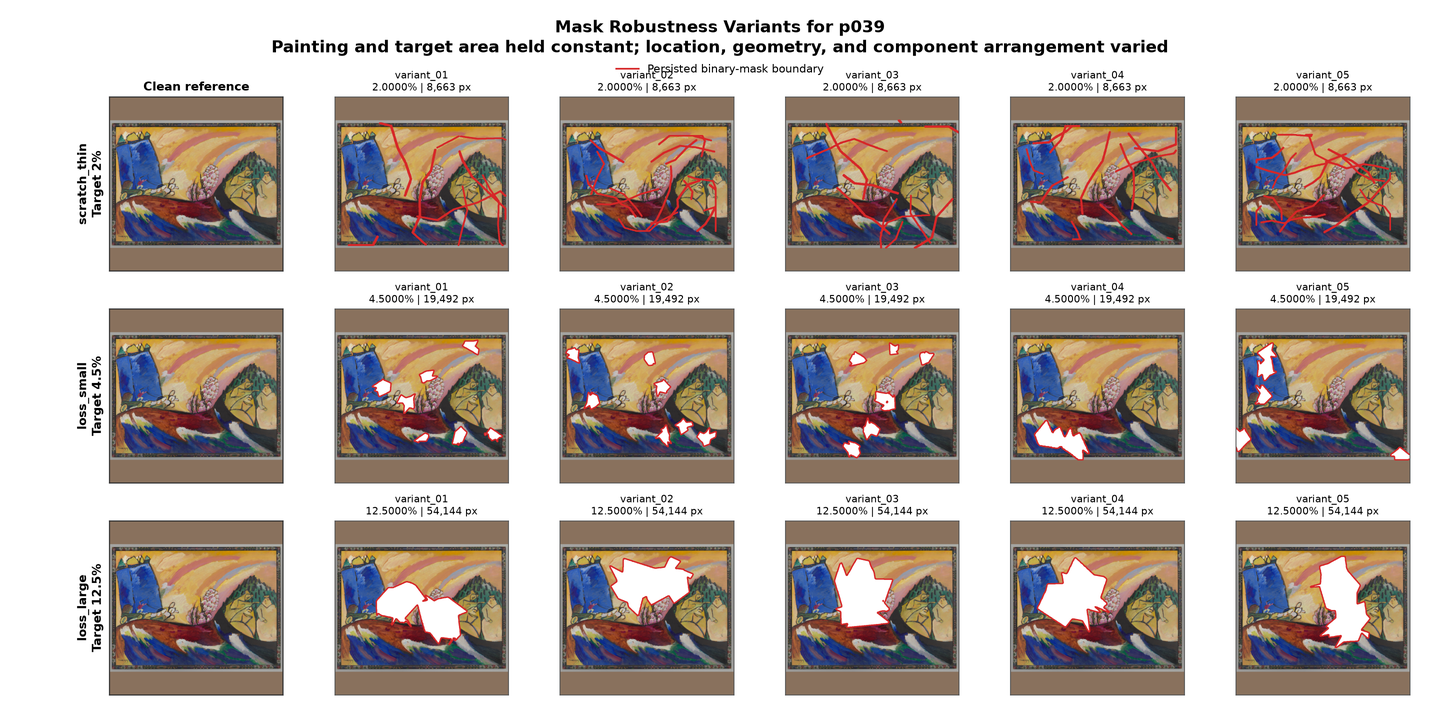

In [16]:
from matplotlib.lines import Line2D


# ---------------------------------------------------------------------------
# Configured example selection
# ---------------------------------------------------------------------------

EXAMPLE_PAINTING_ID = str(
    robustness_config[
        "examples"
    ][
        "painting_id"
    ]
)

EXAMPLE_MASK_TYPES = tuple(
    str(value)
    for value
    in robustness_config[
        "examples"
    ][
        "mask_types"
    ]
)

EXAMPLE_VARIANT_IDS = tuple(
    str(value)
    for value
    in robustness_config[
        "examples"
    ][
        "variant_ids"
    ]
)

EXAMPLE_FIGURE_DPI = int(
    robustness_config[
        "examples"
    ][
        "figure_dpi"
    ]
)

EXAMPLE_OVERLAY_CONTOUR = bool(
    robustness_config[
        "examples"
    ][
        "overlay_mask_contour"
    ]
)

EXAMPLE_ANNOTATE_PERCENTAGE = bool(
    robustness_config[
        "examples"
    ][
        "annotate_realized_percentage"
    ]
)

ROBUSTNESS_EXAMPLES_FIGURE_PATH = (
    OUTPUT_PATHS[
        "mask_robustness_examples"
    ]
)

PRE_FIGURE_OUTPUT_FILES = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}


# ---------------------------------------------------------------------------
# Select the exact configured 15 cases
# ---------------------------------------------------------------------------

example_cases_df = (
    robustness_cases_df.loc[
        robustness_cases_df[
            "painting_id"
        ]
        .astype(str)
        .eq(
            EXAMPLE_PAINTING_ID
        )
        & robustness_cases_df[
            "mask_type"
        ]
        .astype(str)
        .isin(
            EXAMPLE_MASK_TYPES
        )
        & robustness_cases_df[
            "variant_id"
        ]
        .astype(str)
        .isin(
            EXAMPLE_VARIANT_IDS
        )
    ]
    .copy()
)

example_cases_df[
    "example_family_order"
] = (
    example_cases_df[
        "mask_type"
    ]
    .map(
        {
            mask_type: index
            for index, mask_type
            in enumerate(
                EXAMPLE_MASK_TYPES
            )
        }
    )
)

example_cases_df[
    "example_variant_order"
] = (
    example_cases_df[
        "variant_id"
    ]
    .map(
        {
            variant_id: index
            for index, variant_id
            in enumerate(
                EXAMPLE_VARIANT_IDS
            )
        }
    )
)

example_cases_df = (
    example_cases_df
    .sort_values(
        [
            "example_family_order",
            "example_variant_order",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

example_audit_df = (
    example_cases_df[
        [
            "case_id",
            "mask_type",
            "variant_id",
        ]
    ]
    .merge(
        generation_audit_df[
            [
                "case_id",
                "validation_status",
                "binary_values_valid",
                "content_only_valid",
                "area_within_tolerance",
                "output_contract_valid",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
)


# ---------------------------------------------------------------------------
# Load the configured clean reference
# ---------------------------------------------------------------------------

example_clean_paths = (
    example_cases_df[
        "clean_image_path"
    ]
    .astype(str)
    .drop_duplicates()
    .tolist()
)

if len(
    example_clean_paths
) != 1:
    raise RuntimeError(
        "The configured example selection must "
        "resolve to one clean image path."
    )

example_clean_path = resolve_repo_path(
    example_clean_paths[0],
    PROJECT_ROOT,
    must_exist=True,
)

with Image.open(
    example_clean_path
) as opened_image:
    example_clean_image = (
        opened_image
        .convert("RGB")
    )
    example_clean_image.load()


# ---------------------------------------------------------------------------
# Canonical figure geometry
# ---------------------------------------------------------------------------

FIGURE_WIDTH_INCHES = 18.0
FIGURE_HEIGHT_INCHES = 9.0

EXPECTED_FIGURE_WIDTH_PIXELS = int(
    FIGURE_WIDTH_INCHES
    * EXAMPLE_FIGURE_DPI
)

EXPECTED_FIGURE_HEIGHT_PIXELS = int(
    FIGURE_HEIGHT_INCHES
    * EXAMPLE_FIGURE_DPI
)

figure_started = perf_counter()

robustness_examples_figure, example_axes = (
    plt.subplots(
        nrows=len(
            EXAMPLE_MASK_TYPES
        ),
        ncols=(
            len(
                EXAMPLE_VARIANT_IDS
            )
            + 1
        ),
        figsize=(
            FIGURE_WIDTH_INCHES,
            FIGURE_HEIGHT_INCHES,
        ),
        squeeze=False,
    )
)

robustness_examples_figure.patch.set_facecolor(
    "white"
)

panel_metadata_rows = []


# ---------------------------------------------------------------------------
# Render one family per row
# ---------------------------------------------------------------------------

for (
    family_index,
    mask_type,
) in enumerate(
    EXAMPLE_MASK_TYPES
):
    family_cases_df = (
        example_cases_df.loc[
            example_cases_df[
                "mask_type"
            ]
            .astype(str)
            .eq(
                mask_type
            )
        ]
        .sort_values(
            "example_variant_order",
            kind="stable",
        )
        .reset_index(
            drop=True
        )
    )

    target_percentage = (
        100.0
        * float(
            family_cases_df[
                "target_damage_fraction"
            ].iloc[0]
        )
    )

    clean_axis = example_axes[
        family_index,
        0,
    ]

    clean_axis.imshow(
        example_clean_image
    )

    clean_axis.set_ylabel(
        (
            f"{mask_type}\n"
            f"Target {target_percentage:g}%"
        ),
        fontsize=11,
        fontweight="semibold",
    )

    if family_index == 0:
        clean_axis.set_title(
            "Clean reference",
            fontsize=11,
            fontweight="semibold",
        )

    clean_axis.set_xticks([])
    clean_axis.set_yticks([])

    for spine in (
        clean_axis.spines.values()
    ):
        spine.set_edgecolor(
            "#333333"
        )
        spine.set_linewidth(
            1.0
        )

    for (
        variant_index,
        variant_id,
    ) in enumerate(
        EXAMPLE_VARIANT_IDS,
        start=1,
    ):
        case_matches = (
            family_cases_df.loc[
                family_cases_df[
                    "variant_id"
                ]
                .astype(str)
                .eq(
                    variant_id
                )
            ]
        )

        if len(
            case_matches
        ) != 1:
            raise RuntimeError(
                "Expected exactly one example "
                f"case for {mask_type}/"
                f"{variant_id}; observed "
                f"{len(case_matches)}."
            )

        case_row = (
            case_matches.iloc[0]
        )

        mask_path = resolve_repo_path(
            case_row[
                "mask_path"
            ],
            PROJECT_ROOT,
            must_exist=True,
        )

        damaged_path = resolve_repo_path(
            case_row[
                "damaged_image_path"
            ],
            PROJECT_ROOT,
            must_exist=True,
        )

        with Image.open(
            mask_path
        ) as opened_mask:
            mask_image = (
                opened_mask
                .convert("L")
            )
            mask_image.load()

        with Image.open(
            damaged_path
        ) as opened_damaged:
            damaged_image = (
                opened_damaged
                .convert("RGB")
            )
            damaged_image.load()

        mask_array = (
            np.asarray(
                mask_image
            )
            == int(
                robustness_config[
                    "generator"
                ][
                    "mask_damaged_value"
                ]
            )
        )

        axis = example_axes[
            family_index,
            variant_index,
        ]

        axis.imshow(
            damaged_image
        )

        if EXAMPLE_OVERLAY_CONTOUR:
            axis.contour(
                mask_array.astype(float),
                levels=[
                    0.5
                ],
                colors=[
                    "#d62728"
                ],
                linewidths=1.2,
            )

        realized_percentage = (
            100.0
            * float(
                case_row[
                    "realized_damage_fraction"
                ]
            )
        )

        annotation_text = (
            f"{realized_percentage:.4f}% | "
            f"{int(case_row['realized_damage_pixels']):,} px"
        )

        if EXAMPLE_ANNOTATE_PERCENTAGE:
            axis.set_title(
                (
                    f"{variant_id}\n"
                    f"{annotation_text}"
                ),
                fontsize=9,
            )
        else:
            axis.set_title(
                variant_id,
                fontsize=9,
            )

        axis.set_xticks([])
        axis.set_yticks([])

        for spine in (
            axis.spines.values()
        ):
            spine.set_edgecolor(
                "#555555"
            )
            spine.set_linewidth(
                0.8
            )

        panel_metadata_rows.append(
            {
                "case_id": str(
                    case_row[
                        "case_id"
                    ]
                ),
                "painting_id": str(
                    case_row[
                        "painting_id"
                    ]
                ),
                "mask_type": str(
                    mask_type
                ),
                "variant_id": str(
                    variant_id
                ),
                "mask_path": to_repo_relative(
                    mask_path,
                    PROJECT_ROOT,
                ),
                "damaged_path": to_repo_relative(
                    damaged_path,
                    PROJECT_ROOT,
                ),
                "mask_file_exists": (
                    mask_path.is_file()
                ),
                "damaged_file_exists": (
                    damaged_path.is_file()
                ),
                "mask_pixel_count": int(
                    mask_array.sum()
                ),
                "metadata_mask_pixel_count": int(
                    case_row[
                        "realized_damage_pixels"
                    ]
                ),
                "pixel_count_matches": (
                    int(
                        mask_array.sum()
                    )
                    == int(
                        case_row[
                            "realized_damage_pixels"
                        ]
                    )
                ),
                "contour_rendered": (
                    EXAMPLE_OVERLAY_CONTOUR
                ),
                "annotation_rendered": (
                    EXAMPLE_ANNOTATE_PERCENTAGE
                ),
                "annotation_text": (
                    annotation_text
                ),
            }
        )


# ---------------------------------------------------------------------------
# Figure title, legend, and spacing
# ---------------------------------------------------------------------------

robustness_examples_figure.suptitle(
    (
        "Mask Robustness Variants for "
        f"{EXAMPLE_PAINTING_ID}\n"
        "Painting and target area held constant; "
        "location, geometry, and component "
        "arrangement varied"
    ),
    fontsize=15,
    fontweight="semibold",
    y=0.975,
)

if EXAMPLE_OVERLAY_CONTOUR:
    contour_legend = Line2D(
        [0],
        [0],
        color="#d62728",
        linewidth=1.5,
        label="Persisted binary-mask boundary",
    )

    robustness_examples_figure.legend(
        handles=[
            contour_legend
        ],
        loc="upper center",
        bbox_to_anchor=(
            0.5,
            0.925,
        ),
        frameon=False,
        fontsize=10,
    )

robustness_examples_figure.subplots_adjust(
    left=0.06,
    right=0.995,
    bottom=0.035,
    top=0.865,
    wspace=0.025,
    hspace=0.22,
)


# ---------------------------------------------------------------------------
# Save the one canonical full-resolution figure
# ---------------------------------------------------------------------------

ROBUSTNESS_EXAMPLES_FIGURE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

robustness_examples_figure.savefig(
    ROBUSTNESS_EXAMPLES_FIGURE_PATH,
    format="png",
    dpi=EXAMPLE_FIGURE_DPI,
    facecolor="white",
)

figure_seconds = (
    perf_counter()
    - figure_started
)

plt.close(
    robustness_examples_figure
)

panel_metadata_df = pd.DataFrame(
    panel_metadata_rows
)


# ---------------------------------------------------------------------------
# Independently reload the saved figure
# ---------------------------------------------------------------------------

with Image.open(
    ROBUSTNESS_EXAMPLES_FIGURE_PATH
) as saved_figure:
    saved_figure_format = str(
        saved_figure.format
    )
    saved_figure_mode = str(
        saved_figure.mode
    )
    saved_figure_size = tuple(
        saved_figure.size
    )
    saved_figure.load()

    notebook_figure_preview = (
        saved_figure
        .convert("RGB")
        .copy()
    )

notebook_figure_preview.thumbnail(
    (
        1440,
        720,
    ),
    Image.Resampling.LANCZOS,
)

saved_figure_sha256 = sha256_file(
    ROBUSTNESS_EXAMPLES_FIGURE_PATH
)

saved_figure_size_bytes = (
    ROBUSTNESS_EXAMPLES_FIGURE_PATH
    .stat()
    .st_size
)


# ---------------------------------------------------------------------------
# Post-figure filesystem state
# ---------------------------------------------------------------------------

POST_FIGURE_OUTPUT_FILES = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

new_files_during_figure_batch = sorted(
    POST_FIGURE_OUTPUT_FILES
    - PRE_FIGURE_OUTPUT_FILES
)

removed_files_during_figure_batch = sorted(
    PRE_FIGURE_OUTPUT_FILES
    - POST_FIGURE_OUTPUT_FILES
)


print(
    "Canonical robustness figure saved."
)

print(
    "Example painting:",
    EXAMPLE_PAINTING_ID,
)

print(
    "Selected cases:",
    len(
        example_cases_df
    ),
)

print(
    "Rendered variant panels:",
    len(
        panel_metadata_df
    ),
)

print(
    "Figure path:",
    to_repo_relative(
        ROBUSTNESS_EXAMPLES_FIGURE_PATH,
        PROJECT_ROOT,
    ),
)

print(
    "Figure dimensions:",
    saved_figure_size,
)

print(
    "Figure size bytes:",
    saved_figure_size_bytes,
)

print(
    "Figure seconds:",
    round(
        figure_seconds,
        3,
    ),
)

display(
    notebook_figure_preview
)

In [17]:
# ---------------------------------------------------------------------------
# Batch 6 validation collector
# ---------------------------------------------------------------------------

BATCH_6_STAGE = (
    "batch_6_representative_visualization"
)

BATCH_6_START_CHECK_COUNT = len(
    VALIDATION.checks
)


def add_batch_6_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=BATCH_6_STAGE,
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# 1. Configured example identity

add_batch_6_check(
    check_id="configured_example_identity",
    description=(
        "The visualization uses the exact "
        "painting, families, and variants "
        "declared in the experiment config."
    ),
    expected={
        "painting_id": "p039",
        "mask_types": list(
            MASK_TYPES
        ),
        "variant_ids": [
            f"variant_{index:02d}"
            for index
            in range(
                1,
                6,
            )
        ],
    },
    observed={
        "painting_id": (
            EXAMPLE_PAINTING_ID
        ),
        "mask_types": list(
            EXAMPLE_MASK_TYPES
        ),
        "variant_ids": list(
            EXAMPLE_VARIANT_IDS
        ),
    },
    passed=(
        EXAMPLE_PAINTING_ID
        == "p039"
        and EXAMPLE_MASK_TYPES
        == MASK_TYPES
        and EXAMPLE_VARIANT_IDS
        == tuple(
            f"variant_{index:02d}"
            for index
            in range(
                1,
                6,
            )
        )
    ),
)


# 2. Selection cardinality

example_family_counts = (
    example_cases_df
    .groupby(
        "mask_type"
    )
    .size()
    .to_dict()
)

add_batch_6_check(
    check_id="example_selection_cardinality",
    description=(
        "The configured example contains all "
        "five variants for all three families."
    ),
    expected={
        "cases": 15,
        "families": 3,
        "cases_per_family": 5,
    },
    observed={
        "cases": len(
            example_cases_df
        ),
        "families": int(
            example_cases_df[
                "mask_type"
            ].nunique()
        ),
        "family_counts": (
            example_family_counts
        ),
    },
    passed=(
        len(
            example_cases_df
        )
        == 15
        and len(
            example_family_counts
        )
        == 3
        and set(
            example_family_counts.values()
        )
        == {
            5
        }
    ),
)


# 3. Unique panel identities

panel_identity_failures = {
    "duplicate_case_ids": int(
        panel_metadata_df[
            "case_id"
        ].duplicated().sum()
    ),
    "duplicate_family_variants": int(
        panel_metadata_df[
            [
                "mask_type",
                "variant_id",
            ]
        ]
        .duplicated()
        .sum()
    ),
    "duplicate_mask_paths": int(
        panel_metadata_df[
            "mask_path"
        ].duplicated().sum()
    ),
    "duplicate_damaged_paths": int(
        panel_metadata_df[
            "damaged_path"
        ].duplicated().sum()
    ),
}

add_batch_6_check(
    check_id="unique_example_panels",
    description=(
        "Every rendered panel has a unique "
        "case, family-variant, mask, and "
        "damaged-image identity."
    ),
    expected={
        key: 0
        for key
        in panel_identity_failures
    },
    observed=(
        panel_identity_failures
    ),
    passed=not any(
        panel_identity_failures.values()
    ),
)


# 4. Independently validated source cases

example_audit_failures = int(
    (
        example_audit_df[
            "validation_status"
        ]
        .astype(str)
        .ne("passed")
        | ~example_audit_df[
            "binary_values_valid"
        ]
        | ~example_audit_df[
            "content_only_valid"
        ]
        | ~example_audit_df[
            "area_within_tolerance"
        ]
        | ~example_audit_df[
            "output_contract_valid"
        ]
    ).sum()
)

add_batch_6_check(
    check_id="example_cases_validated",
    description=(
        "Every selected visualization case "
        "passed the independent saved-image "
        "audit and scientific invariants."
    ),
    expected={
        "cases": 15,
        "failures": 0,
    },
    observed={
        "cases": len(
            example_audit_df
        ),
        "failures": (
            example_audit_failures
        ),
    },
    passed=(
        len(
            example_audit_df
        )
        == 15
        and example_audit_failures
        == 0
    ),
)


# 5. Source image existence

source_file_failures = int(
    (
        ~panel_metadata_df[
            [
                "mask_file_exists",
                "damaged_file_exists",
            ]
        ]
    ).sum().sum()
)

add_batch_6_check(
    check_id="example_source_files",
    description=(
        "Every selected mask and damaged "
        "image exists when the figure is built."
    ),
    expected=0,
    observed=(
        source_file_failures
    ),
    passed=(
        source_file_failures
        == 0
    ),
)


# 6. Panel pixel-count replay

panel_pixel_failures = int(
    (
        ~panel_metadata_df[
            "pixel_count_matches"
        ]
    ).sum()
)

add_batch_6_check(
    check_id="example_panel_pixel_replay",
    description=(
        "Every rendered mask panel reproduces "
        "its recorded damage-pixel count."
    ),
    expected=0,
    observed=(
        panel_pixel_failures
    ),
    passed=(
        panel_pixel_failures
        == 0
    ),
)


# 7. Contour and annotation contract

panel_rendering_failures = int(
    (
        ~panel_metadata_df[
            [
                "contour_rendered",
                "annotation_rendered",
            ]
        ]
    ).sum().sum()
)

add_batch_6_check(
    check_id="example_panel_annotations",
    description=(
        "Every variant panel includes the "
        "configured mask contour and realized "
        "area annotation."
    ),
    expected={
        "contour_failures": 0,
        "annotation_failures": 0,
    },
    observed={
        "contour_failures": int(
            (
                ~panel_metadata_df[
                    "contour_rendered"
                ]
            ).sum()
        ),
        "annotation_failures": int(
            (
                ~panel_metadata_df[
                    "annotation_rendered"
                ]
            ).sum()
        ),
    },
    passed=(
        panel_rendering_failures
        == 0
        and EXAMPLE_OVERLAY_CONTOUR
        and EXAMPLE_ANNOTATE_PERCENTAGE
    ),
)


# 8. Exact canonical figure path

expected_figure_path = (
    OUTPUT_ROOT
    / robustness_config[
        "output"
    ][
        "examples_figure_path"
    ]
)

add_batch_6_check(
    check_id="canonical_figure_path",
    description=(
        "The example figure uses the exact "
        "configured notebook-owned output path."
    ),
    expected=to_repo_relative(
        expected_figure_path,
        PROJECT_ROOT,
    ),
    observed=to_repo_relative(
        ROBUSTNESS_EXAMPLES_FIGURE_PATH,
        PROJECT_ROOT,
    ),
    passed=(
        ROBUSTNESS_EXAMPLES_FIGURE_PATH
        .resolve()
        == expected_figure_path.resolve()
    ),
)


# 9. Figure existence and nonempty file

add_batch_6_check(
    check_id="canonical_figure_exists",
    description=(
        "The canonical robustness figure exists "
        "as a nonempty file."
    ),
    expected={
        "exists": True,
        "minimum_size_bytes": 1,
    },
    observed={
        "exists": (
            ROBUSTNESS_EXAMPLES_FIGURE_PATH
            .is_file()
        ),
        "size_bytes": (
            saved_figure_size_bytes
        ),
    },
    passed=(
        ROBUSTNESS_EXAMPLES_FIGURE_PATH
        .is_file()
        and saved_figure_size_bytes
        > 0
    ),
)


# 10. Saved PNG format, mode, and geometry

add_batch_6_check(
    check_id="canonical_figure_image_contract",
    description=(
        "The saved figure reloads with the "
        "configured PNG format and exact "
        "full-resolution dimensions."
    ),
    expected={
        "format": "PNG",
        "allowed_modes": [
            "RGB",
            "RGBA",
        ],
        "size": [
            EXPECTED_FIGURE_WIDTH_PIXELS,
            EXPECTED_FIGURE_HEIGHT_PIXELS,
        ],
    },
    observed={
        "format": (
            saved_figure_format
        ),
        "mode": (
            saved_figure_mode
        ),
        "size": list(
            saved_figure_size
        ),
    },
    passed=(
        saved_figure_format
        == "PNG"
        and saved_figure_mode
        in {
            "RGB",
            "RGBA",
        }
        and saved_figure_size
        == (
            EXPECTED_FIGURE_WIDTH_PIXELS,
            EXPECTED_FIGURE_HEIGHT_PIXELS,
        )
    ),
)


# 11. Figure checksum

add_batch_6_check(
    check_id="canonical_figure_checksum",
    description=(
        "The canonical figure has a complete "
        "SHA-256 checksum for manifest handoff."
    ),
    expected={
        "sha256_length": 64,
        "size_bytes_positive": True,
    },
    observed={
        "sha256": (
            saved_figure_sha256
        ),
        "sha256_length": len(
            saved_figure_sha256
        ),
        "size_bytes_positive": (
            saved_figure_size_bytes
            > 0
        ),
    },
    passed=(
        len(
            saved_figure_sha256
        )
        == 64
        and saved_figure_size_bytes
        > 0
    ),
)


# 12. Figure is the only new output

expected_new_figure_files = {
    ROBUSTNESS_EXAMPLES_FIGURE_PATH
    .resolve()
}

add_batch_6_check(
    check_id="figure_batch_output_scope",
    description=(
        "Batch 6 creates exactly the one "
        "canonical figure and removes no "
        "existing output."
    ),
    expected={
        "new_files": [
            to_repo_relative(
                ROBUSTNESS_EXAMPLES_FIGURE_PATH,
                PROJECT_ROOT,
            )
        ],
        "removed_files": [],
    },
    observed={
        "new_files": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path
            in new_files_during_figure_batch
        ],
        "removed_files": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path
            in removed_files_during_figure_batch
        ],
    },
    passed=(
        set(
            new_files_during_figure_batch
        )
        == expected_new_figure_files
        and not (
            removed_files_during_figure_batch
        )
    ),
)


# 13. Expected intermediate output state

add_batch_6_check(
    check_id="post_figure_output_state",
    description=(
        "After Batch 6 the output root contains "
        "150 case images and one canonical "
        "figure, with no premature table or "
        "manifest artifact."
    ),
    expected={
        "owned_files": 151,
        "mask_files": 75,
        "damaged_files": 75,
        "figure_files": 1,
    },
    observed={
        "owned_files": len(
            POST_FIGURE_OUTPUT_FILES
        ),
        "mask_files": len(
            saved_mask_paths
        ),
        "damaged_files": len(
            saved_damaged_paths
        ),
        "figure_files": int(
            ROBUSTNESS_EXAMPLES_FIGURE_PATH
            .is_file()
        ),
    },
    passed=(
        len(
            POST_FIGURE_OUTPUT_FILES
        )
        == 151
        and len(
            saved_mask_paths
        )
        == 75
        and len(
            saved_damaged_paths
        )
        == 75
        and ROBUSTNESS_EXAMPLES_FIGURE_PATH
        .is_file()
    ),
)


# ---------------------------------------------------------------------------
# Batch 6 completion gate and rendered evidence
# ---------------------------------------------------------------------------

BATCH_6_CHECK_COUNT = (
    len(
        VALIDATION.checks
    )
    - BATCH_6_START_CHECK_COUNT
)

if BATCH_6_CHECK_COUNT != 13:
    raise RuntimeError(
        "Batch 6 must add exactly "
        f"13 checks; observed "
        f"{BATCH_6_CHECK_COUNT}."
    )

VALIDATION.raise_for_blocking()

batch_6_checks_df = (
    VALIDATION.to_dataframe()
    .iloc[
        BATCH_6_START_CHECK_COUNT:
    ]
    .reset_index(
        drop=True
    )
)

print(
    "Batch 6 validation checks:"
)

display(
    batch_6_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nConfigured example cases:"
)

display(
    example_cases_df[
        [
            "painting_id",
            "mask_type",
            "variant_id",
            "target_damage_fraction",
            "realized_damage_fraction",
            "realized_damage_pixels",
            "case_id",
        ]
    ]
)

print(
    "\nFigure panel metadata:"
)

display(
    panel_metadata_df[
        [
            "mask_type",
            "variant_id",
            "mask_pixel_count",
            "metadata_mask_pixel_count",
            "pixel_count_matches",
            "contour_rendered",
            "annotation_rendered",
        ]
    ]
)

figure_evidence_df = pd.DataFrame(
    [
        {
            "relative_path": to_repo_relative(
                ROBUSTNESS_EXAMPLES_FIGURE_PATH,
                PROJECT_ROOT,
            ),
            "format": (
                saved_figure_format
            ),
            "mode": (
                saved_figure_mode
            ),
            "width": (
                saved_figure_size[0]
            ),
            "height": (
                saved_figure_size[1]
            ),
            "size_bytes": (
                saved_figure_size_bytes
            ),
            "sha256": (
                saved_figure_sha256
            ),
            "render_seconds": (
                figure_seconds
            ),
        }
    ]
)

print(
    "\nCanonical figure evidence:"
)

display(
    figure_evidence_df
)

print(
    "\nBatch 6 completed successfully."
)

print(
    "Batch 6 checks:",
    BATCH_6_CHECK_COUNT,
)

print(
    "Total accumulated checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Blocking failures:",
    len(
        VALIDATION.blocking_failures
    ),
)

print(
    "Persisted output files:",
    len(
        POST_FIGURE_OUTPUT_FILES
    ),
)

print(
    "Next approved stage: Batch 7 - "
    "canonical table persistence, validation "
    "report, and normalized manifests."
)

Batch 6 validation checks:


,check_id,severity,expected,observed,passed
0,configured_example_identity,blocking,"{""mask_types"": [""scratch_thin"", ""loss_small"", ...","{""mask_types"": [""scratch_thin"", ""loss_small"", ...",True
1,example_selection_cardinality,blocking,"{""cases"": 15, ""cases_per_family"": 5, ""families...","{""cases"": 15, ""families"": 3, ""family_counts"": ...",True
2,unique_example_panels,blocking,"{""duplicate_case_ids"": 0, ""duplicate_damaged_p...","{""duplicate_case_ids"": 0, ""duplicate_damaged_p...",True
3,example_cases_validated,blocking,"{""cases"": 15, ""failures"": 0}","{""cases"": 15, ""failures"": 0}",True
4,example_source_files,blocking,0,0,True
5,example_panel_pixel_replay,blocking,0,0,True
6,example_panel_annotations,blocking,"{""annotation_failures"": 0, ""contour_failures"": 0}","{""annotation_failures"": 0, ""contour_failures"": 0}",True
7,canonical_figure_path,blocking,outputs/06_mask_robustness_dataset_generation/...,outputs/06_mask_robustness_dataset_generation/...,True
8,canonical_figure_exists,blocking,"{""exists"": true, ""minimum_size_bytes"": 1}","{""exists"": true, ""size_bytes"": 3141366}",True
9,canonical_figure_image_contract,blocking,"{""allowed_modes"": [""RGB"", ""RGBA""], ""format"": ""...","{""format"": ""PNG"", ""mode"": ""RGBA"", ""size"": [288...",True



Configured example cases:


,painting_id,mask_type,variant_id,target_damage_fraction,realized_damage_fraction,realized_damage_pixels,case_id
0,p039,scratch_thin,variant_01,0.020,0.020,8663,mask_robustness__p039__scratch_thin__target_02...
1,p039,scratch_thin,variant_02,0.020,0.020,8663,mask_robustness__p039__scratch_thin__target_02...
2,p039,scratch_thin,variant_03,0.020,0.020,8663,mask_robustness__p039__scratch_thin__target_02...
3,p039,scratch_thin,variant_04,0.020,0.020,8663,mask_robustness__p039__scratch_thin__target_02...
4,p039,scratch_thin,variant_05,0.020,0.020,8663,mask_robustness__p039__scratch_thin__target_02...
5,p039,loss_small,variant_01,0.045,0.045,19492,mask_robustness__p039__loss_small__target_04p5...
6,p039,loss_small,variant_02,0.045,0.045,19492,mask_robustness__p039__loss_small__target_04p5...
7,p039,loss_small,variant_03,0.045,0.045,19492,mask_robustness__p039__loss_small__target_04p5...
8,p039,loss_small,variant_04,0.045,0.045,19492,mask_robustness__p039__loss_small__target_04p5...
9,p039,loss_small,variant_05,0.045,0.045,19492,mask_robustness__p039__loss_small__target_04p5...



Figure panel metadata:


,mask_type,variant_id,mask_pixel_count,metadata_mask_pixel_count,pixel_count_matches,contour_rendered,annotation_rendered
0,scratch_thin,variant_01,8663,8663,True,True,True
1,scratch_thin,variant_02,8663,8663,True,True,True
2,scratch_thin,variant_03,8663,8663,True,True,True
3,scratch_thin,variant_04,8663,8663,True,True,True
4,scratch_thin,variant_05,8663,8663,True,True,True
5,loss_small,variant_01,19492,19492,True,True,True
6,loss_small,variant_02,19492,19492,True,True,True
7,loss_small,variant_03,19492,19492,True,True,True
8,loss_small,variant_04,19492,19492,True,True,True
9,loss_small,variant_05,19492,19492,True,True,True



Canonical figure evidence:


,relative_path,format,mode,width,height,size_bytes,sha256,render_seconds
0,outputs/06_mask_robustness_dataset_generation/...,PNG,RGBA,2880,1440,3141366,781ad154746f7ca976b08bc2fed46d3c41322d746e3567...,7.67685



Batch 6 completed successfully.
Batch 6 checks: 13
Total accumulated checks: 102
Blocking failures: 0
Persisted output files: 151
Next approved stage: Batch 7 - canonical table persistence, validation report, and normalized manifests.


## Batch 7 - Canonical Persistence and Provisional Handoff

This batch persists the validated Notebook 06 handoff:

- `data/cases.csv`;
- `metrics/generation_audit.csv`;
- `validation/checks.csv`;
- `manifests/artifacts.csv`;
- provisional `manifests/run_manifest.json`.

It will independently reload the three persisted CSV files, revalidate their schemas and identities, checksum both image collections and the canonical figure, build the six-record normalized artifact manifest, and verify the exact 156-file Notebook 06 output contract.

The 102 consolidated scientific checks remain separate from the persistence and manifest-handoff checks.

The run manifest remains in a `running` state until Batch 8 performs the final completion audit, project-path registry update, and completed-manifest rewrite.

In [18]:
from restoration_eval.mask_robustness import (
    write_dataframe_atomic,
)

from restoration_eval.manifests import (
    RUN_MANIFEST_SCHEMA_VERSION,
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    sha256_path,
    write_artifact_manifest,
    write_run_manifest,
)

from restoration_eval.schemas import (
    RUN_MANIFEST_REQUIRED_KEYS,
)


EXPECTED_CONSOLIDATED_VALIDATION_ROWS = 102


# ---------------------------------------------------------------------------
# Pre-persistence gate
# ---------------------------------------------------------------------------

if not VALIDATION.overall_passed:
    raise RuntimeError(
        "The consolidated Notebook 06 validation "
        "gate has not passed."
    )

validation_checks_df = (
    VALIDATION.to_dataframe()
)

if len(
    validation_checks_df
) != EXPECTED_CONSOLIDATED_VALIDATION_ROWS:
    raise RuntimeError(
        "Exactly "
        f"{EXPECTED_CONSOLIDATED_VALIDATION_ROWS} "
        "consolidated validation rows are required; "
        f"found {len(validation_checks_df)}."
    )

if len(
    robustness_cases_df
) != EXPECTED_CASE_COUNT:
    raise RuntimeError(
        "The robustness case table does not "
        "contain the expected number of rows."
    )

if len(
    generation_audit_df
) != EXPECTED_AUDIT_ROW_COUNT:
    raise RuntimeError(
        "The generation audit does not contain "
        "the expected number of rows."
    )


# ---------------------------------------------------------------------------
# Validate ownership of every declared output
# ---------------------------------------------------------------------------

output_ownership_failures = []

for (
    output_key,
    output_path,
) in OUTPUT_PATHS.items():
    try:
        validated_output_path = (
            require_notebook_output_path(
                output_path,
                NOTEBOOK_STEM,
                PROJECT_ROOT,
            )
        )

        if (
            validated_output_path
            != output_path.resolve()
        ):
            output_ownership_failures.append(
                {
                    "output_key": output_key,
                    "path": str(
                        output_path
                    ),
                    "issue": (
                        "resolved_path_mismatch"
                    ),
                }
            )

    except Exception as exc:
        output_ownership_failures.append(
            {
                "output_key": output_key,
                "path": str(
                    output_path
                ),
                "issue": (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                ),
            }
        )

if output_ownership_failures:
    raise RuntimeError(
        "One or more output paths violate "
        "Notebook 06 ownership: "
        f"{output_ownership_failures}"
    )


# ---------------------------------------------------------------------------
# Atomic canonical CSV persistence
# ---------------------------------------------------------------------------

write_dataframe_atomic(
    robustness_cases_df,
    OUTPUT_PATHS[
        "mask_robustness_cases"
    ],
)

write_dataframe_atomic(
    generation_audit_df,
    OUTPUT_PATHS[
        "mask_robustness_generation_audit"
    ],
)

write_dataframe_atomic(
    validation_checks_df,
    OUTPUT_PATHS[
        "validation_checks"
    ],
)


# ---------------------------------------------------------------------------
# Immediate independent CSV reload
# ---------------------------------------------------------------------------

robustness_cases_reloaded_df = pd.read_csv(
    OUTPUT_PATHS[
        "mask_robustness_cases"
    ],
    low_memory=False,
)

generation_audit_reloaded_df = pd.read_csv(
    OUTPUT_PATHS[
        "mask_robustness_generation_audit"
    ],
    low_memory=False,
)

validation_checks_reloaded_df = pd.read_csv(
    OUTPUT_PATHS[
        "validation_checks"
    ],
    low_memory=False,
)


cases_reload_schema_result = (
    validate_dataframe(
        robustness_cases_reloaded_df,
        MASK_ROBUSTNESS_CASES_SCHEMA,
        allow_extra_columns=False,
    )
)

audit_reload_schema_result = (
    validate_dataframe(
        generation_audit_reloaded_df,
        MASK_ROBUSTNESS_GENERATION_AUDIT_SCHEMA,
        allow_extra_columns=False,
    )
)

validation_reload_schema_result = (
    validate_dataframe(
        validation_checks_reloaded_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Reload identity evidence
# ---------------------------------------------------------------------------

expected_case_ids = set(
    robustness_cases_df[
        "case_id"
    ].astype(str)
)

reloaded_case_ids = set(
    robustness_cases_reloaded_df[
        "case_id"
    ].astype(str)
)

expected_audit_case_ids = set(
    generation_audit_df[
        "case_id"
    ].astype(str)
)

reloaded_audit_case_ids = set(
    generation_audit_reloaded_df[
        "case_id"
    ].astype(str)
)

expected_mask_relative_paths = set(
    robustness_cases_df[
        "mask_path"
    ].astype(str)
)

reloaded_mask_table_paths = set(
    robustness_cases_reloaded_df[
        "mask_path"
    ].astype(str)
)

expected_damaged_relative_paths = set(
    robustness_cases_df[
        "damaged_image_path"
    ].astype(str)
)

reloaded_damaged_table_paths = set(
    robustness_cases_reloaded_df[
        "damaged_image_path"
    ].astype(str)
)

expected_validation_keys = {
    (
        str(
            check.validation_stage
        ),
        str(
            check.check_id
        ),
    )
    for check
    in VALIDATION.checks
}

reloaded_validation_keys = {
    (
        str(
            row.validation_stage
        ),
        str(
            row.check_id
        ),
    )
    for row
    in validation_checks_reloaded_df.itertuples(
        index=False
    )
}

all_reloaded_validation_checks_passed = bool(
    validation_checks_reloaded_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
    .all()
)


# ---------------------------------------------------------------------------
# Reload and checksum both image collections
# ---------------------------------------------------------------------------

reloaded_mask_files = sorted(
    path
    for path
    in MASK_OUTPUT_DIRECTORY.rglob(
        "*.png"
    )
    if path.is_file()
)

reloaded_damaged_files = sorted(
    path
    for path
    in DAMAGED_OUTPUT_DIRECTORY.rglob(
        "*.png"
    )
    if path.is_file()
)

reloaded_mask_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path
    in reloaded_mask_files
}

reloaded_damaged_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path
    in reloaded_damaged_files
}

mask_checksum_failures = []
damaged_checksum_failures = []

for case_row in (
    robustness_cases_reloaded_df
    .itertuples(
        index=False
    )
):
    mask_path = resolve_repo_path(
        str(
            case_row.mask_path
        ),
        PROJECT_ROOT,
        must_exist=True,
    )

    damaged_path = resolve_repo_path(
        str(
            case_row.damaged_image_path
        ),
        PROJECT_ROOT,
        must_exist=True,
    )

    observed_mask_checksum = (
        sha256_file(
            mask_path
        )
    )

    observed_damaged_checksum = (
        sha256_file(
            damaged_path
        )
    )

    if (
        observed_mask_checksum
        != str(
            case_row.mask_sha256
        )
    ):
        mask_checksum_failures.append(
            {
                "case_id": (
                    case_row.case_id
                ),
                "relative_path": (
                    case_row.mask_path
                ),
                "expected_checksum": (
                    case_row.mask_sha256
                ),
                "observed_checksum": (
                    observed_mask_checksum
                ),
            }
        )

    if (
        observed_damaged_checksum
        != str(
            case_row.damaged_image_sha256
        )
    ):
        damaged_checksum_failures.append(
            {
                "case_id": (
                    case_row.case_id
                ),
                "relative_path": (
                    case_row.damaged_image_path
                ),
                "expected_checksum": (
                    case_row.damaged_image_sha256
                ),
                "observed_checksum": (
                    observed_damaged_checksum
                ),
            }
        )


# ---------------------------------------------------------------------------
# Reload the canonical figure
# ---------------------------------------------------------------------------

with Image.open(
    OUTPUT_PATHS[
        "mask_robustness_examples"
    ]
) as figure_file:
    figure_file.load()

    persisted_figure_evidence = {
        "format": str(
            figure_file.format
        ),
        "mode": str(
            figure_file.mode
        ),
        "width": int(
            figure_file.width
        ),
        "height": int(
            figure_file.height
        ),
        "size_bytes": int(
            OUTPUT_PATHS[
                "mask_robustness_examples"
            ].stat().st_size
        ),
        "sha256": sha256_file(
            OUTPUT_PATHS[
                "mask_robustness_examples"
            ]
        ),
    }


# ---------------------------------------------------------------------------
# Separate canonical-persistence validation gate
# ---------------------------------------------------------------------------

PERSISTENCE_VALIDATION = (
    ValidationCollector()
)


def add_persistence_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    PERSISTENCE_VALIDATION.add(
        validation_stage=(
            "canonical_persistence"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(
            passed
        ),
        details=details,
    )


# 1. Output ownership

add_persistence_check(
    check_id="output_path_ownership",
    description=(
        "Every declared output remains inside "
        "the exact Notebook 06 output root."
    ),
    expected=[],
    observed=(
        output_ownership_failures
    ),
    passed=not (
        output_ownership_failures
    ),
)


# 2. Cases CSV

cases_reload_passed = (
    cases_reload_schema_result.passed
    and not (
        cases_reload_schema_result
        .unexpected_columns
    )
    and len(
        robustness_cases_reloaded_df
    )
    == EXPECTED_CASE_COUNT
    and reloaded_case_ids
    == expected_case_ids
    and reloaded_mask_table_paths
    == expected_mask_relative_paths
    and reloaded_damaged_table_paths
    == expected_damaged_relative_paths
)

add_persistence_check(
    check_id="mask_robustness_cases_csv_reload",
    description=(
        "Persisted cases.csv reloads under "
        "mask_robustness_cases.v1 with every "
        "expected case and image path."
    ),
    expected={
        "rows": EXPECTED_CASE_COUNT,
        "schema_passed": True,
        "case_ids_match": True,
        "mask_paths_match": True,
        "damaged_paths_match": True,
    },
    observed={
        "rows": len(
            robustness_cases_reloaded_df
        ),
        "schema": (
            cases_reload_schema_result
            .to_dict()
        ),
        "case_ids_match": (
            reloaded_case_ids
            == expected_case_ids
        ),
        "mask_paths_match": (
            reloaded_mask_table_paths
            == expected_mask_relative_paths
        ),
        "damaged_paths_match": (
            reloaded_damaged_table_paths
            == expected_damaged_relative_paths
        ),
    },
    passed=(
        cases_reload_passed
    ),
)


# 3. Generation-audit CSV

audit_reload_passed = (
    audit_reload_schema_result.passed
    and not (
        audit_reload_schema_result
        .unexpected_columns
    )
    and len(
        generation_audit_reloaded_df
    )
    == EXPECTED_AUDIT_ROW_COUNT
    and reloaded_audit_case_ids
    == expected_audit_case_ids
    and generation_audit_reloaded_df[
        "validation_status"
    ].eq("passed").all()
)

add_persistence_check(
    check_id="generation_audit_csv_reload",
    description=(
        "Persisted generation_audit.csv reloads "
        "under its exact schema with every "
        "expected passing case."
    ),
    expected={
        "rows": EXPECTED_AUDIT_ROW_COUNT,
        "schema_passed": True,
        "case_ids_match": True,
        "failed_cases": 0,
    },
    observed={
        "rows": len(
            generation_audit_reloaded_df
        ),
        "schema": (
            audit_reload_schema_result
            .to_dict()
        ),
        "case_ids_match": (
            reloaded_audit_case_ids
            == expected_audit_case_ids
        ),
        "failed_cases": int(
            generation_audit_reloaded_df[
                "validation_status"
            ]
            .ne("passed")
            .sum()
        ),
    },
    passed=(
        audit_reload_passed
    ),
)


# 4. Consolidated validation CSV

validation_csv_reload_passed = (
    validation_reload_schema_result.passed
    and not (
        validation_reload_schema_result
        .unexpected_columns
    )
    and len(
        validation_checks_reloaded_df
    )
    == EXPECTED_CONSOLIDATED_VALIDATION_ROWS
    and reloaded_validation_keys
    == expected_validation_keys
    and all_reloaded_validation_checks_passed
)

add_persistence_check(
    check_id="validation_checks_csv_reload",
    description=(
        "Persisted checks.csv reloads under "
        "validation_checks.v1 with all 102 "
        "unique passing consolidated checks."
    ),
    expected={
        "rows": (
            EXPECTED_CONSOLIDATED_VALIDATION_ROWS
        ),
        "schema_passed": True,
        "keys_match": True,
        "all_passed": True,
    },
    observed={
        "rows": len(
            validation_checks_reloaded_df
        ),
        "schema": (
            validation_reload_schema_result
            .to_dict()
        ),
        "keys_match": (
            reloaded_validation_keys
            == expected_validation_keys
        ),
        "all_passed": (
            all_reloaded_validation_checks_passed
        ),
    },
    passed=(
        validation_csv_reload_passed
    ),
)


# 5. Mask collection

mask_collection_reload_passed = (
    len(
        reloaded_mask_files
    )
    == EXPECTED_MASK_FILE_COUNT
    and reloaded_mask_relative_paths
    == expected_mask_relative_paths
    and not (
        mask_checksum_failures
    )
)

add_persistence_check(
    check_id="mask_collection_reload",
    description=(
        "The persisted mask collection contains "
        "exactly 75 declared PNGs and every mask "
        "matches its case-table checksum."
    ),
    expected={
        "file_count": (
            EXPECTED_MASK_FILE_COUNT
        ),
        "paths_match": True,
        "checksum_failures": 0,
    },
    observed={
        "file_count": len(
            reloaded_mask_files
        ),
        "paths_match": (
            reloaded_mask_relative_paths
            == expected_mask_relative_paths
        ),
        "checksum_failures": len(
            mask_checksum_failures
        ),
    },
    passed=(
        mask_collection_reload_passed
    ),
    details=(
        mask_checksum_failures
    ),
)


# 6. Damaged-image collection

damaged_collection_reload_passed = (
    len(
        reloaded_damaged_files
    )
    == EXPECTED_DAMAGED_FILE_COUNT
    and reloaded_damaged_relative_paths
    == expected_damaged_relative_paths
    and not (
        damaged_checksum_failures
    )
)

add_persistence_check(
    check_id="damaged_collection_reload",
    description=(
        "The persisted damaged-image collection "
        "contains exactly 75 declared PNGs and "
        "every image matches its checksum."
    ),
    expected={
        "file_count": (
            EXPECTED_DAMAGED_FILE_COUNT
        ),
        "paths_match": True,
        "checksum_failures": 0,
    },
    observed={
        "file_count": len(
            reloaded_damaged_files
        ),
        "paths_match": (
            reloaded_damaged_relative_paths
            == expected_damaged_relative_paths
        ),
        "checksum_failures": len(
            damaged_checksum_failures
        ),
    },
    passed=(
        damaged_collection_reload_passed
    ),
    details=(
        damaged_checksum_failures
    ),
)


# 7. Canonical figure

figure_reload_passed = (
    persisted_figure_evidence[
        "format"
    ]
    == "PNG"
    and persisted_figure_evidence[
        "mode"
    ]
    in {
        "RGB",
        "RGBA",
    }
    and persisted_figure_evidence[
        "width"
    ]
    == EXPECTED_FIGURE_WIDTH_PIXELS
    and persisted_figure_evidence[
        "height"
    ]
    == EXPECTED_FIGURE_HEIGHT_PIXELS
    and persisted_figure_evidence[
        "sha256"
    ]
    == saved_figure_sha256
)

add_persistence_check(
    check_id="robustness_figure_reload",
    description=(
        "The canonical robustness figure reloads "
        "as a full-resolution PNG and retains "
        "its Batch 6 checksum."
    ),
    expected={
        "format": "PNG",
        "allowed_modes": [
            "RGB",
            "RGBA",
        ],
        "dimensions": [
            EXPECTED_FIGURE_WIDTH_PIXELS,
            EXPECTED_FIGURE_HEIGHT_PIXELS,
        ],
        "checksum": (
            saved_figure_sha256
        ),
    },
    observed=(
        persisted_figure_evidence
    ),
    passed=(
        figure_reload_passed
    ),
)


persistence_checks_df = (
    PERSISTENCE_VALIDATION
    .to_dataframe()
)

if len(
    persistence_checks_df
) != 7:
    raise RuntimeError(
        "Batch 7 must produce exactly seven "
        "canonical-persistence checks."
    )

PERSISTENCE_VALIDATION.raise_for_blocking()

print(
    "Canonical persistence validation passed:",
    PERSISTENCE_VALIDATION.overall_passed,
)

display(
    persistence_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

print(
    "Persisted cases:",
    robustness_cases_reloaded_df.shape,
)

print(
    "Persisted generation audit:",
    generation_audit_reloaded_df.shape,
)

print(
    "Persisted consolidated checks:",
    validation_checks_reloaded_df.shape,
)

Canonical persistence validation passed: True


,check_id,severity,passed
0,output_path_ownership,blocking,True
1,mask_robustness_cases_csv_reload,blocking,True
2,generation_audit_csv_reload,blocking,True
3,validation_checks_csv_reload,blocking,True
4,mask_collection_reload,blocking,True
5,damaged_collection_reload,blocking,True
6,robustness_figure_reload,blocking,True


Persisted cases: (75, 86)
Persisted generation audit: (75, 63)
Persisted consolidated checks: (102, 8)


In [19]:
# ---------------------------------------------------------------------------
# Normalized output metadata
# ---------------------------------------------------------------------------

dataset_scope = str(
    robustness_config[
        "dataset"
    ][
        "dataset_scope"
    ]
)

experiment_id = str(
    robustness_config[
        "dataset"
    ][
        "experiment_id"
    ]
)

output_metadata = {
    "mask_robustness_cases": {
        "artifact_type": "dataset_table",
        "artifact_role": "primary_case_manifest",
        "schema_version": (
            MASK_ROBUSTNESS_CASES_SCHEMA
            .version
        ),
    },
    "mask_robustness_masks": {
        "artifact_type": "image_collection",
        "artifact_role": "mask_collection",
        "schema_version": (
            "mask_robustness_masks.v1"
        ),
    },
    "mask_robustness_damaged_images": {
        "artifact_type": "image_collection",
        "artifact_role": "damaged_image_collection",
        "schema_version": (
            "mask_robustness_damaged_images.v1"
        ),
    },
    "mask_robustness_generation_audit": {
        "artifact_type": "audit_table",
        "artifact_role": "generation_audit",
        "schema_version": (
            MASK_ROBUSTNESS_GENERATION_AUDIT_SCHEMA
            .version
        ),
    },
    "mask_robustness_examples": {
        "artifact_type": "figure",
        "artifact_role": "representative_visual_evidence",
        "schema_version": (
            "mask_robustness_examples.v1"
        ),
    },
    "validation_checks": {
        "artifact_type": "validation_table",
        "artifact_role": "validation_evidence",
        "schema_version": (
            VALIDATION_CHECKS_SCHEMA
            .version
        ),
    },
    "artifact_manifest": {
        "artifact_type": "manifest",
        "artifact_role": "artifact_registry",
        "schema_version": (
            ARTIFACT_MANIFEST_SCHEMA
            .version
        ),
    },
    "run_manifest": {
        "artifact_type": "manifest",
        "artifact_role": "run_provenance",
        "schema_version": (
            RUN_MANIFEST_SCHEMA_VERSION
        ),
    },
}


# ---------------------------------------------------------------------------
# Six externally meaningful artifact records
# ---------------------------------------------------------------------------

artifact_specifications = [
    {
        "artifact_key": (
            "mask_robustness_cases"
        ),
        "path": OUTPUT_PATHS[
            "mask_robustness_cases"
        ],
        "row_count": len(
            robustness_cases_reloaded_df
        ),
    },
    {
        "artifact_key": (
            "mask_robustness_masks"
        ),
        "path": OUTPUT_PATHS[
            "mask_robustness_masks"
        ],
        "row_count": len(
            reloaded_mask_files
        ),
    },
    {
        "artifact_key": (
            "mask_robustness_damaged_images"
        ),
        "path": OUTPUT_PATHS[
            "mask_robustness_damaged_images"
        ],
        "row_count": len(
            reloaded_damaged_files
        ),
    },
    {
        "artifact_key": (
            "mask_robustness_generation_audit"
        ),
        "path": OUTPUT_PATHS[
            "mask_robustness_generation_audit"
        ],
        "row_count": len(
            generation_audit_reloaded_df
        ),
    },
    {
        "artifact_key": (
            "mask_robustness_examples"
        ),
        "path": OUTPUT_PATHS[
            "mask_robustness_examples"
        ],
        "row_count": None,
    },
    {
        "artifact_key": (
            "validation_checks"
        ),
        "path": OUTPUT_PATHS[
            "validation_checks"
        ],
        "row_count": len(
            validation_checks_reloaded_df
        ),
    },
]

artifact_records = [
    build_artifact_record(
        artifact_key=(
            specification[
                "artifact_key"
            ]
        ),
        producer_notebook=(
            NOTEBOOK_STEM
        ),
        path=(
            specification[
                "path"
            ]
        ),
        artifact_type=(
            output_metadata[
                specification[
                    "artifact_key"
                ]
            ][
                "artifact_type"
            ]
        ),
        artifact_role=(
            output_metadata[
                specification[
                    "artifact_key"
                ]
            ][
                "artifact_role"
            ]
        ),
        schema_version=(
            output_metadata[
                specification[
                    "artifact_key"
                ]
            ][
                "schema_version"
            ]
        ),
        dataset_scope=(
            dataset_scope
        ),
        experiment_id=(
            experiment_id
        ),
        validation_status="passed",
        row_count=(
            specification[
                "row_count"
            ]
        ),
        project_root=PROJECT_ROOT,
    )
    for specification
    in artifact_specifications
]

artifact_manifest_df = (
    artifact_records_dataframe(
        artifact_records
    )
)

if len(
    artifact_manifest_df
) != EXPECTED_ARTIFACT_RECORD_COUNT:
    raise RuntimeError(
        "The artifact manifest does not contain "
        "the expected six records."
    )

write_artifact_manifest(
    OUTPUT_PATHS[
        "artifact_manifest"
    ],
    artifact_records,
)


# ---------------------------------------------------------------------------
# Universal run-manifest inputs and outputs
# ---------------------------------------------------------------------------

run_inputs = json.loads(
    INPUT_CONTRACT.to_json(
        orient="records"
    )
)

run_outputs = []

for output_row in (
    OUTPUT_CONTRACT
    .itertuples(
        index=False
    )
):
    metadata = output_metadata[
        str(
            output_row.artifact_key
        )
    ]

    run_outputs.append(
        {
            "artifact_key": str(
                output_row.artifact_key
            ),
            "relative_path": str(
                output_row.relative_path
            ),
            "artifact_type": str(
                metadata[
                    "artifact_type"
                ]
            ),
            "artifact_role": str(
                metadata[
                    "artifact_role"
                ]
            ),
            "schema_version": str(
                metadata[
                    "schema_version"
                ]
            ),
        }
    )


# ---------------------------------------------------------------------------
# Configuration checksums
# ---------------------------------------------------------------------------

configuration_paths = [
    to_repo_relative(
        ROBUSTNESS_CONFIG_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        CANONICAL_MASK_CONFIG_PATH,
        PROJECT_ROOT,
    ),
]

configuration_checksums_by_path = (
    configuration_checksums(
        [
            ROBUSTNESS_CONFIG_PATH,
            CANONICAL_MASK_CONFIG_PATH,
        ],
        PROJECT_ROOT,
    )
)


# ---------------------------------------------------------------------------
# Expected and observed run counts
# ---------------------------------------------------------------------------

expected_run_counts = {
    "painting_rows": (
        EXPECTED_PAINTING_COUNT
    ),
    "visual_categories": (
        EXPECTED_CATEGORY_COUNT
    ),
    "mask_families": (
        EXPECTED_FAMILY_COUNT
    ),
    "robustness_groups": (
        EXPECTED_GROUP_COUNT
    ),
    "robustness_cases": (
        EXPECTED_CASE_COUNT
    ),
    "mask_files": (
        EXPECTED_MASK_FILE_COUNT
    ),
    "damaged_image_files": (
        EXPECTED_DAMAGED_FILE_COUNT
    ),
    "generation_audit_rows": (
        EXPECTED_AUDIT_ROW_COUNT
    ),
    "validation_rows": (
        EXPECTED_CONSOLIDATED_VALIDATION_ROWS
    ),
    "artifact_records": (
        EXPECTED_ARTIFACT_RECORD_COUNT
    ),
    "canonical_figures": 1,
}

observed_run_counts = {
    "painting_rows": int(
        robustness_cases_reloaded_df[
            "painting_id"
        ].nunique()
    ),
    "visual_categories": int(
        robustness_cases_reloaded_df[
            "category"
        ].nunique()
    ),
    "mask_families": int(
        robustness_cases_reloaded_df[
            "mask_type"
        ].nunique()
    ),
    "robustness_groups": int(
        robustness_cases_reloaded_df[
            "robustness_group_id"
        ].nunique()
    ),
    "robustness_cases": len(
        robustness_cases_reloaded_df
    ),
    "mask_files": len(
        reloaded_mask_files
    ),
    "damaged_image_files": len(
        reloaded_damaged_files
    ),
    "generation_audit_rows": len(
        generation_audit_reloaded_df
    ),
    "validation_rows": len(
        validation_checks_reloaded_df
    ),
    "artifact_records": len(
        artifact_manifest_df
    ),
    "canonical_figures": int(
        OUTPUT_PATHS[
            "mask_robustness_examples"
        ].is_file()
    ),
    "failed_cases": int(
        generation_audit_reloaded_df[
            "validation_status"
        ].ne("passed").sum()
    ),
    "failed_groups": int(
        generation_audit_reloaded_df.loc[
            ~generation_audit_reloaded_df[
                "group_gate_passed"
            ],
            "robustness_group_id",
        ].nunique()
    ),
    "maximum_area_error_pp": float(
        generation_audit_reloaded_df[
            "absolute_percentage_point_error"
        ].max()
    ),
    "maximum_pairwise_iou": float(
        generation_audit_reloaded_df[
            "maximum_pairwise_iou"
        ].max()
    ),
    "minimum_group_centroid_span": float(
        reloaded_group_summary_df[
            "group_centroid_span_fraction_of_content_diagonal"
        ].min()
    ),
    "total_target_pixels": int(
        generation_audit_reloaded_df[
            "target_damage_pixels"
        ].sum()
    ),
    "total_realized_pixels": int(
        generation_audit_reloaded_df[
            "realized_damage_pixels"
        ].sum()
    ),
    "generation_runtime_seconds": float(
        full_generation_seconds
    ),
    "saved_validation_seconds": float(
        saved_validation_seconds
    ),
    "figure_render_seconds": float(
        figure_seconds
    ),
}


# ---------------------------------------------------------------------------
# Known limitations
# ---------------------------------------------------------------------------

upstream_limitations = [
    *preprocessing_run_manifest.get(
        "known_limitations",
        [],
    ),
    *mask_run_manifest.get(
        "known_limitations",
        [],
    ),
    *matched_policy_run_manifest.get(
        "known_limitations",
        [],
    ),
]

robustness_specific_limitations = [
    (
        "The robustness cohort contains five "
        "explicitly pinned paintings, one per "
        "controlled visual category; it is a "
        "matched experimental design rather than "
        "a population-representative sample."
    ),
    (
        "The experiment evaluates three binary "
        "mask families at fixed target percentages. "
        "It does not represent every form or scale "
        "of historical paint damage."
    ),
    (
        "Mask variants are controlled computational "
        "realizations rather than observations of "
        "actual conservation losses."
    ),
    (
        "Constant white fill is a controlled "
        "corruption baseline and is not a claim "
        "about the appearance of historical paint "
        "loss or a treatment recommendation."
    ),
    (
        "Morphology and distinctness gates are "
        "operational geometric diagnostics and do "
        "not establish conservation realism."
    ),
    (
        "This generation notebook does not compute "
        "metric variance, confidence intervals, or "
        "ranking stability. Those analyses belong "
        "to Notebook 23."
    ),
    (
        "Recorded runtimes are specific to the "
        "current CPU, storage, Python environment, "
        "and system load."
    ),
]

known_limitations = list(
    dict.fromkeys(
        str(
            limitation
        ).strip()
        for limitation
        in (
            upstream_limitations
            + robustness_specific_limitations
        )
        if str(
            limitation
        ).strip()
    )
)


# ---------------------------------------------------------------------------
# Provisional running-state manifest
# ---------------------------------------------------------------------------

mask_dataset_versions = dict(
    mask_run_manifest[
        "dataset_versions"
    ]
)

run_manifest = build_run_manifest(
    notebook_id=NOTEBOOK_ID,
    notebook_name=NOTEBOOK_NAME,
    origin=ORIGIN,
    run_status="running",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc="",
    inventory_run_id=str(
        inventory_run[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "dataset_id": (
            robustness_config[
                "dataset"
            ][
                "dataset_id"
            ]
        ),
        "dataset_version": (
            robustness_config[
                "dataset"
            ][
                "dataset_version"
            ]
        ),
        "dataset_scope": (
            dataset_scope
        ),
        "execution_profile": (
            robustness_config[
                "dataset"
            ][
                "execution_profile"
            ]
        ),
        "experiment_id": (
            experiment_id
        ),
        "content_fingerprint": (
            mask_dataset_versions.get(
                "content_fingerprint",
                "",
            )
        ),
        "fingerprint_version": (
            mask_dataset_versions.get(
                "fingerprint_version",
                "",
            )
        ),
        "preprocessing_run_id": (
            preprocessing_run_manifest[
                "run_id"
            ]
        ),
        "mask_run_id": (
            mask_run_manifest[
                "run_id"
            ]
        ),
        "matched_policy_run_id": (
            matched_policy_run_manifest[
                "run_id"
            ]
        ),
        "preprocessed_images_sha256": (
            sha256_file(
                UPSTREAM_GEOMETRY_PATH
            )
        ),
        "clean_images_sha256": (
            sha256_path(
                UPSTREAM_CLEAN_IMAGE_DIRECTORY
            )
        ),
        "canonical_masks_sha256": (
            sha256_file(
                UPSTREAM_MASKS_PATH
            )
        ),
        "matched_policy_cases_sha256": (
            sha256_file(
                MATCHED_POLICY_CASES_PATH
            )
        ),
        "mask_robustness_cases_schema": (
            MASK_ROBUSTNESS_CASES_SCHEMA
            .version
        ),
        "mask_robustness_generation_audit_schema": (
            MASK_ROBUSTNESS_GENERATION_AUDIT_SCHEMA
            .version
        ),
        "mask_robustness_config_schema": (
            MASK_ROBUSTNESS_CONFIG_SCHEMA_VERSION
        ),
        "mask_collection_schema": (
            "mask_robustness_masks.v1"
        ),
        "damaged_collection_schema": (
            "mask_robustness_damaged_images.v1"
        ),
        "generator_name": (
            robustness_config[
                "generator"
            ][
                "name"
            ]
        ),
        "generator_version": (
            robustness_config[
                "generator"
            ][
                "version"
            ]
        ),
        "seed_scheme_version": (
            robustness_config[
                "generator"
            ][
                "seed_scheme_version"
            ]
        ),
        "area_scaling_method": (
            robustness_config[
                "generator"
            ][
                "area_scaling_method"
            ]
        ),
        "area_addition_strategy": (
            robustness_config[
                "generator"
            ][
                "area_addition_strategy"
            ]
        ),
        "fill_strategy": (
            robustness_config[
                "generator"
            ][
                "fill_strategy"
            ]
        ),
        "fill_color_rgb": list(
            robustness_config[
                "generator"
            ][
                "fill_color_rgb"
            ]
        ),
        "cohort_painting_ids": list(
            COHORT_PAINTING_IDS
        ),
        "mask_families": list(
            MASK_TYPES
        ),
        "target_percentages": list(
            TARGET_PERCENTAGES
        ),
        "variants_per_group": (
            EXPECTED_VARIANTS_PER_GROUP
        ),
    },
    configuration_paths=(
        configuration_paths
    ),
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions=HELPER_VERSIONS,
    inputs=run_inputs,
    outputs=run_outputs,
    expected_counts=expected_run_counts,
    observed_counts=observed_run_counts,
    validation_summary={
        "consolidated": (
            VALIDATION.summary()
        ),
        "canonical_persistence": (
            PERSISTENCE_VALIDATION
            .summary()
        ),
        "manifest_handoff": {
            "status": "pending",
            "passed": False,
        },
        "completion_gate": {
            "status": "pending",
            "passed": False,
        },
    },
    known_limitations=(
        known_limitations
    ),
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "Pillow",
        "PyYAML",
        "matplotlib",
        "scipy",
    ),
    hardware={
        "execution_device": "CPU",
        "gpu_required": False,
    },
)

run_manifest.update(
    {
        "refactor_status": (
            "refactored_pending_completion_gate"
        ),
        "validation_status": (
            "passed_pending_completion_gate"
        ),
        "depends_on": [
            (
                "02_image_preprocessing."
                "preprocessed_images"
            ),
            (
                "02_image_preprocessing."
                "clean_images"
            ),
            (
                "03_canonical_mask_generation."
                "canonical_masks"
            ),
            (
                "03_canonical_mask_generation."
                "mask_images"
            ),
            (
                "05_damage_size_sensitivity_"
                "dataset_generation."
                "damage_size_cases"
            ),
            "current inventory",
            "project paths registry",
        ],
        "applicable_dataset_scopes": [
            dataset_scope,
        ],
        "applicable_experiment_scopes": [
            experiment_id,
        ],
        "expensive_execution": False,
        "completion_gate_passed": False,
    }
)

RUN_ID = str(
    run_manifest[
        "run_id"
    ]
)

write_run_manifest(
    OUTPUT_PATHS[
        "run_manifest"
    ],
    run_manifest,
)

print(
    "Artifact manifest written:",
    to_repo_relative(
        OUTPUT_PATHS[
            "artifact_manifest"
        ],
        PROJECT_ROOT,
    ),
)

print(
    "Provisional run manifest written:",
    to_repo_relative(
        OUTPUT_PATHS[
            "run_manifest"
        ],
        PROJECT_ROOT,
    ),
)

print(
    "Artifact records:",
    len(
        artifact_manifest_df
    ),
)

print(
    "Provisional run ID:",
    RUN_ID,
)

print(
    "Run status:",
    run_manifest[
        "run_status"
    ],
)

Artifact manifest written: outputs/06_mask_robustness_dataset_generation/manifests/artifacts.csv
Provisional run manifest written: outputs/06_mask_robustness_dataset_generation/manifests/run_manifest.json
Artifact records: 6
Provisional run ID: run_3d910e4c145e44d18ba19233125634d6
Run status: running


In [20]:
# ---------------------------------------------------------------------------
# Reload normalized manifests
# ---------------------------------------------------------------------------

artifact_manifest_reloaded_df = pd.read_csv(
    OUTPUT_PATHS[
        "artifact_manifest"
    ],
    low_memory=False,
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as run_manifest_file:
    run_manifest_reloaded = json.load(
        run_manifest_file
    )

artifact_manifest_reload_result = (
    validate_dataframe(
        artifact_manifest_reloaded_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Artifact path and checksum reconciliation
# ---------------------------------------------------------------------------

expected_artifact_keys = {
    "mask_robustness_cases",
    "mask_robustness_masks",
    "mask_robustness_damaged_images",
    "mask_robustness_generation_audit",
    "mask_robustness_examples",
    "validation_checks",
}

observed_artifact_keys = set(
    artifact_manifest_reloaded_df[
        "artifact_key"
    ].astype(str)
)

artifact_path_failures = []
artifact_checksum_failures = []

for artifact_row in (
    artifact_manifest_reloaded_df
    .itertuples(
        index=False
    )
):
    try:
        artifact_path = resolve_repo_path(
            str(
                artifact_row.relative_path
            ),
            PROJECT_ROOT,
            must_exist=True,
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = (
            sha256_path(
                artifact_path
            )
        )

        if (
            observed_checksum
            != str(
                artifact_row.checksum
            )
        ):
            artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected_checksum": str(
                        artifact_row.checksum
                    ),
                    "observed_checksum": (
                        observed_checksum
                    ),
                }
            )

    except Exception as exc:
        artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "relative_path": (
                    artifact_row.relative_path
                ),
                "issue": (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                ),
            }
        )


# ---------------------------------------------------------------------------
# Provisional run-manifest contract
# ---------------------------------------------------------------------------

run_manifest_missing_keys = sorted(
    set(
        RUN_MANIFEST_REQUIRED_KEYS
    )
    - set(
        run_manifest_reloaded
    )
)

run_manifest_json_normalized = json.loads(
    json.dumps(
        run_manifest,
        ensure_ascii=False,
    )
)

run_manifest_matches_memory = (
    run_manifest_reloaded
    == run_manifest_json_normalized
)

run_manifest_state_passed = (
    not run_manifest_missing_keys
    and run_manifest_matches_memory
    and run_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and run_manifest_reloaded[
        "run_status"
    ]
    == "running"
    and not run_manifest_reloaded[
        "completion_gate_passed"
    ]
    and run_manifest_reloaded[
        "inventory_run_id"
    ]
    == inventory_run[
        "inventory_run_id"
    ]
    and run_manifest_reloaded[
        "dataset_versions"
    ][
        "preprocessing_run_id"
    ]
    == preprocessing_run_manifest[
        "run_id"
    ]
    and run_manifest_reloaded[
        "dataset_versions"
    ][
        "mask_run_id"
    ]
    == mask_run_manifest[
        "run_id"
    ]
    and run_manifest_reloaded[
        "dataset_versions"
    ][
        "matched_policy_run_id"
    ]
    == matched_policy_run_manifest[
        "run_id"
    ]
    and run_manifest_reloaded[
        "dataset_versions"
    ][
        "generator_version"
    ]
    == GENERATOR_VERSION
    and run_manifest_reloaded[
        "configuration_checksums"
    ]
    == configuration_checksums_by_path
)


# ---------------------------------------------------------------------------
# Exact 156-file Notebook 06 output contract
# ---------------------------------------------------------------------------

collection_output_keys = {
    "mask_robustness_masks",
    "mask_robustness_damaged_images",
}

expected_noncollection_relative_paths = {
    str(
        row.relative_path
    )
    for row
    in OUTPUT_CONTRACT.itertuples(
        index=False
    )
    if str(
        row.artifact_key
    )
    not in collection_output_keys
}

expected_output_relative_paths = (
    expected_mask_relative_paths
    | expected_damaged_relative_paths
    | expected_noncollection_relative_paths
)

observed_output_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path
    in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

undeclared_output_paths = sorted(
    observed_output_relative_paths
    - expected_output_relative_paths
)

missing_output_paths = sorted(
    expected_output_relative_paths
    - observed_output_relative_paths
)

temporary_output_paths = sorted(
    relative_path
    for relative_path
    in observed_output_relative_paths
    if (
        ".tmp"
        in Path(
            relative_path
        ).name.lower()
        or Path(
            relative_path
        ).suffix.lower()
        in {
            ".temp",
            ".part",
        }
    )
)

exact_output_set_passed = (
    EXPECTED_TOTAL_OUTPUT_FILE_COUNT
    == 156
    and len(
        observed_output_relative_paths
    )
    == EXPECTED_TOTAL_OUTPUT_FILE_COUNT
    and not undeclared_output_paths
    and not missing_output_paths
    and not temporary_output_paths
)


# ---------------------------------------------------------------------------
# Separate manifest-handoff validation gate
# ---------------------------------------------------------------------------

HANDOFF_VALIDATION = (
    ValidationCollector()
)


HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="artifact_manifest_contract",
    check_description=(
        "artifacts.csv satisfies artifact_manifest.v1 "
        "and contains exactly the six declared "
        "externally meaningful artifacts."
    ),
    severity="blocking",
    expected={
        "record_count": (
            EXPECTED_ARTIFACT_RECORD_COUNT
        ),
        "artifact_keys": sorted(
            expected_artifact_keys
        ),
    },
    observed={
        "record_count": len(
            artifact_manifest_reloaded_df
        ),
        "schema": (
            artifact_manifest_reload_result
            .to_dict()
        ),
        "artifact_keys": sorted(
            observed_artifact_keys
        ),
    },
    passed=(
        artifact_manifest_reload_result
        .passed
        and not (
            artifact_manifest_reload_result
            .unexpected_columns
        )
        and len(
            artifact_manifest_reloaded_df
        )
        == EXPECTED_ARTIFACT_RECORD_COUNT
        and observed_artifact_keys
        == expected_artifact_keys
    ),
)


HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="artifact_paths_and_checksums",
    check_description=(
        "Every artifact-manifest path is "
        "Notebook 06-owned, exists, and matches "
        "its recorded checksum."
    ),
    severity="blocking",
    expected={
        "path_failures": [],
        "checksum_failures": [],
    },
    observed={
        "path_failures": (
            artifact_path_failures
        ),
        "checksum_failures": (
            artifact_checksum_failures
        ),
    },
    passed=(
        not artifact_path_failures
        and not artifact_checksum_failures
    ),
)


HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="provisional_run_manifest",
    check_description=(
        "run_manifest.json reloads under "
        "run_manifest.v1 with current upstream "
        "runs, configuration checksums, inventory "
        "identity, and pending completion state."
    ),
    severity="blocking",
    expected={
        "missing_required_keys": [],
        "run_status": "running",
        "completion_gate_passed": False,
        "matches_in_memory": True,
    },
    observed={
        "missing_required_keys": (
            run_manifest_missing_keys
        ),
        "run_status": (
            run_manifest_reloaded.get(
                "run_status"
            )
        ),
        "completion_gate_passed": (
            run_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "matches_in_memory": (
            run_manifest_matches_memory
        ),
    },
    passed=(
        run_manifest_state_passed
    ),
)


HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="exact_output_file_set",
    check_description=(
        "The Notebook 06 output root contains "
        "exactly 75 masks, 75 damaged images, "
        "and six declared non-collection files."
    ),
    severity="blocking",
    expected={
        "file_count": (
            EXPECTED_TOTAL_OUTPUT_FILE_COUNT
        ),
        "mask_images": (
            EXPECTED_MASK_FILE_COUNT
        ),
        "damaged_images": (
            EXPECTED_DAMAGED_FILE_COUNT
        ),
        "noncollection_files": 6,
        "undeclared": [],
        "missing": [],
        "temporary": [],
    },
    observed={
        "file_count": len(
            observed_output_relative_paths
        ),
        "mask_images": len(
            expected_mask_relative_paths
        ),
        "damaged_images": len(
            expected_damaged_relative_paths
        ),
        "noncollection_files": len(
            expected_noncollection_relative_paths
        ),
        "undeclared": (
            undeclared_output_paths
        ),
        "missing": (
            missing_output_paths
        ),
        "temporary": (
            temporary_output_paths
        ),
    },
    passed=(
        exact_output_set_passed
    ),
)


handoff_checks_df = (
    HANDOFF_VALIDATION
    .to_dataframe()
)

if len(
    handoff_checks_df
) != 4:
    raise RuntimeError(
        "Batch 7 must produce exactly four "
        "manifest-handoff checks."
    )

HANDOFF_VALIDATION.raise_for_blocking()

if len(
    VALIDATION.checks
) != EXPECTED_CONSOLIDATED_VALIDATION_ROWS:
    raise RuntimeError(
        "Separate persistence and handoff checks "
        "must not modify the approved 102-row "
        "consolidated validation table."
    )


# ---------------------------------------------------------------------------
# Batch 7 summaries
# ---------------------------------------------------------------------------

display(
    artifact_manifest_reloaded_df[
        [
            "artifact_key",
            "artifact_type",
            "relative_path",
            "row_count",
            "file_count",
            "validation_status",
        ]
    ]
)

display(
    handoff_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

print(
    "Manifest handoff validation passed:",
    HANDOFF_VALIDATION.overall_passed,
)

print(
    "Consolidated checks:",
    len(
        VALIDATION.checks
    ),
)

print(
    "Persistence checks:",
    len(
        PERSISTENCE_VALIDATION.checks
    ),
)

print(
    "Manifest-handoff checks:",
    len(
        HANDOFF_VALIDATION.checks
    ),
)

print(
    "Notebook 06 output files:",
    len(
        observed_output_relative_paths
    ),
)

print(
    "Provisional run status:",
    run_manifest_reloaded[
        "run_status"
    ],
)

print(
    "Next approved stage: Batch 8 - "
    "final independent reload, completion gate, "
    "project-path registry update, and completed "
    "run manifest."
)

,artifact_key,artifact_type,relative_path,row_count,file_count,validation_status
0,mask_robustness_cases,dataset_table,outputs/06_mask_robustness_dataset_generation/...,75.0,1,passed
1,mask_robustness_masks,image_collection,outputs/06_mask_robustness_dataset_generation/...,75.0,75,passed
2,mask_robustness_damaged_images,image_collection,outputs/06_mask_robustness_dataset_generation/...,75.0,75,passed
3,mask_robustness_generation_audit,audit_table,outputs/06_mask_robustness_dataset_generation/...,75.0,1,passed
4,mask_robustness_examples,figure,outputs/06_mask_robustness_dataset_generation/...,NaN,1,passed
5,validation_checks,validation_table,outputs/06_mask_robustness_dataset_generation/...,102.0,1,passed


,check_id,severity,passed
0,artifact_manifest_contract,blocking,True
1,artifact_paths_and_checksums,blocking,True
2,provisional_run_manifest,blocking,True
3,exact_output_file_set,blocking,True


Manifest handoff validation passed: True
Consolidated checks: 102
Persistence checks: 7
Manifest-handoff checks: 4
Notebook 06 output files: 156
Provisional run status: running
Next approved stage: Batch 8 - final independent reload, completion gate, project-path registry update, and completed run manifest.


## Batch 8 - Final Completion Gate and Project Registry

This batch performs an independent disk-based completion audit before exposing the six validated Notebook 06 artifacts through the global project-path registry.

It will:

- reload every canonical table and manifest from disk;
- independently rerun the saved-dataset validator;
- reconcile the persisted and recomputed 75-row generation audits;
- revalidate schemas, cardinalities, identifiers, paths, checksums, group structure, target areas, and scientific gates;
- verify the canonical figure and exact 156-file output set;
- map every Notebook 06 responsibility to explicit completion evidence;
- register all six validated artifacts under globally unique semantic keys;
- verify the JSON and Markdown registry representations;
- rewrite the provisional run manifest as completed;
- perform final artifact-checksum and output-set verification;
- record Notebook 06 as fully refactored and ready for inventory refresh.

The project inventory is refreshed only after the completed notebook has been independently inspected.

In [21]:
# ---------------------------------------------------------------------------
# Independent final reload
# ---------------------------------------------------------------------------

final_cases_df = pd.read_csv(
    OUTPUT_PATHS[
        "mask_robustness_cases"
    ],
    low_memory=False,
)

final_audit_df = pd.read_csv(
    OUTPUT_PATHS[
        "mask_robustness_generation_audit"
    ],
    low_memory=False,
)

final_validation_df = pd.read_csv(
    OUTPUT_PATHS[
        "validation_checks"
    ],
    low_memory=False,
)

final_artifact_manifest_df = pd.read_csv(
    OUTPUT_PATHS[
        "artifact_manifest"
    ],
    low_memory=False,
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as final_run_file:
    final_running_manifest = json.load(
        final_run_file
    )


# ---------------------------------------------------------------------------
# Normalize nullable CSV sentinel fields
# ---------------------------------------------------------------------------

if "issue" in final_cases_df.columns:
    final_cases_df[
        "issue"
    ] = (
        final_cases_df[
            "issue"
        ]
        .fillna("")
        .astype(str)
    )

if "issue" in final_audit_df.columns:
    final_audit_df[
        "issue"
    ] = (
        final_audit_df[
            "issue"
        ]
        .fillna("")
        .astype(str)
    )


# ---------------------------------------------------------------------------
# Final schema validation
# ---------------------------------------------------------------------------

final_cases_schema_result = (
    validate_dataframe(
        final_cases_df,
        MASK_ROBUSTNESS_CASES_SCHEMA,
        allow_extra_columns=False,
    )
)

final_audit_schema_result = (
    validate_dataframe(
        final_audit_df,
        MASK_ROBUSTNESS_GENERATION_AUDIT_SCHEMA,
        allow_extra_columns=False,
    )
)

final_validation_schema_result = (
    validate_dataframe(
        final_validation_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

final_artifact_schema_result = (
    validate_dataframe(
        final_artifact_manifest_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Independently recompute the complete saved-image audit
# ---------------------------------------------------------------------------

final_saved_validation_result = (
    validate_saved_mask_robustness_dataset(
        cases=final_cases_df,
        config=robustness_config,
        canonical_mask_config=(
            canonical_mask_config
        ),
        output_root=OUTPUT_ROOT,
        project_root=PROJECT_ROOT,
    )
)

final_recomputed_audit_df = (
    final_saved_validation_result.audit
    .copy()
)

final_recomputed_audit_df[
    "issue"
] = (
    final_recomputed_audit_df[
        "issue"
    ]
    .fillna("")
    .astype(str)
)


# ---------------------------------------------------------------------------
# Compare persisted and independently recomputed audits
# ---------------------------------------------------------------------------

audit_comparison_columns = [
    column
    for column
    in (
        MASK_ROBUSTNESS_GENERATION_AUDIT_SCHEMA
        .required_columns
    )
    if column != "issue"
]

persisted_audit_comparison_df = (
    final_audit_df[
        audit_comparison_columns
    ]
    .sort_values(
        "case_id",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

recomputed_audit_comparison_df = (
    final_recomputed_audit_df[
        audit_comparison_columns
    ]
    .sort_values(
        "case_id",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

audit_column_mismatches = []

for column_name in (
    audit_comparison_columns
):
    persisted_values = (
        persisted_audit_comparison_df[
            column_name
        ]
    )

    recomputed_values = (
        recomputed_audit_comparison_df[
            column_name
        ]
    )

    if (
        pd.api.types.is_bool_dtype(
            persisted_values
        )
        or pd.api.types.is_bool_dtype(
            recomputed_values
        )
    ):
        column_matches = (
            persisted_values
            .astype(str)
            .str.strip()
            .str.lower()
            .equals(
                recomputed_values
                .astype(str)
                .str.strip()
                .str.lower()
            )
        )

    elif (
        pd.api.types.is_numeric_dtype(
            persisted_values
        )
        and pd.api.types.is_numeric_dtype(
            recomputed_values
        )
    ):
        column_matches = bool(
            np.allclose(
                persisted_values.astype(float),
                recomputed_values.astype(float),
                rtol=0.0,
                atol=1e-9,
                equal_nan=True,
            )
        )

    else:
        column_matches = (
            persisted_values
            .fillna("")
            .astype(str)
            .equals(
                recomputed_values
                .fillna("")
                .astype(str)
            )
        )

    if not column_matches:
        audit_column_mismatches.append(
            column_name
        )

final_audit_matches_recomputed = (
    not audit_column_mismatches
)


# ---------------------------------------------------------------------------
# Final group summaries
# ---------------------------------------------------------------------------

final_group_summary_df = (
    final_recomputed_audit_df
    .sort_values(
        [
            "robustness_group_id",
            "variant_id",
        ],
        kind="stable",
    )
    .groupby(
        "robustness_group_id",
        sort=False,
    )
    .first()
    .reset_index()
)

final_painting_case_counts = {
    str(key): int(value)
    for key, value
    in (
        final_cases_df[
            "painting_id"
        ]
        .value_counts(
            sort=False
        )
        .items()
    )
}

final_family_case_counts = {
    str(key): int(value)
    for key, value
    in (
        final_cases_df[
            "mask_type"
        ]
        .value_counts(
            sort=False
        )
        .items()
    )
}

final_group_case_counts = {
    str(key): int(value)
    for key, value
    in (
        final_cases_df[
            "robustness_group_id"
        ]
        .value_counts(
            sort=False
        )
        .items()
    )
}

final_variant_case_counts = {
    str(key): int(value)
    for key, value
    in (
        final_cases_df[
            "variant_id"
        ]
        .value_counts(
            sort=False
        )
        .items()
    )
}

final_matched_design_passed = (
    set(
        final_painting_case_counts
    )
    == set(
        COHORT_PAINTING_IDS
    )
    and all(
        count == 15
        for count
        in final_painting_case_counts.values()
    )
    and set(
        final_family_case_counts
    )
    == set(
        MASK_TYPES
    )
    and all(
        count == 25
        for count
        in final_family_case_counts.values()
    )
    and len(
        final_group_case_counts
    )
    == EXPECTED_GROUP_COUNT
    and all(
        count
        == EXPECTED_VARIANTS_PER_GROUP
        for count
        in final_group_case_counts.values()
    )
    and all(
        count == EXPECTED_GROUP_COUNT
        for count
        in final_variant_case_counts.values()
    )
)


# ---------------------------------------------------------------------------
# Normalized paths and foreign keys
# ---------------------------------------------------------------------------

normalized_case_path_columns = [
    "clean_image_path",
    "mask_path",
    "damaged_image_path",
    "source_manifest_path",
]

normalized_case_paths_passed = all(
    not values.map(
        lambda item: (
            Path(
                str(
                    item
                )
            ).is_absolute()
            or "\\"
            in str(
                item
            )
        )
    ).any()
    for _, values
    in final_cases_df[
        normalized_case_path_columns
    ].items()
)

final_foreign_keys_passed = (
    set(
        final_cases_df[
            "processed_image_id"
        ].astype(str)
    )
    <= set(
        preprocessed_images_df[
            "processed_image_id"
        ].astype(str)
    )
    and set(
        final_cases_df[
            "painting_id"
        ].astype(str)
    )
    == set(
        COHORT_PAINTING_IDS
    )
)


# ---------------------------------------------------------------------------
# Independent artifact verification
# ---------------------------------------------------------------------------

final_expected_artifact_keys = {
    "mask_robustness_cases",
    "mask_robustness_masks",
    "mask_robustness_damaged_images",
    "mask_robustness_generation_audit",
    "mask_robustness_examples",
    "validation_checks",
}

final_observed_artifact_keys = set(
    final_artifact_manifest_df[
        "artifact_key"
    ].astype(str)
)

final_artifact_path_failures = []
final_artifact_checksum_failures = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(
        index=False
    )
):
    try:
        artifact_path = resolve_repo_path(
            str(
                artifact_row.relative_path
            ),
            PROJECT_ROOT,
            must_exist=True,
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = (
            sha256_path(
                artifact_path
            )
        )

        if (
            observed_checksum
            != str(
                artifact_row.checksum
            )
        ):
            final_artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected": str(
                        artifact_row.checksum
                    ),
                    "observed": (
                        observed_checksum
                    ),
                }
            )

    except Exception as exc:
        final_artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "relative_path": (
                    artifact_row.relative_path
                ),
                "issue": (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                ),
            }
        )


# ---------------------------------------------------------------------------
# Final figure verification
# ---------------------------------------------------------------------------

with Image.open(
    OUTPUT_PATHS[
        "mask_robustness_examples"
    ]
) as final_figure_file:
    final_figure_file.load()

    final_figure_evidence = {
        "format": str(
            final_figure_file.format
        ),
        "mode": str(
            final_figure_file.mode
        ),
        "width": int(
            final_figure_file.width
        ),
        "height": int(
            final_figure_file.height
        ),
        "sha256": sha256_file(
            OUTPUT_PATHS[
                "mask_robustness_examples"
            ]
        ),
    }

final_figure_passed = (
    final_figure_evidence[
        "format"
    ]
    == "PNG"
    and final_figure_evidence[
        "mode"
    ]
    in {
        "RGB",
        "RGBA",
    }
    and final_figure_evidence[
        "width"
    ]
    == EXPECTED_FIGURE_WIDTH_PIXELS
    and final_figure_evidence[
        "height"
    ]
    == EXPECTED_FIGURE_HEIGHT_PIXELS
    and final_figure_evidence[
        "sha256"
    ]
    == saved_figure_sha256
)


# ---------------------------------------------------------------------------
# Final exact output-set verification
# ---------------------------------------------------------------------------

final_expected_mask_paths = set(
    final_cases_df[
        "mask_path"
    ].astype(str)
)

final_expected_damaged_paths = set(
    final_cases_df[
        "damaged_image_path"
    ].astype(str)
)

final_collection_output_keys = {
    "mask_robustness_masks",
    "mask_robustness_damaged_images",
}

final_expected_noncollection_paths = {
    str(
        row.relative_path
    )
    for row
    in OUTPUT_CONTRACT.itertuples(
        index=False
    )
    if str(
        row.artifact_key
    )
    not in final_collection_output_keys
}

final_expected_output_paths = (
    final_expected_mask_paths
    | final_expected_damaged_paths
    | final_expected_noncollection_paths
)

final_observed_output_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path
    in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

final_missing_output_paths = sorted(
    final_expected_output_paths
    - final_observed_output_paths
)

final_undeclared_output_paths = sorted(
    final_observed_output_paths
    - final_expected_output_paths
)

final_temporary_output_paths = sorted(
    relative_path
    for relative_path
    in final_observed_output_paths
    if (
        ".tmp"
        in Path(
            relative_path
        ).name.lower()
        or Path(
            relative_path
        ).suffix.lower()
        in {
            ".temp",
            ".part",
        }
    )
)

final_exact_output_set_passed = (
    len(
        final_observed_output_paths
    )
    == EXPECTED_TOTAL_OUTPUT_FILE_COUNT
    and final_observed_output_paths
    == final_expected_output_paths
    and not final_missing_output_paths
    and not final_undeclared_output_paths
    and not final_temporary_output_paths
)


# ---------------------------------------------------------------------------
# Completion requirement table
# ---------------------------------------------------------------------------

completion_requirements = []


def add_completion_requirement(
    requirement_id,
    description,
    passed,
    evidence,
):
    completion_requirements.append(
        {
            "requirement_id": (
                requirement_id
            ),
            "description": (
                description
            ),
            "status": (
                "passed"
                if bool(
                    passed
                )
                else "failed"
            ),
            "passed": bool(
                passed
            ),
            "evidence": (
                evidence
            ),
        }
    )


final_config_errors = (
    validate_mask_robustness_config(
        robustness_config
    )
)

add_completion_requirement(
    "approved_configuration",
    (
        "The approved mask-robustness "
        "configuration remains valid."
    ),
    not final_config_errors,
    (
        f"errors={final_config_errors}; "
        f"schema="
        f"{robustness_config['config_schema_version']}; "
        f"version="
        f"{robustness_config['config_version']}"
    ),
)

upstream_statuses = {
    "preprocessing": (
        preprocessing_run_manifest[
            "run_status"
        ]
    ),
    "canonical_masks": (
        mask_run_manifest[
            "run_status"
        ]
    ),
    "matched_policy": (
        matched_policy_run_manifest[
            "run_status"
        ]
    ),
}

add_completion_requirement(
    "upstream_handoffs",
    (
        "Notebook 02, Notebook 03, and the "
        "Notebook 05 matched-policy handoffs "
        "remain completed."
    ),
    all(
        status == "completed"
        for status
        in upstream_statuses.values()
    ),
    str(
        upstream_statuses
    ),
)

add_completion_requirement(
    "case_schema",
    (
        "Persisted cases.csv satisfies "
        "mask_robustness_cases.v1."
    ),
    (
        final_cases_schema_result.passed
        and not (
            final_cases_schema_result
            .unexpected_columns
        )
    ),
    str(
        final_cases_schema_result.to_dict()
    ),
)

add_completion_requirement(
    "case_cardinality",
    (
        "The persisted case table contains "
        "exactly 75 cases across 15 groups."
    ),
    (
        len(
            final_cases_df
        )
        == EXPECTED_CASE_COUNT
        and final_cases_df[
            "robustness_group_id"
        ].nunique()
        == EXPECTED_GROUP_COUNT
    ),
    (
        f"rows={len(final_cases_df)}; "
        f"groups="
        f"{final_cases_df['robustness_group_id'].nunique()}"
    ),
)

add_completion_requirement(
    "matched_design",
    (
        "Every painting, family, group, and "
        "variant has its expected balanced coverage."
    ),
    final_matched_design_passed,
    (
        f"paintings={final_painting_case_counts}; "
        f"families={final_family_case_counts}; "
        f"groups={len(final_group_case_counts)}; "
        f"variants={final_variant_case_counts}"
    ),
)

identifier_uniqueness_passed = (
    not final_cases_df[
        "case_id"
    ].duplicated().any()
    and not final_cases_df[
        "mask_id"
    ].duplicated().any()
    and not final_cases_df[
        "damaged_image_id"
    ].duplicated().any()
    and not final_cases_df[
        "mask_path"
    ].duplicated().any()
    and not final_cases_df[
        "damaged_image_path"
    ].duplicated().any()
)

add_completion_requirement(
    "identifier_uniqueness",
    (
        "Case, mask, damaged-image identifiers "
        "and output paths remain unique."
    ),
    identifier_uniqueness_passed,
    (
        f"duplicate_cases="
        f"{int(final_cases_df['case_id'].duplicated().sum())}; "
        f"duplicate_masks="
        f"{int(final_cases_df['mask_id'].duplicated().sum())}; "
        f"duplicate_damaged="
        f"{int(final_cases_df['damaged_image_id'].duplicated().sum())}"
    ),
)

add_completion_requirement(
    "normalized_paths",
    (
        "All persisted case paths are normalized "
        "repository-relative paths."
    ),
    normalized_case_paths_passed,
    (
        f"path_columns="
        f"{normalized_case_path_columns}"
    ),
)

add_completion_requirement(
    "normalized_foreign_keys",
    (
        "Cases retain valid preprocessing "
        "identities and the exact approved cohort."
    ),
    final_foreign_keys_passed,
    (
        f"processed_ids="
        f"{final_cases_df['processed_image_id'].nunique()}; "
        f"paintings="
        f"{sorted(final_cases_df['painting_id'].unique())}"
    ),
)

add_completion_requirement(
    "audit_schema",
    (
        "Persisted generation_audit.csv satisfies "
        "its exact normalized schema."
    ),
    (
        final_audit_schema_result.passed
        and not (
            final_audit_schema_result
            .unexpected_columns
        )
        and len(
            final_audit_df
        )
        == EXPECTED_AUDIT_ROW_COUNT
    ),
    str(
        final_audit_schema_result.to_dict()
    ),
)

add_completion_requirement(
    "independent_reload_validation",
    (
        "The final independent saved-dataset "
        "validation passes every case and group."
    ),
    (
        final_saved_validation_result
        .passed
    ),
    str(
        dict(
            final_saved_validation_result
            .summary
        )
    ),
)

add_completion_requirement(
    "audit_recomputation",
    (
        "The independently recomputed audit "
        "reconciles with the persisted audit."
    ),
    final_audit_matches_recomputed,
    (
        f"mismatched_columns="
        f"{audit_column_mismatches}"
    ),
)

area_accuracy_passed = (
    final_audit_df[
        "area_within_tolerance"
    ].astype(bool).all()
    and final_audit_df[
        "target_damage_pixels"
    ].eq(
        final_audit_df[
            "realized_damage_pixels"
        ]
    ).all()
)

add_completion_requirement(
    "area_accuracy",
    (
        "Every persisted mask reaches its exact "
        "rounded target-pixel count within tolerance."
    ),
    area_accuracy_passed,
    (
        f"maximum_error_pp="
        f"{float(final_audit_df['absolute_percentage_point_error'].max())}"
    ),
)

damage_semantics_passed = (
    final_audit_df[
        "binary_values_valid"
    ].astype(bool).all()
    and final_audit_df[
        "content_only_valid"
    ].astype(bool).all()
    and final_audit_df[
        "outside_mask_changed_pixel_count"
    ].eq(0).all()
    and final_audit_df[
        "inside_mask_not_fill_pixel_count"
    ].eq(0).all()
)

add_completion_requirement(
    "damage_semantics",
    (
        "Masks remain binary and content-only, "
        "with changes restricted to configured "
        "fill pixels."
    ),
    damage_semantics_passed,
    (
        f"outside_changes="
        f"{int(final_audit_df['outside_mask_changed_pixel_count'].sum())}; "
        f"inside_fill_failures="
        f"{int(final_audit_df['inside_mask_not_fill_pixel_count'].sum())}"
    ),
)

checksum_columns = [
    "clean_sha256_matches",
    "mask_pixel_sha256_matches",
    "mask_sha256_matches",
    "damaged_sha256_matches",
]

checksum_integrity_passed = (
    final_audit_df[
        checksum_columns
    ].astype(bool).all(axis=None)
)

add_completion_requirement(
    "checksum_integrity",
    (
        "Clean images, mask pixels, mask files, "
        "and damaged files retain their checksums."
    ),
    checksum_integrity_passed,
    (
        f"checksum_failures="
        f"{int((~final_audit_df[checksum_columns].astype(bool)).sum().sum())}"
    ),
)

group_distinctness_passed = (
    len(
        final_group_summary_df
    )
    == EXPECTED_GROUP_COUNT
    and final_group_summary_df[
        "group_variant_count"
    ].eq(
        EXPECTED_VARIANTS_PER_GROUP
    ).all()
    and final_group_summary_df[
        "group_unique_pixel_sha256_count"
    ].eq(
        EXPECTED_VARIANTS_PER_GROUP
    ).all()
    and final_group_summary_df[
        "group_unique_mask_count_passed"
    ].astype(bool).all()
    and final_group_summary_df[
        "pairwise_iou_passed"
    ].astype(bool).all()
)

add_completion_requirement(
    "group_distinctness",
    (
        "Every robustness group contains five "
        "unique masks below the IoU threshold."
    ),
    group_distinctness_passed,
    (
        f"groups={len(final_group_summary_df)}; "
        f"maximum_iou="
        f"{float(final_group_summary_df['maximum_pairwise_iou'].max())}"
    ),
)

group_variation_columns = [
    "location_variation_passed",
    "morphology_variation_passed",
    "component_arrangement_variation_passed",
    "family_morphology_passed",
    "group_gate_passed",
]

group_variation_passed = (
    final_group_summary_df[
        group_variation_columns
    ].astype(bool).all(axis=None)
)

add_completion_requirement(
    "group_variation",
    (
        "Every group passes location, morphology, "
        "component-arrangement, and family gates."
    ),
    group_variation_passed,
    (
        f"minimum_centroid_span="
        f"{float(final_group_summary_df['group_centroid_span_fraction_of_content_diagonal'].min())}; "
        f"failed_gates="
        f"{int((~final_group_summary_df[group_variation_columns].astype(bool)).sum().sum())}"
    ),
)

add_completion_requirement(
    "canonical_figure",
    (
        "The configured 15-case robustness figure "
        "exists, reloads, and retains its checksum."
    ),
    final_figure_passed,
    str(
        final_figure_evidence
    ),
)

final_validation_passed = (
    final_validation_schema_result.passed
    and not (
        final_validation_schema_result
        .unexpected_columns
    )
    and len(
        final_validation_df
    )
    == EXPECTED_CONSOLIDATED_VALIDATION_ROWS
    and final_validation_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
    .all()
)

add_completion_requirement(
    "consolidated_validation",
    (
        "The persisted validation table contains "
        "all 102 passing scientific checks."
    ),
    final_validation_passed,
    (
        f"rows={len(final_validation_df)}; "
        f"schema="
        f"{final_validation_schema_result.to_dict()}"
    ),
)

artifact_manifest_passed = (
    final_artifact_schema_result.passed
    and not (
        final_artifact_schema_result
        .unexpected_columns
    )
    and len(
        final_artifact_manifest_df
    )
    == EXPECTED_ARTIFACT_RECORD_COUNT
    and final_observed_artifact_keys
    == final_expected_artifact_keys
    and not final_artifact_path_failures
    and not final_artifact_checksum_failures
)

add_completion_requirement(
    "artifact_manifest",
    (
        "The six-record artifact manifest "
        "satisfies schema, path, and checksum "
        "requirements."
    ),
    artifact_manifest_passed,
    (
        f"records={len(final_artifact_manifest_df)}; "
        f"path_failures={len(final_artifact_path_failures)}; "
        f"checksum_failures={len(final_artifact_checksum_failures)}"
    ),
)

add_completion_requirement(
    "exact_output_set",
    (
        "The Notebook 06 output root contains "
        "exactly the declared 156 files."
    ),
    final_exact_output_set_passed,
    (
        f"observed={len(final_observed_output_paths)}; "
        f"missing={final_missing_output_paths}; "
        f"undeclared={final_undeclared_output_paths}; "
        f"temporary={final_temporary_output_paths}"
    ),
)

deferred_analysis_columns = {
    "psnr",
    "ssim",
    "lpips",
    "dists",
    "confidence_interval",
    "ranking",
    "ranking_stability",
}

observed_scientific_columns = (
    set(
        final_cases_df.columns
    )
    | set(
        final_audit_df.columns
    )
)

responsibility_boundary_passed = not (
    deferred_analysis_columns
    & observed_scientific_columns
)

add_completion_requirement(
    "responsibility_boundary",
    (
        "Notebook 06 remains a generation stage; "
        "metric variance, confidence intervals, "
        "and ranking stability remain delegated "
        "to Notebook 23."
    ),
    responsibility_boundary_passed,
    (
        "deferred_notebook=23; "
        f"unexpected_analysis_columns="
        f"{sorted(deferred_analysis_columns & observed_scientific_columns)}"
    ),
)


completion_gate_df = pd.DataFrame(
    completion_requirements
)

if len(
    completion_gate_df
) != 21:
    raise RuntimeError(
        "Batch 8 must define exactly 21 "
        "pre-registry completion requirements."
    )

PRE_REGISTRY_COMPLETION_PASSED = bool(
    completion_gate_df[
        "passed"
    ].all()
)

if not PRE_REGISTRY_COMPLETION_PASSED:
    failed_completion_requirements = (
        completion_gate_df.loc[
            ~completion_gate_df[
                "passed"
            ],
            [
                "requirement_id",
                "evidence",
            ],
        ]
    )

    raise RuntimeError(
        "Notebook 06 pre-registry completion "
        "gate failed:\n"
        f"{failed_completion_requirements}"
    )

print(
    "Pre-registry completion requirements:"
)

display(
    completion_gate_df[
        [
            "requirement_id",
            "description",
            "status",
            "evidence",
        ]
    ]
)

print(
    "Passed requirements:",
    int(
        completion_gate_df[
            "passed"
        ].sum()
    ),
    "/",
    len(
        completion_gate_df
    ),
)

print(
    "Persisted/recomputed audit match:",
    final_audit_matches_recomputed,
)

print(
    "Final output files:",
    len(
        final_observed_output_paths
    ),
)

Pre-registry completion requirements:


,requirement_id,description,status,evidence
0,approved_configuration,The approved mask-robustness configuration rem...,passed,errors=[]; schema=mask_robustness_config.v1; v...
1,upstream_handoffs,"Notebook 02, Notebook 03, and the Notebook 05 ...",passed,"{'preprocessing': 'completed', 'canonical_mask..."
2,case_schema,Persisted cases.csv satisfies mask_robustness_...,passed,"{'schema_name': 'mask_robustness_cases', 'sche..."
3,case_cardinality,The persisted case table contains exactly 75 c...,passed,rows=75; groups=15
4,matched_design,"Every painting, family, group, and variant has...",passed,"paintings={'p001': 15, 'p018': 15, 'p026': 15,..."
5,identifier_uniqueness,"Case, mask, damaged-image identifiers and outp...",passed,duplicate_cases=0; duplicate_masks=0; duplicat...
6,normalized_paths,All persisted case paths are normalized reposi...,passed,"path_columns=['clean_image_path', 'mask_path',..."
7,normalized_foreign_keys,Cases retain valid preprocessing identities an...,passed,"processed_ids=5; paintings=['p001', 'p018', 'p..."
8,audit_schema,Persisted generation_audit.csv satisfies its e...,passed,{'schema_name': 'mask_robustness_generation_au...
9,independent_reload_validation,The final independent saved-dataset validation...,passed,"{'duplicate_case_id_count': 0, 'duplicate_grou..."


Passed requirements: 21 / 21
Persisted/recomputed audit match: True
Final output files: 156


In [22]:
from restoration_eval.paths import (
    render_project_paths_markdown,
    upsert_project_path_artifacts,
    write_project_paths_registry,
)


# ---------------------------------------------------------------------------
# Load the current global registry
# ---------------------------------------------------------------------------

initial_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

initial_registry_keys = {
    str(
        artifact[
            "artifact_key"
        ]
    )
    for artifact
    in initial_project_paths_registry[
        "artifacts"
    ]
}


# ---------------------------------------------------------------------------
# Globally unique semantic registry keys
# ---------------------------------------------------------------------------

global_registry_key_map = {
    "mask_robustness_cases": (
        "mask_robustness.cases"
    ),
    "mask_robustness_masks": (
        "mask_robustness.masks"
    ),
    "mask_robustness_damaged_images": (
        "mask_robustness.damaged_images"
    ),
    "mask_robustness_generation_audit": (
        "mask_robustness.generation_audit"
    ),
    "mask_robustness_examples": (
        "mask_robustness.figure_examples"
    ),
    "validation_checks": (
        "validation."
        "06_mask_robustness_dataset_generation"
    ),
}

expected_global_registry_keys = set(
    global_registry_key_map.values()
)

registry_artifact_records = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(
        index=False
    )
):
    source_artifact_key = str(
        artifact_row.artifact_key
    )

    row_count_value = (
        ""
        if pd.isna(
            artifact_row.row_count
        )
        else int(
            artifact_row.row_count
        )
    )

    registry_artifact_records.append(
        {
            "artifact_key": (
                global_registry_key_map[
                    source_artifact_key
                ]
            ),
            "producer_notebook": str(
                artifact_row.producer_notebook
            ),
            "relative_path": str(
                artifact_row.relative_path
            ),
            "artifact_type": str(
                artifact_row.artifact_type
            ),
            "artifact_role": str(
                artifact_row.artifact_role
            ),
            "schema_version": str(
                artifact_row.schema_version
            ),
            "dataset_scope": str(
                artifact_row.dataset_scope
            ),
            "experiment_id": str(
                artifact_row.experiment_id
            ),
            "validation_status": str(
                artifact_row.validation_status
            ),
            "row_count": (
                row_count_value
            ),
            "file_count": int(
                artifact_row.file_count
            ),
            "checksum": str(
                artifact_row.checksum
            ),
        }
    )


# ---------------------------------------------------------------------------
# Upsert and atomically write JSON plus Markdown views
# ---------------------------------------------------------------------------

updated_project_paths_registry = (
    upsert_project_path_artifacts(
        initial_project_paths_registry,
        registry_artifact_records,
    )
)

(
    registry_json_path,
    registry_markdown_path,
) = write_project_paths_registry(
    updated_project_paths_registry,
    PROJECT_ROOT,
)


# ---------------------------------------------------------------------------
# Reload both registry representations
# ---------------------------------------------------------------------------

final_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

registry_contract_errors = (
    validate_project_paths_registry(
        final_project_paths_registry
    )
)

with registry_markdown_path.open(
    "r",
    encoding="utf-8-sig",
) as registry_markdown_file:
    observed_registry_markdown = (
        registry_markdown_file.read()
    )

expected_registry_markdown = (
    render_project_paths_markdown(
        final_project_paths_registry
    )
)

registry_markdown_matches = (
    observed_registry_markdown
    == expected_registry_markdown
)

registered_artifacts_by_key = {
    str(
        artifact[
            "artifact_key"
        ]
    ): artifact
    for artifact
    in final_project_paths_registry[
        "artifacts"
    ]
}


# ---------------------------------------------------------------------------
# Reconcile registered evidence with artifacts.csv
# ---------------------------------------------------------------------------

registry_reconciliation_failures = []

for source_record in (
    registry_artifact_records
):
    registry_key = str(
        source_record[
            "artifact_key"
        ]
    )

    registered_record = (
        registered_artifacts_by_key.get(
            registry_key
        )
    )

    if registered_record is None:
        registry_reconciliation_failures.append(
            {
                "artifact_key": (
                    registry_key
                ),
                "issue": (
                    "missing_registry_record"
                ),
            }
        )
        continue

    comparison_fields = [
        "producer_notebook",
        "relative_path",
        "artifact_type",
        "artifact_role",
        "schema_version",
        "dataset_scope",
        "validation_status",
        "row_count",
        "file_count",
        "checksum",
    ]

    mismatched_fields = [
        field
        for field
        in comparison_fields
        if registered_record.get(
            field
        )
        != source_record.get(
            field
        )
    ]

    if (
        registered_record.get(
            "experiment_scope"
        )
        != source_record.get(
            "experiment_id"
        )
    ):
        mismatched_fields.append(
            "experiment_scope"
        )

    if mismatched_fields:
        registry_reconciliation_failures.append(
            {
                "artifact_key": (
                    registry_key
                ),
                "mismatched_fields": (
                    sorted(
                        set(
                            mismatched_fields
                        )
                    )
                ),
            }
        )


registered_notebook_artifacts_df = pd.DataFrame(
    [
        artifact
        for artifact
        in final_project_paths_registry[
            "artifacts"
        ]
        if artifact[
            "artifact_key"
        ]
        in expected_global_registry_keys
    ]
)


# ---------------------------------------------------------------------------
# Registry validation gate
# ---------------------------------------------------------------------------

REGISTRY_VALIDATION = (
    ValidationCollector()
)


REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="registry_schema",
    check_description=(
        "The reloaded global project-path "
        "registry satisfies project_paths.v1."
    ),
    severity="blocking",
    expected=[],
    observed=(
        registry_contract_errors
    ),
    passed=not (
        registry_contract_errors
    ),
)


REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="notebook_artifact_registration",
    check_description=(
        "All six Notebook 06 artifacts are "
        "registered under globally unique semantic "
        "keys with matching evidence."
    ),
    severity="blocking",
    expected={
        "registered_keys": sorted(
            expected_global_registry_keys
        ),
        "reconciliation_failures": [],
    },
    observed={
        "registered_keys": sorted(
            expected_global_registry_keys
            & set(
                registered_artifacts_by_key
            )
        ),
        "reconciliation_failures": (
            registry_reconciliation_failures
        ),
    },
    passed=(
        expected_global_registry_keys
        <= set(
            registered_artifacts_by_key
        )
        and not (
            registry_reconciliation_failures
        )
        and len(
            registered_notebook_artifacts_df
        )
        == EXPECTED_ARTIFACT_RECORD_COUNT
    ),
)


expected_registry_key_set = (
    initial_registry_keys
    | expected_global_registry_keys
)

REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="registry_representation_sync",
    check_description=(
        "The JSON and Markdown project-path "
        "registries are synchronized and contain "
        "the expected complete artifact-key set."
    ),
    severity="blocking",
    expected={
        "markdown_matches": True,
        "registered_artifact_count": len(
            expected_registry_key_set
        ),
    },
    observed={
        "markdown_matches": (
            registry_markdown_matches
        ),
        "registered_artifact_count": len(
            final_project_paths_registry[
                "artifacts"
            ]
        ),
    },
    passed=(
        registry_markdown_matches
        and set(
            registered_artifacts_by_key
        )
        == expected_registry_key_set
        and len(
            final_project_paths_registry[
                "artifacts"
            ]
        )
        == len(
            expected_registry_key_set
        )
    ),
)


registry_checks_df = (
    REGISTRY_VALIDATION
    .to_dataframe()
)

if len(
    registry_checks_df
) != 3:
    raise RuntimeError(
        "Batch 8 must produce exactly three "
        "registry checks."
    )

REGISTRY_VALIDATION.raise_for_blocking()

display(
    registry_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

display(
    registered_notebook_artifacts_df[
        [
            "artifact_key",
            "producer_notebook",
            "relative_path",
            "artifact_role",
            "schema_version",
            "row_count",
            "file_count",
            "validation_status",
        ]
    ]
)

print(
    "Registry validation passed:",
    REGISTRY_VALIDATION.overall_passed,
)

print(
    "Registered Notebook 06 artifacts:",
    len(
        registered_notebook_artifacts_df
    ),
)

print(
    "Total registered project artifacts:",
    len(
        final_project_paths_registry[
            "artifacts"
        ]
    ),
)

print(
    "Registry JSON:",
    to_repo_relative(
        registry_json_path,
        PROJECT_ROOT,
    ),
)

print(
    "Registry Markdown:",
    to_repo_relative(
        registry_markdown_path,
        PROJECT_ROOT,
    ),
)

,check_id,severity,passed
0,registry_schema,blocking,True
1,notebook_artifact_registration,blocking,True
2,registry_representation_sync,blocking,True


,artifact_key,producer_notebook,relative_path,artifact_role,schema_version,row_count,file_count,validation_status
0,mask_robustness.cases,06_mask_robustness_dataset_generation,outputs/06_mask_robustness_dataset_generation/...,primary_case_manifest,mask_robustness_cases.v1,75,1,passed
1,mask_robustness.damaged_images,06_mask_robustness_dataset_generation,outputs/06_mask_robustness_dataset_generation/...,damaged_image_collection,mask_robustness_damaged_images.v1,75,75,passed
2,mask_robustness.figure_examples,06_mask_robustness_dataset_generation,outputs/06_mask_robustness_dataset_generation/...,representative_visual_evidence,mask_robustness_examples.v1,,1,passed
3,mask_robustness.generation_audit,06_mask_robustness_dataset_generation,outputs/06_mask_robustness_dataset_generation/...,generation_audit,mask_robustness_generation_audit.v1,75,1,passed
4,mask_robustness.masks,06_mask_robustness_dataset_generation,outputs/06_mask_robustness_dataset_generation/...,mask_collection,mask_robustness_masks.v1,75,75,passed
5,validation.06_mask_robustness_dataset_generation,06_mask_robustness_dataset_generation,outputs/06_mask_robustness_dataset_generation/...,validation_evidence,validation_checks.v1,102,1,passed


Registry validation passed: True
Registered Notebook 06 artifacts: 6
Total registered project artifacts: 34
Registry JSON: outputs/inventory/project_paths.json
Registry Markdown: outputs/inventory/project_paths.md


In [23]:
# ---------------------------------------------------------------------------
# Final completed run manifest
# ---------------------------------------------------------------------------

if not (
    REGISTRY_VALIDATION
    .overall_passed
):
    raise RuntimeError(
        "The run manifest cannot be completed "
        "before registry validation passes."
    )

RUN_COMPLETED_AT_UTC = (
    utc_now_iso()
)

final_run_manifest = json.loads(
    json.dumps(
        run_manifest,
        ensure_ascii=False,
    )
)

final_validation_summary = dict(
    final_run_manifest[
        "validation_summary"
    ]
)

final_validation_summary.update(
    {
        "canonical_persistence": (
            PERSISTENCE_VALIDATION
            .summary()
        ),
        "manifest_handoff": (
            HANDOFF_VALIDATION
            .summary()
        ),
        "completion_gate": {
            "status": "passed",
            "passed": True,
            "requirement_count": len(
                completion_gate_df
            ),
            "failed_requirement_ids": (
                completion_gate_df.loc[
                    ~completion_gate_df[
                        "passed"
                    ],
                    "requirement_id",
                ].tolist()
            ),
        },
        "registry_update": (
            REGISTRY_VALIDATION
            .summary()
        ),
    }
)

final_observed_counts = dict(
    final_run_manifest[
        "observed_counts"
    ]
)

final_observed_counts.update(
    {
        "completion_requirements": len(
            completion_gate_df
        ),
        "registered_project_artifacts": len(
            registered_notebook_artifacts_df
        ),
        "total_project_registry_artifacts": len(
            final_project_paths_registry[
                "artifacts"
            ]
        ),
    }
)

final_run_manifest.update(
    {
        "run_status": "completed",
        "completed_at_utc": (
            RUN_COMPLETED_AT_UTC
        ),
        "validation_summary": (
            final_validation_summary
        ),
        "observed_counts": (
            final_observed_counts
        ),
        "refactor_status": (
            "refactored"
        ),
        "validation_status": (
            "passed"
        ),
        "completion_gate_passed": True,
    }
)

write_run_manifest(
    OUTPUT_PATHS[
        "run_manifest"
    ],
    final_run_manifest,
)


# ---------------------------------------------------------------------------
# Reload completed manifest
# ---------------------------------------------------------------------------

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as completed_manifest_file:
    final_run_manifest_reloaded = json.load(
        completed_manifest_file
    )

final_manifest_missing_keys = sorted(
    set(
        RUN_MANIFEST_REQUIRED_KEYS
    )
    - set(
        final_run_manifest_reloaded
    )
)

final_manifest_state_passed = (
    not final_manifest_missing_keys
    and final_run_manifest_reloaded
    == final_run_manifest
    and final_run_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and final_run_manifest_reloaded[
        "run_id"
    ]
    == RUN_ID
    and final_run_manifest_reloaded[
        "run_status"
    ]
    == "completed"
    and bool(
        final_run_manifest_reloaded[
            "completed_at_utc"
        ]
    )
    and final_run_manifest_reloaded[
        "refactor_status"
    ]
    == "refactored"
    and final_run_manifest_reloaded[
        "validation_status"
    ]
    == "passed"
    and final_run_manifest_reloaded[
        "completion_gate_passed"
    ]
)


# ---------------------------------------------------------------------------
# Final artifact integrity
# ---------------------------------------------------------------------------

artifact_path_failures_after_completion = []
artifact_checksum_failures_after_completion = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(
        index=False
    )
):
    try:
        artifact_path = resolve_repo_path(
            str(
                artifact_row.relative_path
            ),
            PROJECT_ROOT,
            must_exist=True,
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = (
            sha256_path(
                artifact_path
            )
        )

        if (
            observed_checksum
            != str(
                artifact_row.checksum
            )
        ):
            artifact_checksum_failures_after_completion.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected": str(
                        artifact_row.checksum
                    ),
                    "observed": (
                        observed_checksum
                    ),
                }
            )

    except Exception as exc:
        artifact_path_failures_after_completion.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "issue": (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                ),
            }
        )

completed_output_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path
    in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

completed_output_set_passed = (
    completed_output_relative_paths
    == final_expected_output_paths
    and len(
        completed_output_relative_paths
    )
    == EXPECTED_TOTAL_OUTPUT_FILE_COUNT
)


# ---------------------------------------------------------------------------
# Finalization validation
# ---------------------------------------------------------------------------

FINALIZATION_VALIDATION = (
    ValidationCollector()
)


FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="completed_run_manifest",
    check_description=(
        "The completed run manifest reloads with "
        "the original run ID, completion timestamp, "
        "refactored status, and passed gate."
    ),
    severity="blocking",
    expected={
        "run_status": "completed",
        "refactor_status": "refactored",
        "validation_status": "passed",
        "completion_gate_passed": True,
        "missing_required_keys": [],
    },
    observed={
        "run_status": (
            final_run_manifest_reloaded.get(
                "run_status"
            )
        ),
        "refactor_status": (
            final_run_manifest_reloaded.get(
                "refactor_status"
            )
        ),
        "validation_status": (
            final_run_manifest_reloaded.get(
                "validation_status"
            )
        ),
        "completion_gate_passed": (
            final_run_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "missing_required_keys": (
            final_manifest_missing_keys
        ),
    },
    passed=(
        final_manifest_state_passed
    ),
)


FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="final_artifact_integrity",
    check_description=(
        "All six artifact-manifest records still "
        "resolve and match their checksums after "
        "completion."
    ),
    severity="blocking",
    expected={
        "artifact_records": (
            EXPECTED_ARTIFACT_RECORD_COUNT
        ),
        "path_failures": 0,
        "checksum_failures": 0,
    },
    observed={
        "artifact_records": len(
            final_artifact_manifest_df
        ),
        "path_failures": len(
            artifact_path_failures_after_completion
        ),
        "checksum_failures": len(
            artifact_checksum_failures_after_completion
        ),
    },
    passed=(
        len(
            final_artifact_manifest_df
        )
        == EXPECTED_ARTIFACT_RECORD_COUNT
        and not (
            artifact_path_failures_after_completion
        )
        and not (
            artifact_checksum_failures_after_completion
        )
    ),
    details={
        "path_failures": (
            artifact_path_failures_after_completion
        ),
        "checksum_failures": (
            artifact_checksum_failures_after_completion
        ),
    },
)


FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="final_output_set",
    check_description=(
        "The completed Notebook 06 output root "
        "still contains exactly the declared "
        "156 files."
    ),
    severity="blocking",
    expected={
        "file_count": (
            EXPECTED_TOTAL_OUTPUT_FILE_COUNT
        ),
        "missing": 0,
        "undeclared": 0,
    },
    observed={
        "file_count": len(
            completed_output_relative_paths
        ),
        "missing": len(
            final_expected_output_paths
            - completed_output_relative_paths
        ),
        "undeclared": len(
            completed_output_relative_paths
            - final_expected_output_paths
        ),
    },
    passed=(
        completed_output_set_passed
    ),
)


finalization_checks_df = (
    FINALIZATION_VALIDATION
    .to_dataframe()
)

if len(
    finalization_checks_df
) != 3:
    raise RuntimeError(
        "Batch 8 must produce exactly three "
        "finalization checks."
    )

FINALIZATION_VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Final notebook completion state
# ---------------------------------------------------------------------------

NOTEBOOK_COMPLETION_PASSED = (
    PRE_REGISTRY_COMPLETION_PASSED
    and REGISTRY_VALIDATION.overall_passed
    and FINALIZATION_VALIDATION.overall_passed
    and PERSISTENCE_VALIDATION.overall_passed
    and HANDOFF_VALIDATION.overall_passed
    and VALIDATION.overall_passed
    and len(
        VALIDATION.checks
    )
    == EXPECTED_CONSOLIDATED_VALIDATION_ROWS
)

if not NOTEBOOK_COMPLETION_PASSED:
    raise RuntimeError(
        "Notebook 06 did not satisfy its final "
        "completion state."
    )

run_manifest = (
    final_run_manifest
)

run_manifest_reloaded = (
    final_run_manifest_reloaded
)


# ---------------------------------------------------------------------------
# Final status and completion tables
# ---------------------------------------------------------------------------

final_status_df = pd.DataFrame(
    [
        {
            "notebook_id": NOTEBOOK_ID,
            "notebook_stem": (
                NOTEBOOK_STEM
            ),
            "run_id": RUN_ID,
            "run_status": (
                final_run_manifest_reloaded[
                    "run_status"
                ]
            ),
            "refactor_status": (
                final_run_manifest_reloaded[
                    "refactor_status"
                ]
            ),
            "validation_status": (
                final_run_manifest_reloaded[
                    "validation_status"
                ]
            ),
            "canonical_output_files": len(
                completed_output_relative_paths
            ),
            "mask_files": len(
                final_expected_mask_paths
            ),
            "damaged_image_files": len(
                final_expected_damaged_paths
            ),
            "case_rows": len(
                final_cases_df
            ),
            "generation_audit_rows": len(
                final_audit_df
            ),
            "artifact_manifest_records": len(
                final_artifact_manifest_df
            ),
            "consolidated_validation_rows": len(
                VALIDATION.checks
            ),
            "completion_requirements": len(
                completion_gate_df
            ),
            "registered_project_artifacts": len(
                registered_notebook_artifacts_df
            ),
            "completed_at_utc": (
                final_run_manifest_reloaded[
                    "completed_at_utc"
                ]
            ),
        }
    ]
)

post_gate_completion_rows = pd.DataFrame(
    [
        {
            "requirement_id": (
                "post_gate_registry_update"
            ),
            "status": (
                "passed"
                if REGISTRY_VALIDATION
                .overall_passed
                else "failed"
            ),
            "evidence": (
                f"registered_artifacts="
                f"{len(registered_notebook_artifacts_df)}; "
                f"registry_checks="
                f"{len(REGISTRY_VALIDATION.checks)}"
            ),
        },
        {
            "requirement_id": (
                "completed_run_manifest"
            ),
            "status": (
                "passed"
                if final_manifest_state_passed
                else "failed"
            ),
            "evidence": (
                f"run_status="
                f"{final_run_manifest_reloaded['run_status']}; "
                f"completion_gate="
                f"{final_run_manifest_reloaded['completion_gate_passed']}"
            ),
        },
        {
            "requirement_id": (
                "final_artifact_and_output_integrity"
            ),
            "status": (
                "passed"
                if FINALIZATION_VALIDATION
                .overall_passed
                else "failed"
            ),
            "evidence": (
                f"output_files="
                f"{len(completed_output_relative_paths)}; "
                f"artifact_checksum_failures="
                f"{len(artifact_checksum_failures_after_completion)}"
            ),
        },
        {
            "requirement_id": (
                "notebook_completion"
            ),
            "status": (
                "passed"
                if NOTEBOOK_COMPLETION_PASSED
                else "failed"
            ),
            "evidence": (
                f"consolidated_checks="
                f"{len(VALIDATION.checks)}; "
                f"registered_artifacts="
                f"{len(registered_notebook_artifacts_df)}"
            ),
        },
    ]
)

final_completion_summary_df = pd.concat(
    [
        completion_gate_df[
            [
                "requirement_id",
                "status",
                "evidence",
            ]
        ],
        post_gate_completion_rows,
    ],
    ignore_index=True,
)


print(
    "Final Notebook 06 status:"
)

display(
    final_status_df
)

print(
    "Finalization validation:"
)

display(
    finalization_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

print(
    "Registered project-path artifacts:"
)

display(
    registered_notebook_artifacts_df[
        [
            "artifact_key",
            "relative_path",
            "artifact_role",
            "schema_version",
            "row_count",
            "file_count",
            "validation_status",
        ]
    ]
)

print(
    "Completion requirements passed:",
    int(
        final_completion_summary_df[
            "status"
        ]
        .eq("passed")
        .sum()
    ),
    "/",
    len(
        final_completion_summary_df
    ),
)

print(
    "Notebook completion passed:",
    NOTEBOOK_COMPLETION_PASSED,
)

print(
    "\nNotebook 06 is ready for independent final "
    "inspection and project-inventory refresh."
)

display(
    final_completion_summary_df
)

Final Notebook 06 status:


,notebook_id,notebook_stem,run_id,run_status,refactor_status,validation_status,canonical_output_files,mask_files,damaged_image_files,case_rows,generation_audit_rows,artifact_manifest_records,consolidated_validation_rows,completion_requirements,registered_project_artifacts,completed_at_utc
0,06,06_mask_robustness_dataset_generation,run_3d910e4c145e44d18ba19233125634d6,completed,refactored,passed,156,75,75,75,75,6,102,21,6,2026-08-19T21:22:21.896608Z


Finalization validation:


,check_id,severity,passed
0,completed_run_manifest,blocking,True
1,final_artifact_integrity,blocking,True
2,final_output_set,blocking,True


Registered project-path artifacts:


,artifact_key,relative_path,artifact_role,schema_version,row_count,file_count,validation_status
0,mask_robustness.cases,outputs/06_mask_robustness_dataset_generation/...,primary_case_manifest,mask_robustness_cases.v1,75,1,passed
1,mask_robustness.damaged_images,outputs/06_mask_robustness_dataset_generation/...,damaged_image_collection,mask_robustness_damaged_images.v1,75,75,passed
2,mask_robustness.figure_examples,outputs/06_mask_robustness_dataset_generation/...,representative_visual_evidence,mask_robustness_examples.v1,,1,passed
3,mask_robustness.generation_audit,outputs/06_mask_robustness_dataset_generation/...,generation_audit,mask_robustness_generation_audit.v1,75,1,passed
4,mask_robustness.masks,outputs/06_mask_robustness_dataset_generation/...,mask_collection,mask_robustness_masks.v1,75,75,passed
5,validation.06_mask_robustness_dataset_generation,outputs/06_mask_robustness_dataset_generation/...,validation_evidence,validation_checks.v1,102,1,passed


Completion requirements passed: 25 / 25
Notebook completion passed: True

Notebook 06 is ready for independent final inspection and project-inventory refresh.


,requirement_id,status,evidence
0,approved_configuration,passed,errors=[]; schema=mask_robustness_config.v1; v...
1,upstream_handoffs,passed,"{'preprocessing': 'completed', 'canonical_mask..."
2,case_schema,passed,"{'schema_name': 'mask_robustness_cases', 'sche..."
3,case_cardinality,passed,rows=75; groups=15
4,matched_design,passed,"paintings={'p001': 15, 'p018': 15, 'p026': 15,..."
5,identifier_uniqueness,passed,duplicate_cases=0; duplicate_masks=0; duplicat...
6,normalized_paths,passed,"path_columns=['clean_image_path', 'mask_path',..."
7,normalized_foreign_keys,passed,"processed_ids=5; paintings=['p001', 'p018', 'p..."
8,audit_schema,passed,{'schema_name': 'mask_robustness_generation_au...
9,independent_reload_validation,passed,"{'duplicate_case_id_count': 0, 'duplicate_grou..."
